# ICL experiments — BoN vs Greedy vs PUCT vs in-context strategies (meeting compilation)

The main ICL campaign, in `src/runs/{ac1,ac2,erdos}/` (plus the greedy arm, see below). Every run:
Qwen3.6-27B-FP8, **25 generations x 6 parents x 16 children = 2,400 candidates**, same seed
solutions and prompts as TTT-Discover. Arms differ along two independent axes — **which parent the
next group is grown from**, and **what history the prompt shows**:

| arm | parent selection | in-prompt history |
|---|---|---|
| **BoN** | always the initial solution | none |
| **Greedy** | always the best-so-far solution | none |
| **PUCT** | PUCT over the buffer | none (only the parent) |
| **n5 / n10 x {random, best, contrastive}** | PUCT | 5 or 10 past solutions, chosen by the strategy |
| **No parent + 5 best** | *none* — no solution to improve upon is shown at all | 5 best past solutions, and nothing else |

**Naming convention.** Every label names **how the parent is chosen**, then **how many past
solutions the prompt carries**, so nothing can be misread as a selection strategy of its own:

| internal key | shown as |
|---|---|
| `BoN` | Best of N (2400 solutions) |
| `Greedy` | Greedy (1 past solution) |
| `PUCT` | PUCT (1 past solution) |
| `n5 best` | PUCT + 5 best past solutions |
| `n10 contrastive` | PUCT + 10 contrastive past solutions |
| `NoParent n5 best` | No parent + 5 best past solutions |

"1 past solution" is the parent on its own; "+ 5" means five more alongside it (the parent is
excluded from the context set, so the counts do not double up). Best of N never leaves the seed
solution, so it is named by its total budget instead. All context arms select the parent with PUCT —
only the history differs; `BoN` and `Greedy` are the two controls that change the selection rule.

**`No parent + 5 best` isolates the context strategy.** `parent_source="none"` removes the
"improve upon this solution" framing from the prompt entirely (see `icl/config.py`): the tail states
only the objective and the target, so past experience reaches the model **through the context block
and nothing else**. It is therefore the arm that measures what a context strategy is worth on its
own — no parent, no PUCT. One seed so far. ⚠️ **The run is filed in `runs/ac1/` but its own config and
summary both say `ac2`** (`lower bound`, maximize, best 0.948 on ac2's scale), so the setup cell
groups it by the problem it actually optimised and prints a note — it appears in the **ac2** figures,
not ac1's. Worth checking whether an ac1 run was intended.

**Greedy is the new selection-rule ablation:** identical to the PUCT arm in every respect except
that the parent is always the best solution found so far, with no exploration term. 3 seeds on ac1
and erdos so far, none on ac2 yet. (They now sit in `runs/ac1/greedy_s*_ac1/` and
`runs/erdos/greedy_s*_erdos/` like every other run; the setup cell also adopts runs by config rather
than by path, so they stay indexed if they move again.)

**Comparing across problems: `gap%`.** The three raw metrics are not comparable (erdos moves in the
4th decimal, ac2 in the 2nd), so §1b reports every run as its **distance to TTT-Discover expressed
as a percentage of the improvement TTT-Discover made from the same initial solution**: 0% = matched
TTT-Discover, negative = beat it, 100% = no better than the initial solution. That is the number to
quote across experiments. It is also on the right-hand axis of most figures below.

**Read before comparing.** (1) Seeds are 1-3 per arm and two runs are still short of the full budget
(`n10_s1_contrastive` on ac1 at 20g, `n10_s2_contrastive` on erdos at 17g) — those appear
**faded/open** in the dot plots and dashed in curves; treat every gap under ~2 seed-spreads as noise.
(2) **A run's nominal budget is not its effective budget**: 19% (ac1) to 70% (TriMul) of candidates
never produce a score at all, and on three erdos `n10` runs plus ac2's `n05_s2_contrastive` an
infrastructure fault ate 18-41% of the budget. §5 is the failure anatomy and §5b names the runs that have to carry an asterisk — read them
before ranking anything. (3) Runs are spread over many hosts, so **eval-time/timeout comparisons
across arms are confounded by machine**. (4) The questions, in order: does performance *evolve* over
the run? do the methods differ in final quality? does the selection rule (BoN vs Greedy vs PUCT)
matter? does context size (5 vs 10) matter? how much of the budget is lost to failures? and
where in the family tree does the winning solution actually come from (§7)?

Re-runnable: loaders re-read `src/runs/` and the Shinka databases on every execution, so mid-flight
runs advance.

In [1]:
import json, os, re, glob, sqlite3, datetime as dt
import warnings
warnings.filterwarnings("ignore", message="Mean of empty slice")  # nanmean over all-NaN warmup windows
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_here = os.getcwd()
ROOT = _here
while not os.path.isdir(os.path.join(ROOT, "ShinkaEvolve")):
    ROOT = os.path.dirname(ROOT)
SRC = os.path.join(ROOT, "src")
import sys
if SRC not in sys.path:
    sys.path.insert(0, SRC)
from results import analysis

RUNS = os.path.join(SRC, "runs")
PROBLEMS = {
    "ac1":   dict(metric="upper bound", maximize=False, initial=2.0,      target=1.5030,
                  band=(1.500, 1.560), refs={"TTT-Discover": 1.50287}),
    "ac2":   dict(metric="lower bound", maximize=True,  initial=0.904893, target=0.97,
                  band=(0.900, 0.968), refs={"TTT-Discover": 0.9591, "AlphaEvolve": 0.9610}),
    "erdos": dict(metric="C5 bound",    maximize=False, initial=0.493986, target=0.3808,
                  band=(0.38060, 0.38300), refs={"TTT-Discover": 0.380876}),
}
REF_STYLE = {"TTT-Discover": ("#0b0b0b", "-."), "AlphaEvolve": ("#898781", ":")}

# coding-agent erdos finals (from coding_agent_evolve/erdos; see baselines_analysis.ipynb §4).
# run1/run2 warm-started from downloaded published vectors; run3 is from scratch.
AGENT_RUN3_BEST = 0.3808794873
AGENT_FINALS = {"agent run1\n(warm-started)": 0.3808586772,
                "agent run2\n(warm-started)": 0.3808585461,
                "agent run3\n(from scratch)": AGENT_RUN3_BEST}

# ---------------------------------------------------------------- arms
# Three arms differ only in *which parent* the next group is grown from (config `parent_source`);
# the context arms all use PUCT and differ only in *what history the prompt shows*.
#   parent_source "initial" -> BoN     (always the seed solution: the no-evolution control)
#   parent_source "best"    -> Greedy  (always the best-so-far solution: no exploration term)
#   parent_source "puct"    -> PUCT    (sampled from the buffer by the PUCT score)
#   parent_source "none"    -> NoParent: the prompt shows NO current solution to improve upon at
#                              all (icl/config.py) -- the "improve upon this" framing is removed and
#                              only the objective and target remain, so past experience reaches the
#                              model through the context block and nothing else. It is the arm that
#                              measures a context strategy on its own.
PARENT_ARM = {"initial": "BoN", "best": "Greedy", "puct": "PUCT", "none": "NoParent"}
# Every figure iterates ARM_ORDER, so an arm missing from this list is silently dropped rather
# than plotted out of order -- add new arms here first.
ARM_ORDER = ["BoN", "Greedy", "PUCT", "n5 random", "n5 best", "NoParent n5 best",
             "n5 contrastive", "n10 random", "n10 best", "NoParent n10 best", "n10 contrastive"]
STRAT_COLOR = {"BoN": "#eda100", "Greedy": "#00838f", "PUCT": "#1baf7a",
               "random": "#2a78d6", "best": "#eb6834", "contrastive": "#e87ba4",
               "NoParent n5 best": "#c2185b", "NoParent n10 best": "#7b1fa2"}

def arm_of_cfg(cfg: dict) -> str:
    """Arm from config.json, not from the run name -- the run directories are named inconsistently
    across campaigns (`puct_s1`, `greedy_s1_ac1`, `without_puct_n05_s1_best`).

    The parent source is part of the key even when context is present: `n_context` alone would file
    a no-parent context run under the PUCT arm of the same strategy and silently average the two.
    PUCT stays unprefixed so the established arm keys do not change."""
    n = cfg.get("n_context") or 0
    parent = PARENT_ARM[cfg["parent_source"]]
    if not n:
        return parent
    ctx = f"n{n} {cfg['context_strategy']}"
    return ctx if parent == "PUCT" else f"{parent} {ctx}"

# One naming scheme everywhere: how the parent is chosen, then how many past solutions the prompt
# carries. "PUCT (1 past solution)" is the parent on its own; "PUCT + 5 best past solutions" adds
# five more alongside it (the parent is excluded from the context set, so the counts do not double
# up). Best of N never moves off the seed solution, so it is named by its total budget instead.
ARM_NAME = {"BoN":    "Best of N (2400 solutions)",
            "Greedy": "Greedy (1 past solution)",
            "PUCT":   "PUCT (1 past solution)"}
ARM_WRAP = {"BoN":    "Best of N\n(2400 solutions)",
            "Greedy": "Greedy\n(1 past solution)",
            "PUCT":   "PUCT\n(1 past solution)"}
PARENT_PREFIX = {"NoParent": "No parent"}
def _split_ctx(arm):
    """('parent shown in labels', 'n5', 'best') for any context arm, prefixed or not."""
    parts = arm.split()
    if len(parts) == 3:
        return PARENT_PREFIX.get(parts[0], parts[0]), parts[1], parts[2]
    return "PUCT", parts[0], parts[1]
def arm_label(arm, budget=2400):
    """Full one-line name -- legends and rotated tick labels. `budget` is the per-run candidate
    count, which only Best of N is named by; pass None where runs in the same figure have different
    budgets (the kernel pilots) and the count is stated separately in the label."""
    if arm == "BoN":
        return f"Best of N ({budget} solutions)" if budget else "Best of N"
    if arm in ARM_NAME:
        return ARM_NAME[arm]
    parent, n, strat = _split_ctx(arm)
    return f"{parent} + {n[1:]} {strat} past solutions"
def arm_tick(arm, budget=2400):
    """Two-line name -- horizontal x-tick labels."""
    if arm == "BoN":
        return f"Best of N\n({budget} solutions)" if budget else "Best of N"
    if arm in ARM_WRAP:
        return ARM_WRAP[arm]
    parent, n, strat = _split_ctx(arm)
    return f"{parent} +\n{n[1:]} {strat} past solutions"
def arm_color(arm): return STRAT_COLOR[arm.split()[-1] if arm not in STRAT_COLOR else arm]
# "n10" anywhere in the key, not just at the front: `NoParent n10 best` is a 10-context arm too
def arm_ls(arm):    return "--" if "n10" in arm else "-"

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

# ---------------------------------------------------------------- what gets written to disk
# Every figure renders inline; only the headline set is also saved as a .png next to the notebook,
# so the directory stays readable. Exported: the four `icl_final_*` dot plots, the cross-problem
# `icl_gap_to_ttt`, the three `icl_headline_evolution_*` trajectories, the kernel pair
# (`icl_trimul_b200`, `icl_final_trimul_b200`), the four §5 evaluation figures
# (`icl_failures_by_problem`, `icl_failures_by_arm`, `icl_failure_drift`,
# `icl_validity_vs_result`) and the three §7 lineage figures (`icl_lineage_mass`,
# `icl_lineage_jumps`, `icl_lineage_depth`). Everything else is marked "not exported" at its
# call site -- add a filename back there if a figure needs to leave the notebook.

# ---------------------------------------------------------------- normalised progress
# Raw metrics are not comparable across these problems, and neither is a plain
# |score - ref| / ref percentage: that is dominated by each metric's constant offset, so on erdos
# every arm would read "0.003% from TTT-Discover" and the metric would say nothing. Anchoring on
# the *initial solution every arm starts from* fixes it -- measure the fraction of the improvement
# TTT-Discover achieved that a run captured:
#     progress% = 100 * (how far the run moved from the initial solution)
#                     / (how far TTT-Discover moved from the same initial solution)
#     0%  = no better than the initial solution      100% = matched TTT-Discover      >100% = beat it
#     gap% = 100 - progress%  -> "how far behind TTT-Discover", positive = behind.
# gap% is the number that is comparable across problems and across experiments. Caveat: it
# saturates where the initial solution is far from the frontier (on erdos and ac1 the initial is so
# bad that every arm captures >97% of the improvement), so use it for cross-problem statements and
# the raw metric for ranking arms *within* a problem.
def _improvement(problem, score):
    spec = PROBLEMS[problem]
    score = np.asarray(score, dtype=float)
    return (score - spec["initial"]) if spec["maximize"] else (spec["initial"] - score)

def progress_pct(problem, score, ref="TTT-Discover"):
    return 100.0 * _improvement(problem, score) / _improvement(problem, PROBLEMS[problem]["refs"][ref])

def gap_pct(problem, score, ref="TTT-Discover"):
    return 100.0 - progress_pct(problem, score, ref)

def raw_from_gap(problem, g, ref="TTT-Discover"):
    """Inverse of gap_pct -- used for the secondary axes that put both scales on one figure."""
    spec = PROBLEMS[problem]
    im = (100.0 - np.asarray(g, dtype=float)) / 100.0 * _improvement(problem, spec["refs"][ref])
    return (spec["initial"] + im) if spec["maximize"] else (spec["initial"] - im)

# ---------------------------------------------------------------- run index
def load_events_path(run_dir):
    """`analysis.load_events`, addressed by directory instead of (group, run) -- the kernel
    campaigns nest by arm (runs/trimul_b200/<arm>/<run>/), which the (group, run) loader misses."""
    df = pd.DataFrame([json.loads(line) for line in open(os.path.join(run_dir, "events.jsonl"))])
    if df.empty:
        return df
    df["valid"] = (df["correctness"] == 1.0) & df["raw_score"].notna()
    df["failure_type"] = df["failure_type"].replace("", None)
    df["k"] = range(1, len(df) + 1)
    return df

def extra_runs(seen_paths):
    """Campaign runs that `load_grouped_index` misses because they are not at the
    runs/<problem>/<run>/ depth it globs. Found by config (problem + parent_source) rather than by
    path, so a run stays indexed wherever it is moved to. Since the 2026-08-24 reorganisation every
    math run does sit at that depth and this adopts nothing -- it is kept as the safety net that
    caught the greedy arm while it was still in a transfer staging directory."""
    rows = []
    for cfg_path in sorted(glob.glob(os.path.join(RUNS, "**", "config.json"), recursive=True)):
        d = os.path.dirname(cfg_path)
        if d in seen_paths or not os.path.exists(os.path.join(d, "summary.json")):
            continue
        cfg = json.load(open(cfg_path))
        # only the no-context selection-rule arms are adopted this way; the retired 1x5 runs
        # (runs/ac2/ac2_like_shinka/, runs/erdos/like_shinka/) are nested one level deeper AND use
        # parent_source="puct", so both tests keep them out of the main comparison
        if cfg.get("problem") not in PROBLEMS or cfg.get("parent_source") != "best":
            continue
        s = json.load(open(os.path.join(d, "summary.json")))
        rows.append({"group": cfg["problem"], "run": os.path.basename(d),
                     "problem": cfg["problem"], "model": cfg.get("model_name"),
                     "host": (cfg.get("_meta", {}).get("host") or "").split(".")[0],
                     "strategy": s.get("strategy"), "n_context": s.get("n_context"),
                     "seed": cfg.get("seed"), "group_size": s.get("group_size"),
                     "groups_per_batch": s.get("groups_per_batch"),
                     "num_generations": s.get("num_generations"),
                     "generations_done": len(s.get("per_generation") or []),
                     "candidates": sum(1 for _ in open(os.path.join(d, "events.jsonl"))),
                     "best_score": (s.get("best") or {}).get("score"),
                     "metric_name": s.get("metric_name"), "maximize": s.get("maximize"),
                     "status": s.get("status"), "started_at": s.get("started_at"),
                     "updated_at": s.get("updated_at"),
                     "wall_hours": sum(g.get("wall_seconds") or 0
                                       for g in (s.get("per_generation") or [])) / 3600.0,
                     "path": d})
    return pd.DataFrame(rows)

def load_runs_under(top):
    """Index every run at any depth under runs/<top>/, arm derived from config. The kernel
    campaigns nest by arm (runs/trimul_b200/<arm>/<run>/), which load_grouped_index's fixed
    two-level glob misses."""
    rows = []
    for cfg_path in sorted(glob.glob(os.path.join(RUNS, top, "**", "config.json"), recursive=True)):
        d = os.path.dirname(cfg_path)
        if not all(os.path.exists(os.path.join(d, f)) for f in ("summary.json", "events.jsonl")):
            continue
        cfg, s = json.load(open(cfg_path)), json.load(open(os.path.join(d, "summary.json")))
        rows.append({"group": top, "run": os.path.basename(d), "problem": cfg.get("problem"),
                     "arm": arm_of_cfg(cfg), "seed": cfg.get("seed"),
                     "host": (cfg.get("_meta", {}).get("host") or "").split(".")[0],
                     "num_generations": s.get("num_generations"),
                     "generations_done": len(s.get("per_generation") or []),
                     "candidates": sum(1 for _ in open(os.path.join(d, "events.jsonl"))),
                     "best_score": (s.get("best") or {}).get("score"),
                     "status": s.get("status"), "complete": s.get("status") == "complete",
                     "metric_name": s.get("metric_name"), "path": d})
    df = pd.DataFrame(rows)
    return (df.sort_values("arm", key=lambda c: c.map({a: i for i, a in enumerate(ARM_ORDER)}))
              .reset_index(drop=True))


idx = analysis.load_grouped_index(RUNS, groups=list(PROBLEMS))
idx = pd.concat([idx, extra_runs(set(idx.path))], ignore_index=True)
_cfgs = {p: json.load(open(os.path.join(p, "config.json"))) for p in idx.path}
idx["arm"] = [arm_of_cfg(_cfgs[p]) for p in idx.path]
# Group by the problem the run actually optimised, taken from its own config -- NOT from the
# directory it sits in. `ac1/without_puct_n05_s1_best` is filed under ac1 but its config and its
# summary both say ac2 ("lower bound", maximize) and its scores are on ac2's scale, so grouping by
# directory would plot ac2 data against ac1's axis, anchor and reference.
_misfiled = [(p, g, _cfgs[p].get("problem")) for p, g in zip(idx.path, idx.group)
             if _cfgs[p].get("problem") != g]
idx["group"] = [_cfgs[p].get("problem") for p in idx.path]
idx["complete"] = idx.status == "complete"
for _p, _dirg, _realg in _misfiled:
    print(f"NOTE: {_p} is filed under {_dirg}/ but its config says {_realg} — grouped as {_realg}.")
idx["gap_pct"] = [gap_pct(r.group, r.best_score) for _, r in idx.iterrows()]

# every candidate of every run, with best-so-far on the raw metric
def load_run(problem, path):
    ev = load_events_path(path)
    s = ev.raw_score.where(ev.valid)
    ev["best_raw"] = (s.cummax() if PROBLEMS[problem]["maximize"] else s.cummin()).ffill()
    return ev
events = {(r.group, r["run"]): load_run(r.group, r.path) for _, r in idx.iterrows()}

# ---------------------------------------------------------------- Shinka (evolutionary baseline)
SHINKA_SUB  = {"ac1": "ac1", "ac2": "ac2", "erdos": "erdos_min_overlap"}
SHINKA_KEY  = {"ac1": "upper_bound", "ac2": "lower_bound", "erdos": "c5_bound"}
SHINKA_ROOT = os.path.join(ROOT, "ShinkaEvolve/examples/ttt_discover_math")
SHINKA_BUDGET = 2400          # matched to one ICL run's candidate count
SHINKA_COLOR  = {"r1": "#4a3aa7", "r2": "#8d7fe0"}

def shinka_curve(path, problem):
    """(k, best-so-far) for one Shinka run. One program per generation, so k is both the
    candidate count and the generation index -- the same budget unit as the ICL runs."""
    con = sqlite3.connect(f"file:{os.path.join(path, 'programs.sqlite')}?mode=ro", uri=True)
    df = pd.read_sql_query("SELECT generation, timestamp, correct, public_metrics FROM programs "
                           "ORDER BY timestamp", con)
    con.close()
    df = df.drop(df.index[df.generation == 0][1:]).reset_index(drop=True)   # keep one seed row
    raw = df.public_metrics.apply(lambda s: (json.loads(s) or {}).get(SHINKA_KEY[problem]) if s else None)
    s = raw.where(df.correct.astype(bool))
    best = (s.cummax() if PROBLEMS[problem]["maximize"] else s.cummin()).ffill()
    return np.arange(1, len(df) + 1), best

# every seed (…_r1, _r2, …) that has a database, per problem
SHINKA = {}
for p in PROBLEMS:
    runs = []
    for d in sorted(glob.glob(os.path.join(SHINKA_ROOT, SHINKA_SUB[p], "results", "*_qwen_meta_r*"))):
        if not os.path.exists(os.path.join(d, "programs.sqlite")):
            continue
        seed = os.path.basename(d).rsplit("_", 1)[-1]          # 'r1' / 'r2'
        ks, best = shinka_curve(d, p)
        runs.append(dict(seed=seed, k=ks, best=best, final=best.iloc[-1], n=len(ks)))
    SHINKA[p] = runs

print(f"{len(idx)} runs, {sum(len(e) for e in events.values())} candidates, "
      f"snapshot {dt.datetime.now():%Y-%m-%d %H:%M}")
print("arms per problem:")
for p in PROBLEMS:
    have = [a for a in ARM_ORDER if ((idx.group == p) & (idx.arm == a)).any()]
    print(f"  {p:6s} {len(have)} arms, {int((idx.group == p).sum())} runs "
          f"({int(((idx.group == p) & idx.complete).sum())} complete)")
print("Shinka: " + "; ".join(
    f"{p} " + ", ".join(f"{r['seed']} {r['n']}/{SHINKA_BUDGET}" for r in SHINKA[p]) for p in PROBLEMS))


NOTE: /home/guests2/vic/work/projects/phd/learning_evolve/src/runs/ac1/without_puct_n05_s1_best is filed under ac1/ but its config says ac2 — grouped as ac2.


57 runs, 135616 candidates, snapshot 2026-08-24 23:28
arms per problem:
  ac1    7 arms, 16 runs (15 complete)
  ac2    9 arms, 20 runs (20 complete)
  erdos  9 arms, 21 runs (20 complete)
Shinka: ac1 r1 2379/2400, r2 2097/2400; ac2 r1 2389/2400, r2 2110/2400; erdos r1 2390/2400, r2 2326/2400


In [2]:
# run matrix: which seeds exist per problem x arm ('21g' = incomplete at 21 generations)
matrix = pd.DataFrame(index=sorted(idx.group.unique()), columns=ARM_ORDER)
for (g, a), rows in idx.groupby(["group", "arm"]):
    parts = [f"s{int(r.seed)}" + ("" if r.complete else f"({int(r.generations_done)}g)")
             for _, r in rows.sort_values("seed").iterrows()]
    matrix.loc[g, a] = " ".join(parts)
matrix.fillna("—")

,BoN,Greedy,PUCT,n5 random,n5 best,NoParent n5 best,n5 contrastive,n10 random,n10 best,NoParent n10 best,n10 contrastive
ac1,s1 s2 s3,s1 s2 s3,s1 s2,s1 s2 s3,s1 s2 s3,—,—,s1,—,—,s1(20g)
ac2,s1 s2 s3,—,s1 s2 s3,s1 s2,s1 s2 s3,s1,s1 s2,s1 s2,s1 s2 s3,—,s1
erdos,s1 s2 s3,s1 s2 s3,s1 s2,s1 s2 s3,s1 s2 s3,—,s1,s1 s2,s1 s2,—,s1 s2(17g)


## 1. Final best per run — the headline comparison

One dot per run (seed) at its final best-so-far raw metric; **filled = complete (2,400 candidates),
open/faded = incomplete** (annotated with generations done). Horizontal bar = mean of complete
seeds. The y-axis is auto-zoomed to the finals + the references — the initial solution is far
off-scale (its value is in the title).

**No legend:** the x-tick labels name every arm in full, and the published reference lines
(TTT-Discover; AlphaEvolve on ac2) are labelled on the lines themselves. Arm names follow one
scheme — how the parent is chosen, then how many past solutions the prompt carries, so
`PUCT + 5 best past solutions` is the parent picked by PUCT plus five more alongside it, and
`PUCT (1 past solution)` is the parent on its own. Best of N never leaves the seed solution, so it
is named by its total budget instead.

**Shinka (square marker)** joins as its own column once a seed has spent **>= 1,600 solutions** (of
the arms' 2,400), so it only shows up where its budget is broadly comparable. Both seeds clear that
on all three problems now, and `r1` has spent the full budget — the exact counts are printed by the
setup cell. (The retired 1x5 "Shinka-shaped" ICL runs used to appear here as open triangles; they
are no longer plotted anywhere.)

The right-hand axis restates the same y values as gap to TTT-Discover in percent (0 = matched it,
negative = beat it) — the scale-free version defined in §1b.

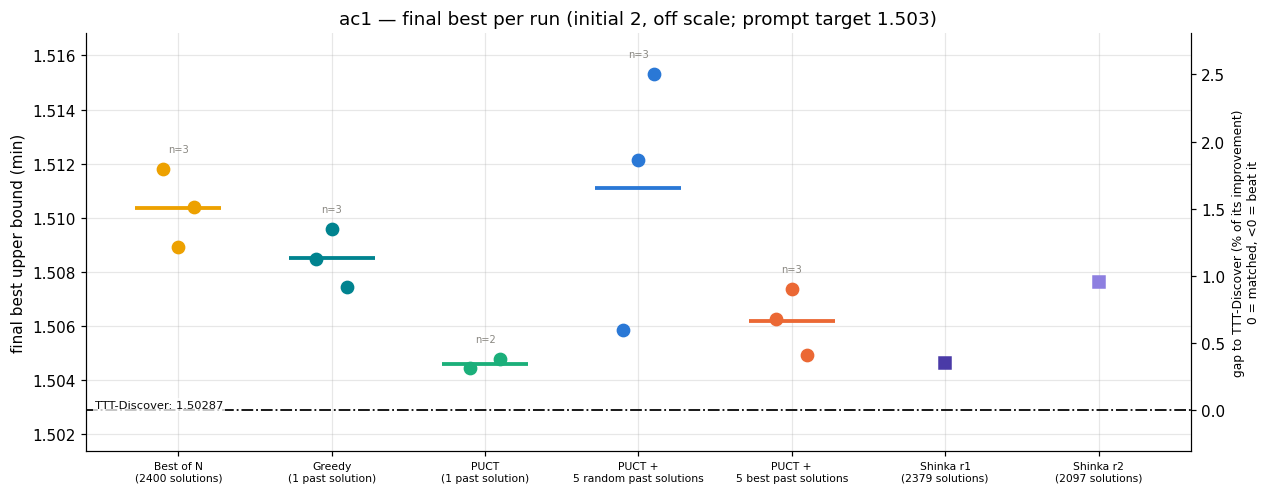

In [3]:
# Reference lines are labelled on the line itself rather than in a legend -- with 8-11 columns the
# arm legend was larger than the data, and the x-tick labels already name every arm.
def _label_hlines(ax, entries, side="alternate"):
    """entries: [(text, value, color)]. Labels ride on the line itself. Where two references nearly
    coincide -- on erdos, TTT-Discover 0.380876 against the coding agent's 0.380879 -- they are put
    on opposite sides of the axes *and* opposite sides of their own line, so neither is obscured.

    side="right" (or "left") pins every label to one side instead of alternating; the highest still
    sits above its line and the rest below, so a stack reads top-to-bottom in value order."""
    order = sorted(range(len(entries)), key=lambda i: -entries[i][1])
    for rank, i in enumerate(order):
        text, val, col = entries[i]
        left = {"right": False, "left": True}.get(side, rank % 2 == 0)
        ax.text(0.008 if left else 0.992, val, text, transform=ax.get_yaxis_transform(),
                ha="left" if left else "right", va="bottom" if rank == 0 else "top",
                fontsize=7.5, color=col, zorder=5,
                bbox=dict(fc="white", ec="none", alpha=0.75, pad=1.2))

def final_best_plot(problem, save=None, extra_hlines=(), extra_cols=(), shinka_min=1600,
                    drop=()):
    """extra_hlines: [(label, value, color, ls)]; extra_cols: [(label, value, color)] --
    appended as additional x positions (used to place the coding-agent finals next to the arms).
    Shinka joins as its own column once a seed has spent >= `shinka_min` solutions (1,600 of the
    arms' 2,400), so it only appears where its budget is broadly comparable. The right-hand axis restates y as
    gap to TTT-Discover in percent (0 = matched TTT).

    drop: arm keys to leave out entirely. Dropped arms are excluded from the y-range calculation
    too, so removing an outlier arm re-zooms the panel onto what is left."""
    spec = PROBLEMS[problem]
    sub = idx[idx.group == problem]
    arms = [a for a in ARM_ORDER if (sub.arm == a).any() and a not in drop]
    sub = sub[sub.arm.isin(arms)]
    shinka_cols = [(f"Shinka {r['seed']}\n({r['n']} solutions)", r["final"],
                    SHINKA_COLOR.get(r["seed"], "#4a3aa7")) for r in SHINKA[problem]
                   if r["n"] >= shinka_min]
    cols = list(shinka_cols) + list(extra_cols)
    # width scales with the column count so the two-line tick labels never collide
    fig, ax = plt.subplots(figsize=(max(9.5, 1.35 * (len(arms) + len(cols)) + 2.2), 4.6))
    for i, a in enumerate(arms):
        rows = sub[sub.arm == a]
        col = arm_color(a)
        comp = rows[rows.complete]
        if not comp.empty:
            # jitter the seeds apart: erdos PUCT's two seeds agree to 6 decimals and would draw as
            # one dot, which has been misread as "this arm only has one sample"
            dx = np.linspace(-0.10, 0.10, len(comp)) if len(comp) > 1 else np.zeros(1)
            ax.plot(i + dx, comp.best_score, "o", ms=8, color=col, zorder=3, ls="none")
            ax.hlines(comp.best_score.mean(), i-0.28, i+0.28, color=col, lw=2.5, zorder=2)
            ax.annotate(f"n={len(comp)}", (i, comp.best_score.max()), xytext=(0, 11),
                        textcoords="offset points", ha="center", fontsize=6.5, color="#898781")
        for _, r in rows[~rows.complete].iterrows():
            ax.plot(i, r.best_score, "o", ms=8, mfc="none", mec=col, alpha=0.55, zorder=3)
            ax.annotate(f"{r.generations_done}g", (i, r.best_score), xytext=(6, 0),
                        textcoords="offset points", fontsize=7, color="#898781", va="center")
    for j, (label, val, col_c) in enumerate(shinka_cols):
        ax.plot(len(arms) + j, val, "s", ms=8, color=col_c, zorder=3)
    for j, (label, val, col_c) in enumerate(extra_cols):
        ax.plot(len(arms) + len(shinka_cols) + j, val, "D", ms=8, color=col_c, zorder=3)
    hl = []
    for name, val in spec["refs"].items():
        col_r, ls_r = REF_STYLE[name]
        ax.axhline(val, color=col_r, ls=ls_r, lw=1.2)
        hl.append((f"{name}: {val:g}", val, col_r))
    for label, val, col_h, ls_h in extra_hlines:
        ax.axhline(val, color=col_h, ls=ls_h, lw=1.4)
        hl.append((f"{label}: {val:.6f}", val, col_h))
    _label_hlines(ax, hl)
    # zoom: tight band around the finals and everything else drawn
    vals = (list(sub.best_score) + list(spec["refs"].values())
            + [v for _, v, *_ in extra_hlines] + [v for _, v, _ in cols])
    lo, hi = min(vals), max(vals)
    pad = (hi - lo) * 0.12 or 1e-4
    ax.set_ylim(lo - pad, hi + pad)
    ax.ticklabel_format(useOffset=False, style="plain", axis="y")
    ax.set_xticks(range(len(arms) + len(cols)),
                  [arm_tick(a) for a in arms] + [c[0] for c in cols], fontsize=7)
    ax.set_xlim(-0.6, len(arms) + len(cols) - 0.4)
    ax.set_ylabel(f"final best {spec['metric']} ({'max' if spec['maximize'] else 'min'})")
    sec = ax.secondary_yaxis("right", functions=(lambda v: gap_pct(problem, v),
                                                 lambda g: raw_from_gap(problem, g)))
    sec.set_ylabel("gap to TTT-Discover (% of its improvement)\n0 = matched, <0 = beat it", fontsize=8)
    ax.set_title(f"{problem} — final best per run (initial {spec['initial']:.4g}, off scale; "
                 f"prompt target {spec['target']})")
    fig.tight_layout()
    if save: fig.savefig(save, dpi=150, bbox_inches="tight")
    return ax

# n10 random / n10 contrastive dropped from ac1: single seeds that widen the panel without adding
# a comparison the n5 arms do not already make.
final_best_plot("ac1", "icl_final_ac1.png", drop=("n10 random", "n10 contrastive"));

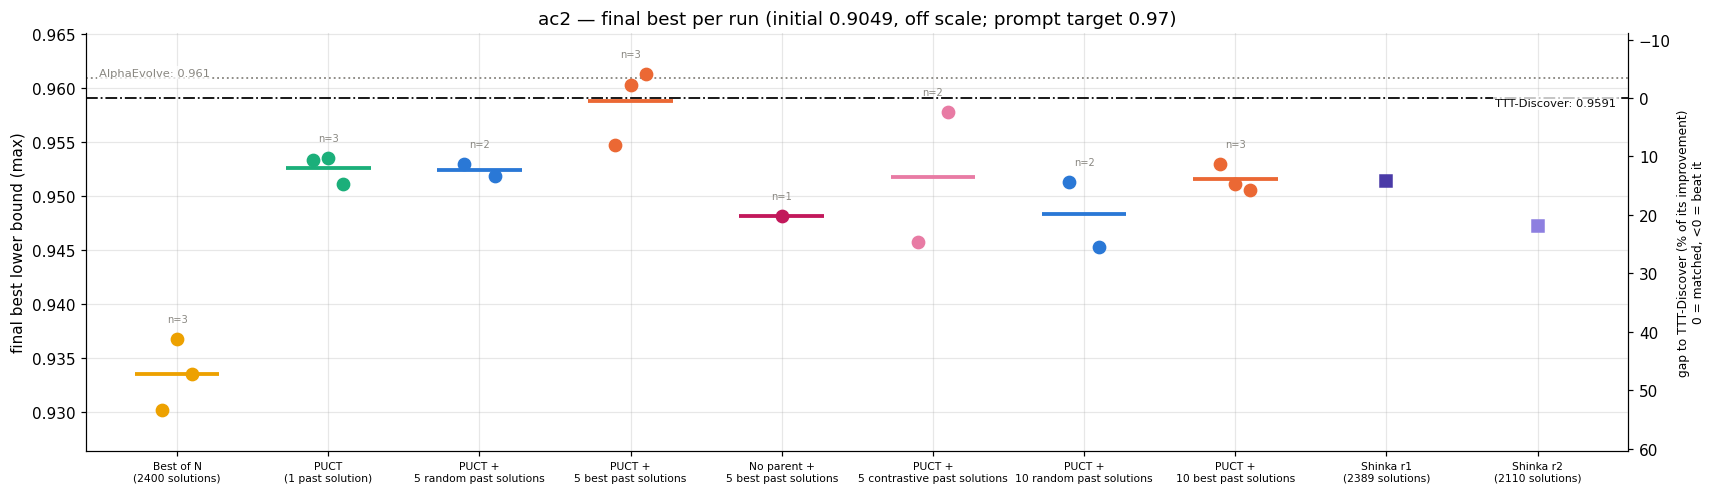

In [4]:
# `n5 contrastive` has a second seed now and the two straddle the field (0.9458 and 0.9578),
# so it earns its column; `n10 contrastive` is still one seed that only widens the panel
final_best_plot("ac2", "icl_final_ac2.png", drop=("n10 contrastive",));


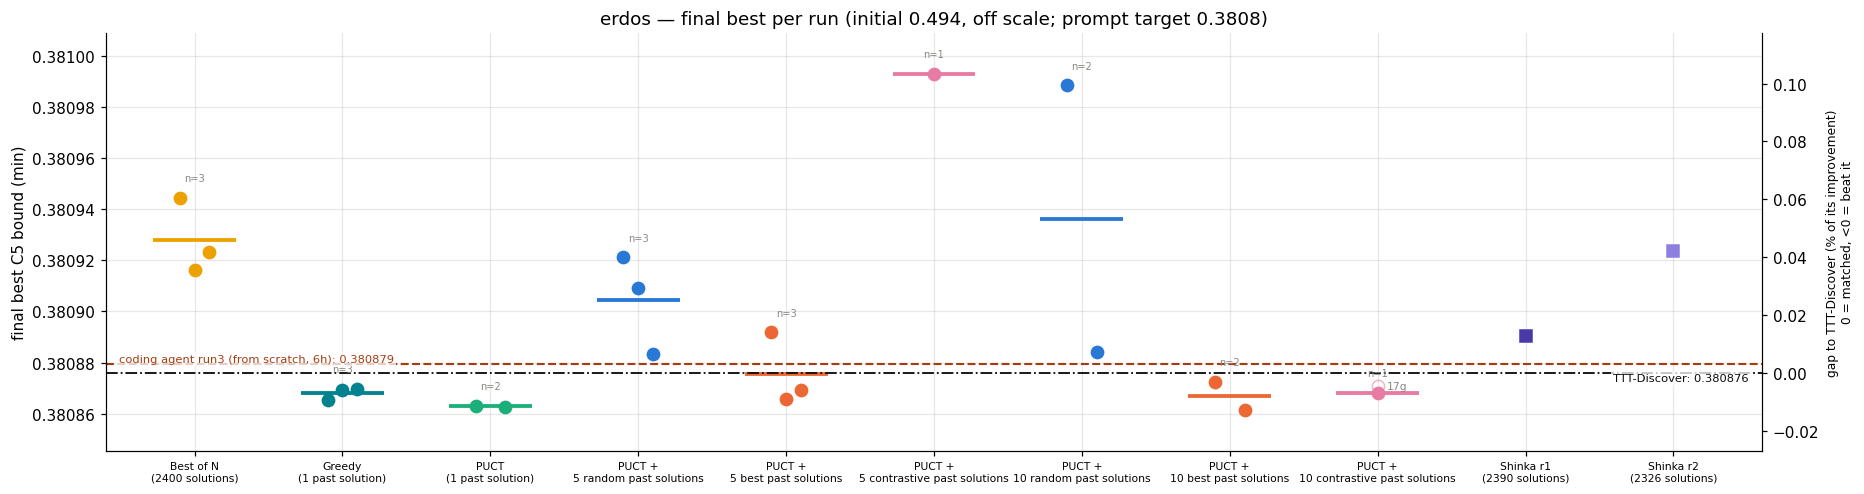

In [5]:
final_best_plot("erdos", "icl_final_erdos.png",
                extra_hlines=[("coding agent run3 (from scratch, 6h)", AGENT_RUN3_BEST,
                               "#a63d12", "--")]);

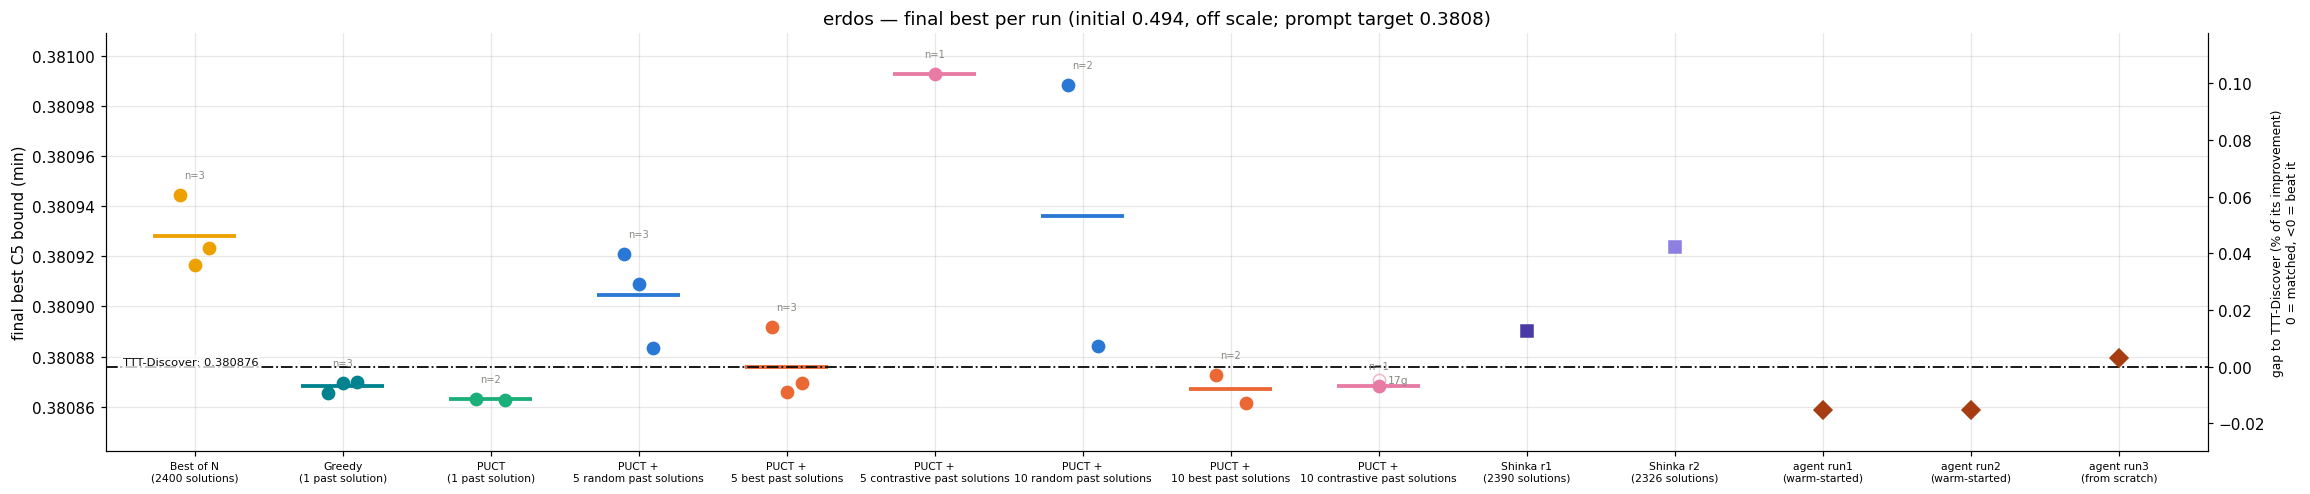

In [6]:
# same figure with every coding-agent final placed as its own column (diamonds).
# run1/run2 warm-started from downloaded published vectors, so their finals are polish of the
# published record, not search results — run3 is the only from-scratch agent point.
final_best_plot("erdos", "icl_final_erdos_with_agent.png",
                extra_cols=[(lbl, v, "#a63d12") for lbl, v in AGENT_FINALS.items()]);

## 1b. Distance to TTT-Discover on one comparable scale

The raw metrics above cannot be compared across problems, and neither can a naive
`|score - TTT| / TTT` percentage — that is dominated by each metric's constant offset, so on erdos
every arm would read "0.003% from TTT-Discover" and the number would carry no information.

Anchoring on the **initial solution every arm starts from** (the same one TTT-Discover used) fixes
that. For each run, measure the fraction of TTT-Discover's improvement it captured:

```
progress% = 100 x (run's improvement over the initial solution)
                / (TTT-Discover's improvement over the same initial solution)
gap%      = 100 - progress%          # positive = behind TTT-Discover, negative = beat it
```

So `0%` = matched TTT-Discover, `100%` = no better than the initial solution, `<0%` = beat it.
**`gap%` is the number to quote across experiments** ("this method is usually within x% of
TTT-Discover"), and it is on the right-hand axis of the per-problem figures too.

**The one caveat.** The metric saturates when the initial solution is far from the frontier: on
erdos the seed solution is so bad that *every* arm captures >99.9% of the available improvement, so
all arms read ≈0% and the third panel below is needed to resolve them. Use `gap%` for cross-problem
statements, and the raw metric for ranking arms *within* a problem. ac2 is the only problem here
whose `gap%` spread is large enough to separate the arms on its own.

mean gap to TTT-Discover, in % of TTT-Discover's improvement over the shared initial
solution (complete seeds only; negative = beat TTT-Discover)

group                         ac1    ac2  erdos  mean of covered  problems covered
arm                                                                               
n5 best                      0.66   0.55  -0.00             0.41                 3
Greedy                       1.13    NaN  -0.01             0.56                 2
PUCT                         0.35  11.90  -0.01             4.08                 3
n5 random                    1.66  12.30   0.03             4.66                 3
n10 contrastive               NaN   9.44  -0.01             4.72                 2
Shinka (best seed, partial)  0.35  14.17   0.01             4.84                 3
n5 contrastive                NaN  13.44   0.10             6.77                 2
n10 best                      NaN  13.94  -0.01             6.96                 2
n10 random             

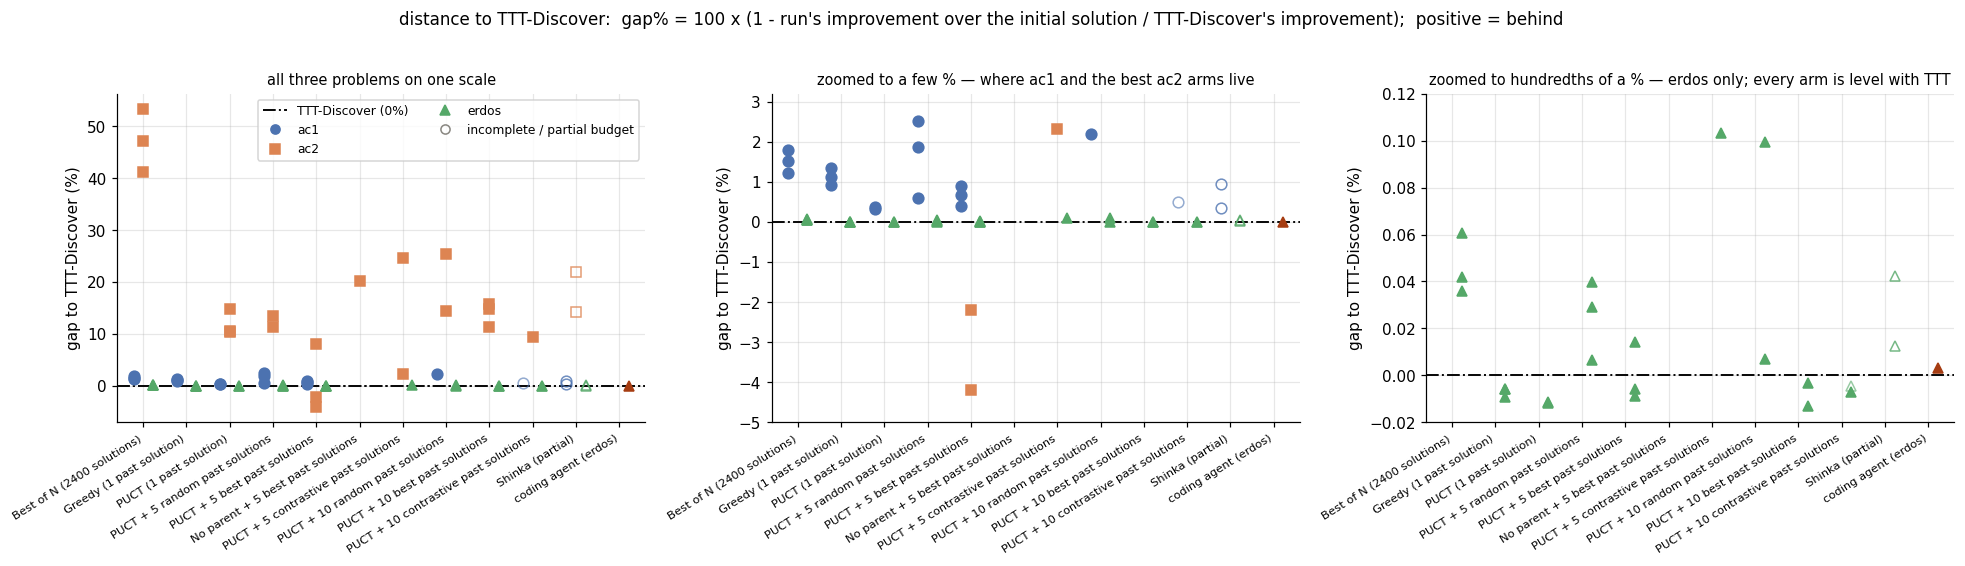

In [7]:
# One comparable number per run: gap to TTT-Discover as a % of the improvement TTT-Discover made
# from the same initial solution (0 = matched it, negative = beat it). See the setup cell for why
# this beats a plain |score - ref| / ref percentage.
PROB_MARK = {"ac1": ("o", "#4c72b0"), "ac2": ("s", "#dd8452"), "erdos": ("^", "#55a868")}
DODGE = {"ac1": -0.22, "ac2": 0.0, "erdos": 0.22}
arms_all = [a for a in ARM_ORDER if (idx.arm == a).any()]
xpos = {a: i for i, a in enumerate(arms_all)}
xpos["Shinka"] = len(arms_all)
xpos["coding agent"] = len(arms_all) + 1
ticks = [arm_label(a) for a in arms_all] + ["Shinka (partial)", "coding agent (erdos)"]

# progressive zoom: the metric saturates where the initial solution is far from the frontier, so
# one linear axis cannot show ac2 (tens of %) and erdos (hundredths of %) at once.
ZOOMS = [(None, "all three problems on one scale"),
         ((-5, 3.2), "zoomed to a few % — where ac1 and the best ac2 arms live"),
         ((-0.02, 0.12), "zoomed to hundredths of a % — erdos only; every arm is level with TTT")]
fig, axes = plt.subplots(1, 3, figsize=(18, 5.0))
for ax, (ylim, sub_t) in zip(axes, ZOOMS):
    for p, (mk, col) in PROB_MARK.items():
        for _, r in idx[idx.group == p].iterrows():
            ax.plot(xpos[r.arm] + DODGE[p], r.gap_pct, mk, ms=7, color=col,
                    mfc=col if r.complete else "none", alpha=1.0 if r.complete else 0.6, zorder=3)
        for run in SHINKA[p]:      # partial budget -> always open markers
            ax.plot(xpos["Shinka"] + DODGE[p], gap_pct(p, run["final"]), mk, ms=7, color=col,
                    mfc="none", alpha=0.8, zorder=3)
    ax.plot(xpos["coding agent"] + DODGE["erdos"], gap_pct("erdos", AGENT_RUN3_BEST), "^", ms=7,
            color="#a63d12", zorder=3)
    ax.axhline(0, color="#0b0b0b", ls="-.", lw=1.3)
    ax.set_xticks(list(xpos.values()), ticks, rotation=32, ha="right", fontsize=7.5)
    ax.set_xlim(-0.6, len(xpos) - 0.4)
    ax.set_ylabel("gap to TTT-Discover (%)")
    ax.set_title(sub_t, fontsize=9.5)
    if ylim:
        ax.set_ylim(*ylim)
axes[0].axhline(0, color="#0b0b0b", ls="-.", lw=1.3, label="TTT-Discover (0%)")
for p, (mk, col) in PROB_MARK.items():
    axes[0].plot([], [], mk, color=col, label=p)
axes[0].plot([], [], "o", color="#898781", mfc="none", label="incomplete / partial budget")
axes[0].legend(fontsize=8, ncol=2, loc="upper right")
fig.suptitle("distance to TTT-Discover:  gap% = 100 x (1 - run's improvement over the initial "
             "solution / TTT-Discover's improvement);  positive = behind", y=1.02, fontsize=11)
fig.tight_layout()
fig.savefig("icl_gap_to_ttt.png", dpi=150, bbox_inches="tight")

# ---- the table: "how far from TTT-Discover is this method, usually?" -------------------------
wide = (idx[idx.complete].groupby(["arm", "group"]).gap_pct.mean().unstack().reindex(arms_all))
wide.loc["Shinka (best seed, partial)"] = pd.Series(
    {p: min(gap_pct(p, r["final"]) for r in SHINKA[p]) for p in PROBLEMS})
wide["mean of covered"] = wide[list(PROBLEMS)].mean(axis=1)
wide["problems covered"] = wide[list(PROBLEMS)].notna().sum(axis=1)
wide = wide.sort_values("mean of covered")
print("mean gap to TTT-Discover, in % of TTT-Discover's improvement over the shared initial")
print("solution (complete seeds only; negative = beat TTT-Discover)\n")
print(wide.round(2).to_string())
print("\nNOTE: 'mean of covered' only compares arms with the same 'problems covered'. ac2 is the")
print("      one problem that spreads the arms apart, so an arm missing ac2 flatters itself --")
print("      Greedy (no ac2 seeds yet) is the case to be careful with.")

## 2. Evolution during the run

Left: **best-so-far** vs candidates tried — bold line = mean over that arm's *complete* seeds,
faint lines = individual runs (dashed = incomplete); right-hand axis restates it as gap to
TTT-Discover. Right: **quality of what the model proposes** — the median raw score of each
generation's valid candidates (arm mean across seeds) — this separates "the max got lucky once"
from "the proposal distribution actually shifted".

Two controls to read against: **BoN** never changes its parent, so its flat right-hand curve is the
noise floor any real evolution has to clear; **Greedy** always takes the best-so-far parent, so it
shows what the exploration term in PUCT is actually buying. Watch Greedy's proposal-quality curve
late in the run — on erdos it starts oscillating around generation 17 while every PUCT arm stays
pinned at the frontier, which is the instability you would expect from hammering a single parent.
(A candidate-level rolling version of this panel shows long square-wave collapses where a seed's
proposals lock onto one score — real mode-collapse behavior, but noisy to read; per-generation
medians carry the same signal.)

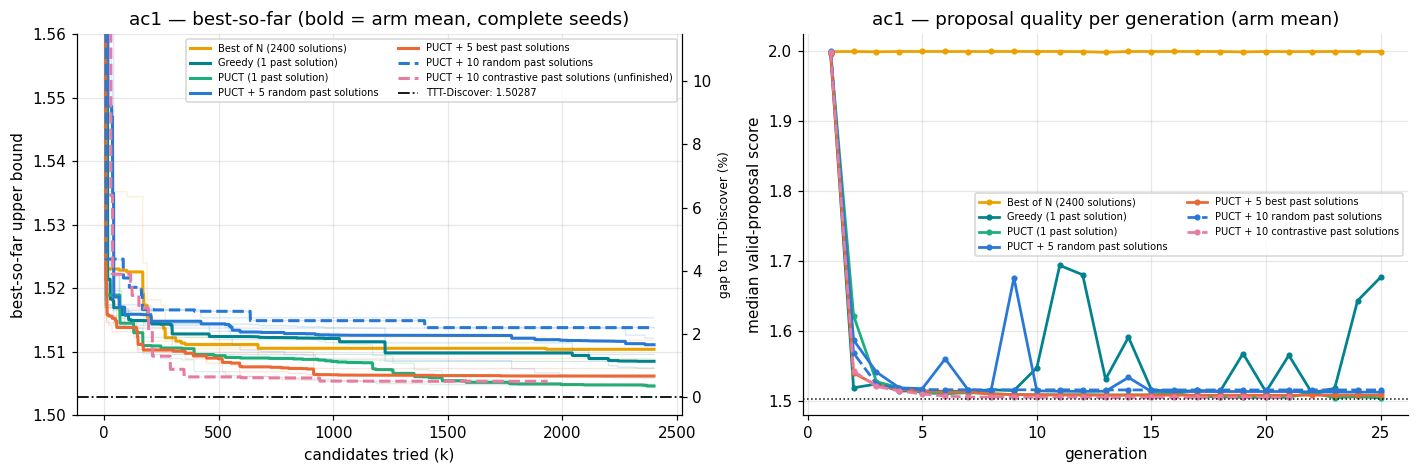

In [8]:
def evolution_plot(problem, save=None, zoom=False):
    spec = PROBLEMS[problem]
    sub = idx[idx.group == problem]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
    best_tail, qmeans = [], []
    for a in [a for a in ARM_ORDER if (sub.arm == a).any()]:
        rows = sub[sub.arm == a]
        col, ls = arm_color(a), arm_ls(a)
        comp_curves, qual_curves = [], []
        for _, r in rows.iterrows():
            ev = events[(problem, r["run"])]
            axes[0].plot(ev.k, ev.best_raw, color=col, alpha=0.18, lw=0.8,
                         ls="-" if r.complete else ":")
            if r.complete:
                comp_curves.append(ev.best_raw.to_numpy())
            gq = ev[ev.valid].groupby("generation").raw_score.median()
            arr = np.full(25, np.nan)
            arr[gq.index.to_numpy()] = gq.to_numpy()
            qual_curves.append(arr)
        label = arm_label(a)
        if not comp_curves:   # no finished seed yet: mean over the unfinished runs instead
            comp_curves = [events[(problem, r["run"])].best_raw.to_numpy()
                           for _, r in rows.iterrows()]
            label = f"{label} (unfinished)"
        if comp_curves:
            n = min(map(len, comp_curves))
            mean = np.nanmean([c[:n] for c in comp_curves], axis=0)
            axes[0].plot(range(1, n+1), mean, color=col, lw=2, ls=ls, label=label)
            best_tail.append(mean[200:])
        qmean = np.nanmean(qual_curves, axis=0)
        qmeans.append(qmean)
        axes[1].plot(range(1, 26), qmean, color=col, lw=1.8, ls=ls, marker="o", ms=3,
                     label=arm_label(a))
    for name, val in spec["refs"].items():
        col_r, ls_r = REF_STYLE[name]
        axes[0].axhline(val, color=col_r, ls=ls_r, lw=1.2, label=f"{name}: {val}")
    if zoom:
        lo = min(np.nanmin(np.concatenate(best_tail)), *spec["refs"].values())
        hi = max(np.nanmax(np.concatenate(best_tail)), *spec["refs"].values())
        pad = (hi - lo) * 0.10 or 1e-4
        axes[0].set_ylim(lo - pad, hi + pad)
        qlo, qhi = np.nanmin(qmeans), np.nanmax(qmeans)
        axes[1].set_ylim(qlo - 0.05 * (qhi - qlo), qhi + 0.05 * (qhi - qlo))
        axes[0].ticklabel_format(useOffset=False, style="plain", axis="y")
    else:
        axes[1].axhline(spec["target"], color="#0b0b0b", ls=":", lw=1)
        axes[0].set_ylim(*spec["band"])
    for ax in axes:
        ax.legend(fontsize=6.5, ncol=2)
    axes[0].set_xlabel("candidates tried (k)")
    axes[1].set_xlabel("generation")
    axes[0].set_ylabel(f"best-so-far {spec['metric']}")
    axes[1].set_ylabel("median valid-proposal score")
    sec = axes[0].secondary_yaxis("right", functions=(lambda v: gap_pct(problem, v),
                                                     lambda g: raw_from_gap(problem, g)))
    sec.set_ylabel("gap to TTT-Discover (%)", fontsize=8)
    axes[0].set_title(f"{problem} — best-so-far (bold = arm mean, complete seeds)"
                      + (" — zoomed" if zoom else ""))
    axes[1].set_title(f"{problem} — proposal quality per generation (arm mean)")
    fig.tight_layout()
    if save: fig.savefig(save, dpi=150, bbox_inches="tight")

# not exported: the figure still renders inline, but only the headline set is written to
# disk (see the export note in the setup cell)
evolution_plot("ac1")

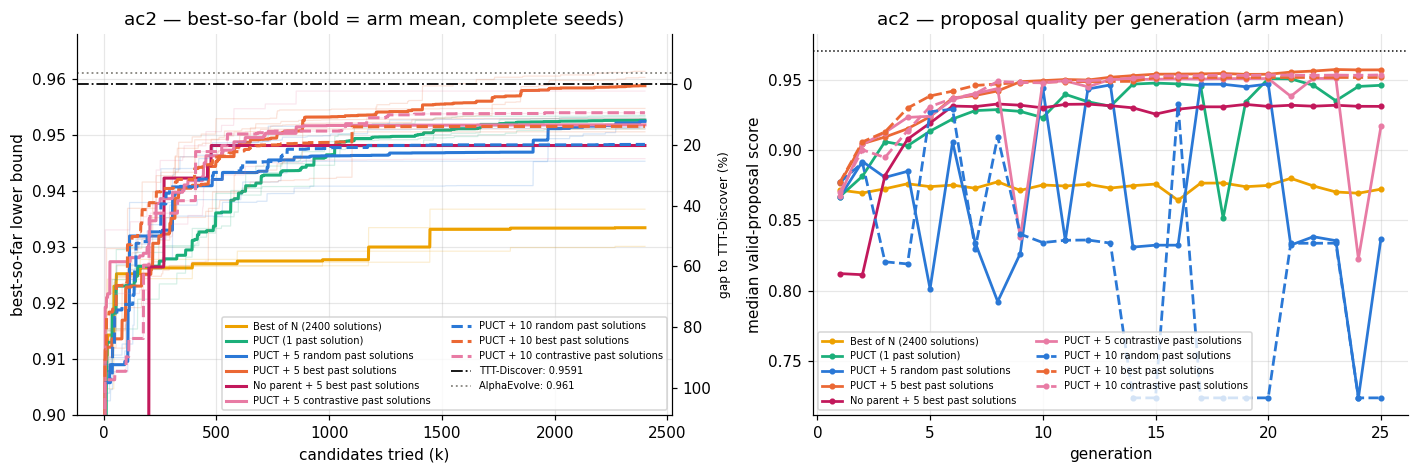

In [9]:
evolution_plot("ac2")

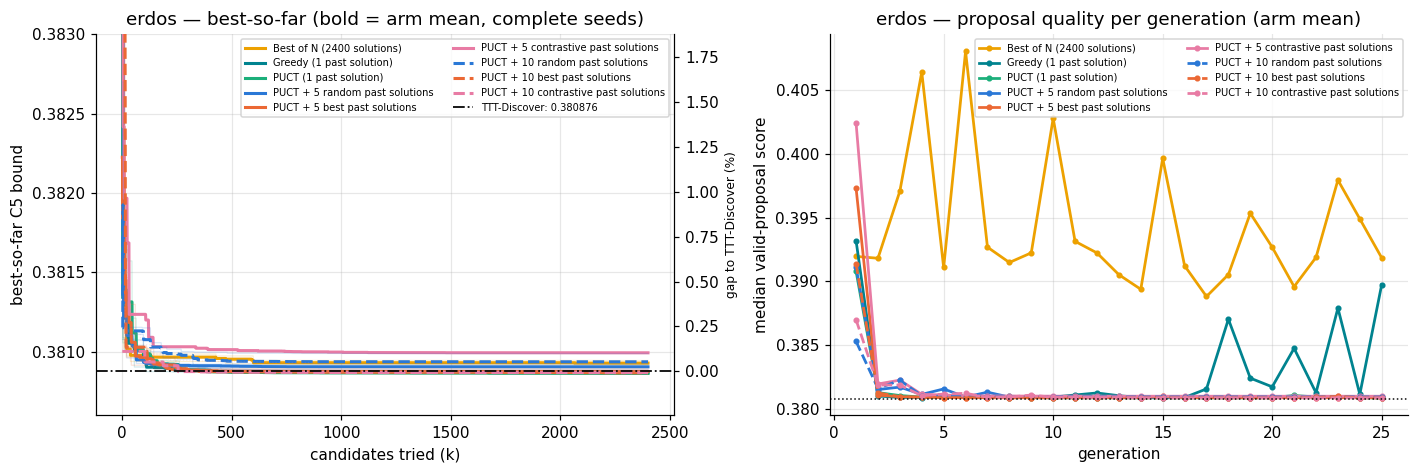

In [10]:
evolution_plot("erdos")

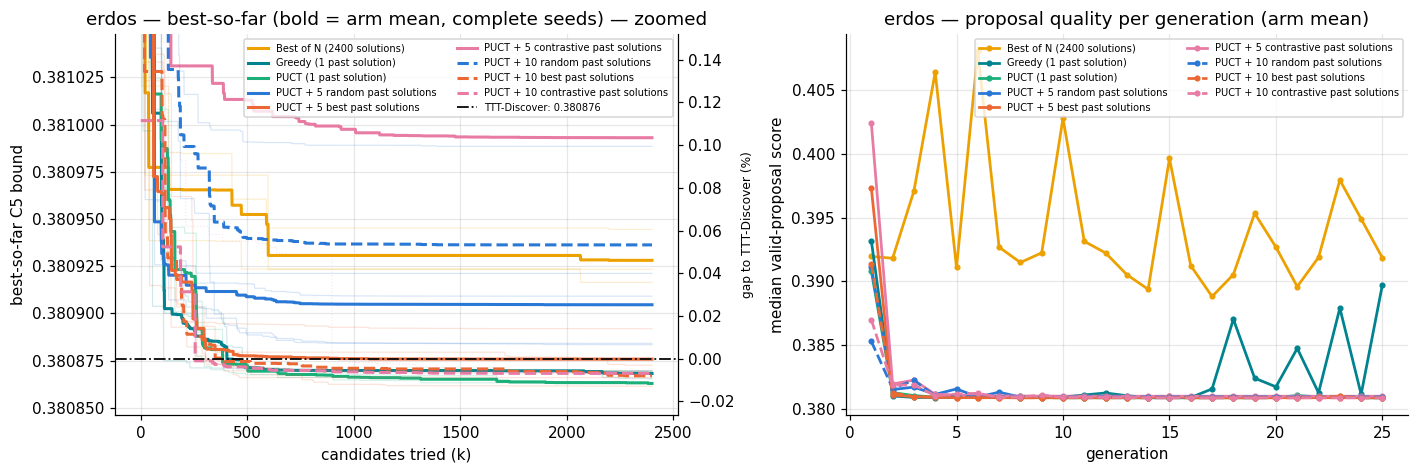

In [11]:
# the erdos finals differ in the 4th-5th decimal, so a zoomed version of the same figure
# (best-so-far clipped past the warmup, TTT-Discover reference drawn)
evolution_plot("erdos", zoom=True)

### 2b. Headline evolution — one figure per problem

The companion to §1: the same short cast of arms, but the whole trajectory instead of just the
endpoint. Included per problem: the two no-context controls (**Best of N**, **Greedy**), **PUCT**,
the best context arm (**PUCT + 5 best**), the **No parent + 5 best** arm where it exists (ac2 only),
and **Shinka** (both seeds). Everything else from §1 is left out on purpose — this is the figure to
read when the question is "did it keep improving, and who pulled ahead when", not "which arm won".

Bold line = mean over that arm's complete seeds, faint lines = the individual seeds behind it, so
the within-arm spread is visible rather than hidden by the mean. Each legend entry ends with the
value that curve reached. Reference lines are labelled on the line, as in §1, and the right-hand axis
restates y as gap to TTT-Discover. The y-axis is cropped to the frontier, so the early candidates
run off the top — the initial solution is far off-scale in every case.

There is no TriMul equivalent here, but not for lack of seeds any more (B200 has 2-3 per arm): the
`gap%` right-hand axis does not apply to a runtime, so §4c/§4d show the kernel evolution directly on
a log-runtime axis with the same bold-mean / faint-seeds convention.

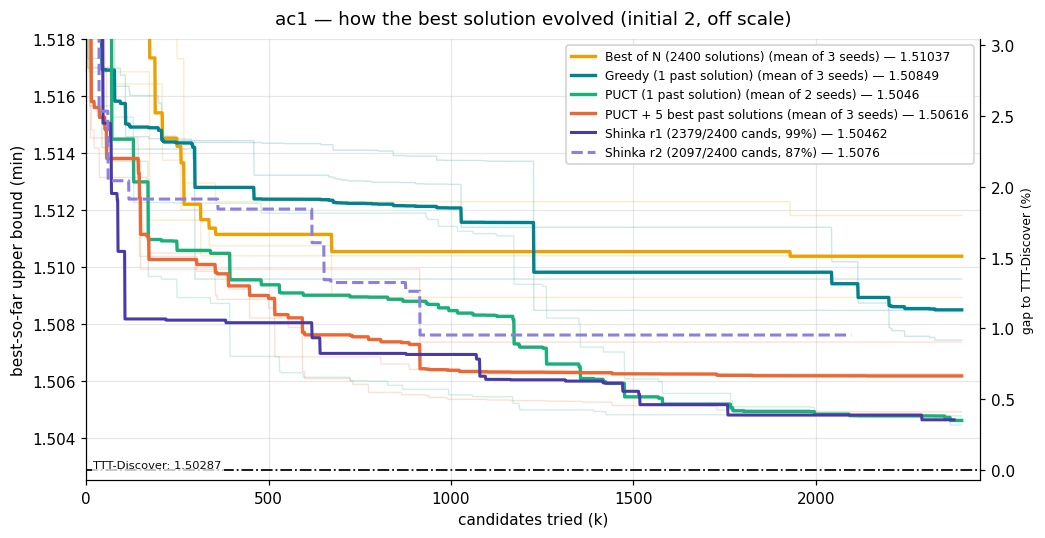

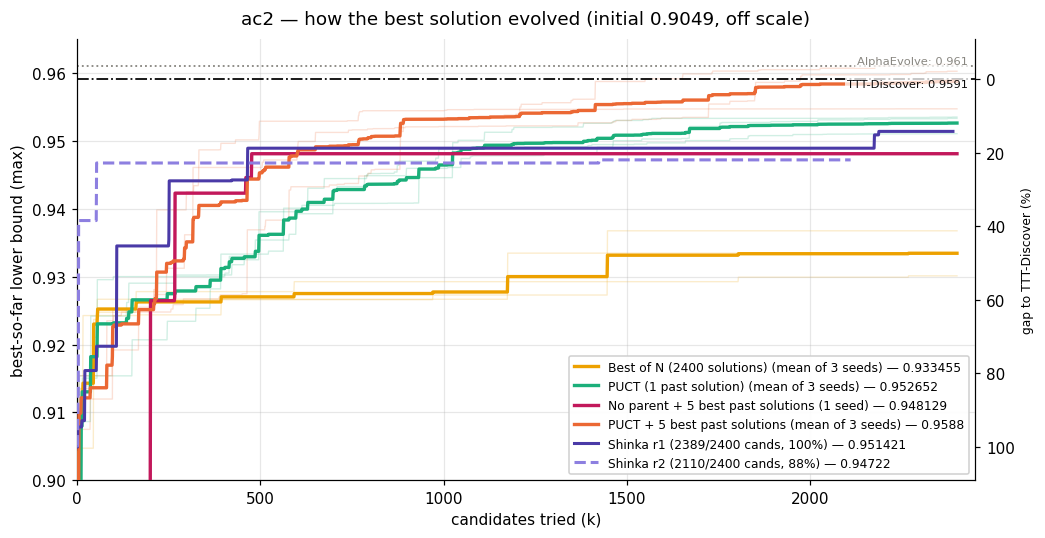

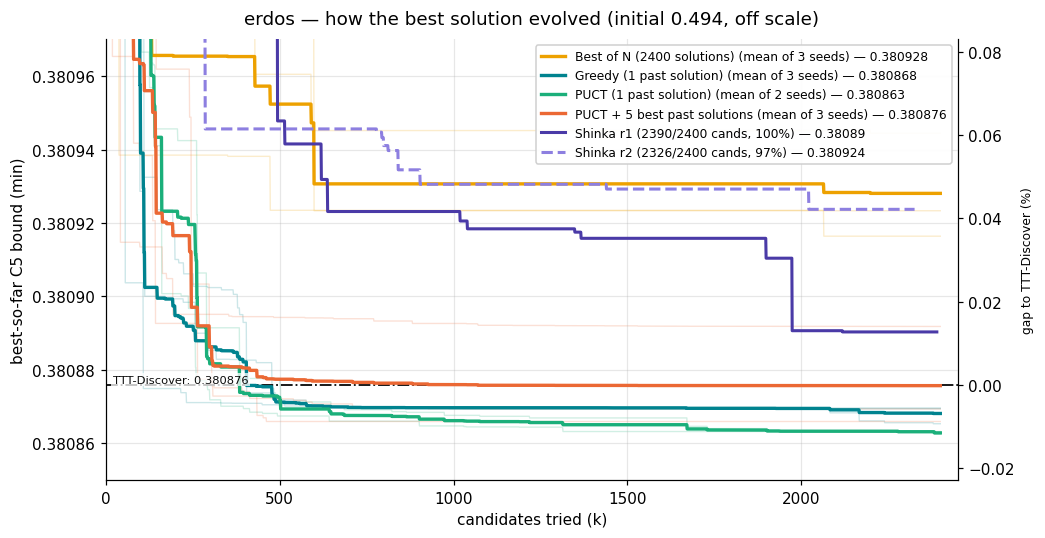

In [12]:
# The companion to §1: same cast of arms, but the whole trajectory instead of just the endpoint.
# Deliberately a short list -- the two controls (Best of N, Greedy), PUCT, the best context arm,
# the no-parent arm where it exists, and Shinka. One figure per problem.
HEADLINE_ARMS = ["BoN", "Greedy", "PUCT", "NoParent n5 best", "n5 best"]
HEADLINE_BAND = {"ac1": (1.5025, 1.5180), "ac2": (0.9000, 0.9650),
                 "erdos": (0.380850, 0.380970)}
# ac2 carries two references 0.0019 apart; stacking both on the right keeps TTT-Discover directly
# under AlphaEvolve instead of throwing it across to the opposite side of the panel.
REF_SIDE = {"ac2": "right"}

def headline_evolution(problem, save=None, seeds=True):
    """best-so-far vs candidates tried. Bold = mean over that arm's complete seeds, faint = the
    individual seeds behind it. Reference lines are labelled on the line, as in §1."""
    spec = PROBLEMS[problem]
    sub = idx[idx.group == problem]
    fig, ax = plt.subplots(figsize=(9.6, 5.0))
    for a in [a for a in HEADLINE_ARMS if (sub.arm == a).any()]:
        rows = sub[sub.arm == a]
        col = arm_color(a)
        comp = rows[rows.complete]
        use = comp if not comp.empty else rows
        curves = [events[(problem, r["run"])].best_raw.to_numpy() for _, r in use.iterrows()]
        if seeds and len(curves) > 1:
            for c in curves:
                ax.plot(range(1, len(c) + 1), c, color=col, alpha=0.20, lw=0.9, zorder=1)
        n = min(map(len, curves))
        mean = np.nanmean([c[:n] for c in curves], axis=0)
        note = f"mean of {len(curves)} seeds" if len(curves) > 1 else "1 seed"
        if comp.empty:
            note += ", unfinished"
        ax.plot(range(1, n + 1), mean, color=col, lw=2.2, ls=arm_ls(a), zorder=3,
                label=f"{arm_label(a)} ({note}) — {mean[-1]:.6g}")
    for shk in SHINKA[problem]:
        ax.plot(shk["k"], shk["best"], color=SHINKA_COLOR.get(shk["seed"], "#4a3aa7"), lw=2.0,
                ls="-" if shk["seed"] == "r1" else "--", zorder=3,
                label=f"Shinka {shk['seed']} ({shk['n']}/{SHINKA_BUDGET} cands, "
                      f"{100 * shk['n'] / SHINKA_BUDGET:.0f}%) — {shk['final']:.6g}")
    hl = []
    for name, val in spec["refs"].items():
        col_r, ls_r = REF_STYLE[name]
        ax.axhline(val, color=col_r, ls=ls_r, lw=1.2, zorder=2)
        hl.append((f"{name}: {val:g}", val, col_r))
    _label_hlines(ax, hl, side=REF_SIDE.get(problem, "alternate"))
    ax.set_ylim(*HEADLINE_BAND[problem])
    ax.set_xlim(0, 2450)
    ax.ticklabel_format(useOffset=False, style="plain", axis="y")
    ax.set_xlabel("candidates tried (k)")
    ax.set_ylabel(f"best-so-far {spec['metric']} ({'max' if spec['maximize'] else 'min'})")
    sec = ax.secondary_yaxis("right", functions=(lambda v: gap_pct(problem, v),
                                                lambda g: raw_from_gap(problem, g)))
    sec.set_ylabel("gap to TTT-Discover (%)", fontsize=8)
    ax.set_title(f"{problem} — how the best solution evolved (initial {spec['initial']:.4g}, "
                 f"off scale)", fontsize=12, pad=10)
    ax.legend(fontsize=8, loc="best", framealpha=0.92, labelspacing=0.5)
    fig.tight_layout()
    if save: fig.savefig(save, dpi=150, bbox_inches="tight")

for _p in PROBLEMS:
    headline_evolution(_p, f"icl_headline_evolution_{_p}.png")

## 3. Context size — 5 vs 10 in-prompt solutions

Every (strategy, seed) pair where both an `n05` and an `n10` run exist, connected by a line
(same seed, same strategy, only `n_context` differs). Open marker = that side incomplete.
With this few pairs this is directional evidence only.

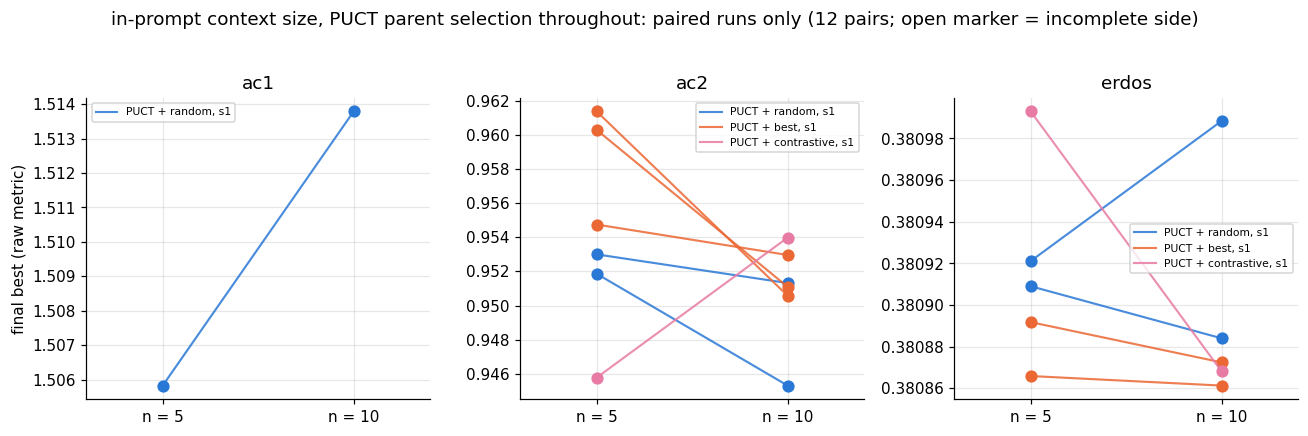

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
npairs = 0
for ax, p in zip(axes, PROBLEMS):
    spec = PROBLEMS[p]
    sub = idx[idx.group == p]
    for strat in ("random", "best", "contrastive"):
        for seed in (1, 2, 3):
            pair = {n: sub[(sub.arm == f"{n} {strat}") & (sub.seed == seed)] for n in ("n5", "n10")}
            if any(v.empty for v in pair.values()):
                continue
            npairs += 1
            y = [pair["n5"].best_score.iloc[0], pair["n10"].best_score.iloc[0]]
            comp = [bool(pair["n5"].complete.iloc[0]), bool(pair["n10"].complete.iloc[0])]
            col = STRAT_COLOR[strat]
            ax.plot([0, 1], y, color=col, lw=1.4, alpha=0.85,
                    label=f"PUCT + {strat}, s{seed}" if seed == 1 else None)
            for x, yy, c in zip((0, 1), y, comp):
                ax.plot(x, yy, "o", ms=7, color=col, mfc=col if c else "none")
    ax.set_xticks([0, 1], ["n = 5", "n = 10"])
    ax.set_xlim(-0.4, 1.4)
    ax.set_title(p)
    ax.legend(fontsize=7)
axes[0].set_ylabel("final best (raw metric)")
fig.suptitle(f"in-prompt context size, PUCT parent selection throughout: paired runs only "
             f"({npairs} pairs; open marker = incomplete side)", y=1.03)
fig.tight_layout()
# not exported: the figure still renders inline, but only the headline set is written to
# disk (see the export note in the setup cell)

## 4. Against the other paradigms — Shinka and the coding agent

Same model (Qwen3.6-27B-FP8), same seed solutions, same 1100 s eval cap, and the **same budget
unit: one candidate = one program evaluated**.

**`r1` has finished; `r2` has not.** The first Shinka seed ran its **full 2,400 generations** on all
three problems and exited cleanly (ac1 2026-08-22, ac2 2026-08-21, erdos 2026-08-20, 8-9 days of
wall clock each at ~10-11 candidates/h). Its database holds 2,379-2,391 programs rather than 2,400
because 10-21 generations never produced a program row at all — so *slightly* under budget in
candidates, at full budget in generations. **`r2` is still running** (ac1 2,028, ac2 2,025, erdos
2,241 of 2,400 as of this snapshot, ~12-14 candidates/h, so ~12 h left on erdos and ~30 h on
ac1/ac2).
`r1` is drawn solid, `r2` dashed, and `r2` keeps the open marker in §1b to mark the partial budget.

The coding agent is NOT on a comparable budget axis (each of its 356 "attempts" is a saved artifact
of an agent running local optimizers for hours), so it enters only as a final-score reference on
erdos.

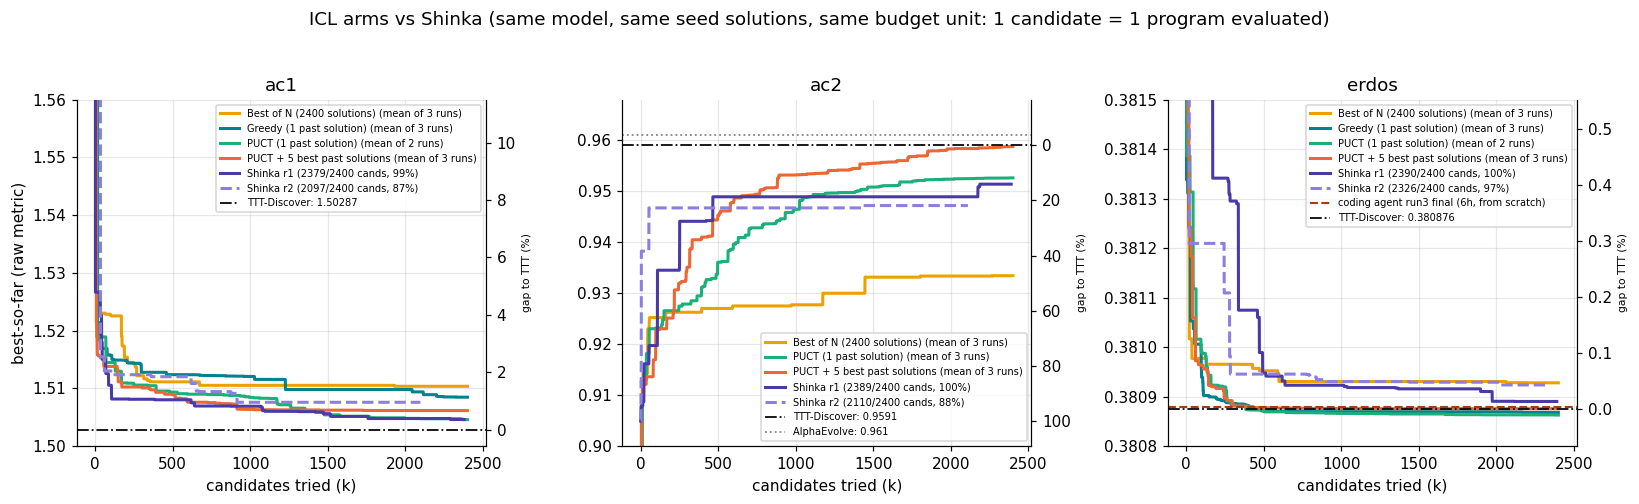

In [14]:
COMPARE_BAND = {"erdos": (0.38080, 0.38150)}
# the control, the two selection-rule arms, and the best ICL arm -- keeps the panel readable
SHOW = ["BoN", "Greedy", "PUCT", "n5 best"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, p in zip(axes, PROBLEMS):
    spec = PROBLEMS[p]
    sub = idx[idx.group == p]
    for a in SHOW:
        rows = sub[(sub.arm == a) & sub.complete]
        unfinished = rows.empty          # no finished seed for this arm on this problem
        if unfinished:
            rows = sub[sub.arm == a]
        curves = [events[(p, r["run"])].best_raw.to_numpy() for _, r in rows.iterrows()]
        if not curves:
            continue                     # e.g. Greedy on ac2: no runs yet
        n = min(map(len, curves))
        desc = (f"mean of {len(curves)} unfinished run{'s' if len(curves) > 1 else ''}, to k={n}"
                if unfinished else f"mean of {len(curves)} run{'s' if len(curves) > 1 else ''}")
        ax.plot(range(1, n+1), np.nanmean([c[:n] for c in curves], axis=0),
                color=arm_color(a), lw=2, ls="--" if unfinished else "-",
                label=f"{arm_label(a)} ({desc})")
    for run in SHINKA[p]:
        ax.plot(run["k"], run["best"], color=SHINKA_COLOR.get(run["seed"], "#4a3aa7"), lw=2,
                ls="-" if run["seed"] == "r1" else "--",
                label=f"Shinka {run['seed']} ({run['n']}/{SHINKA_BUDGET} cands, "
                      f"{100*run['n']/SHINKA_BUDGET:.0f}%)")
    if p == "erdos":
        ax.axhline(AGENT_RUN3_BEST, color="#a63d12", ls="--", lw=1.4,
                   label="coding agent run3 final (6h, from scratch)")
    for name, val in spec["refs"].items():
        col_r, ls_r = REF_STYLE[name]
        ax.axhline(val, color=col_r, ls=ls_r, lw=1.2, label=f"{name}: {val}")
    # erdos: the ICL/agent/TTT cluster lives in the 4th decimal — tighten the band so it
    # resolves, keeping Shinka's curve in frame
    ax.set_ylim(*COMPARE_BAND.get(p, spec["band"]))
    ax.ticklabel_format(useOffset=False, style="plain", axis="y")
    sec = ax.secondary_yaxis("right", functions=(lambda v, _p=p: gap_pct(_p, v),
                                                lambda g, _p=p: raw_from_gap(_p, g)))
    sec.set_ylabel("gap to TTT (%)", fontsize=7)
    ax.set_title(p)
    ax.set_xlabel("candidates tried (k)")
    ax.legend(fontsize=6.5)
axes[0].set_ylabel("best-so-far (raw metric)")
fig.suptitle("ICL arms vs Shinka (same model, same seed solutions, same budget unit: "
             "1 candidate = 1 program evaluated)", y=1.03)
fig.tight_layout()
# not exported: the figure still renders inline, but only the headline set is written to
# disk (see the export note in the setup cell)

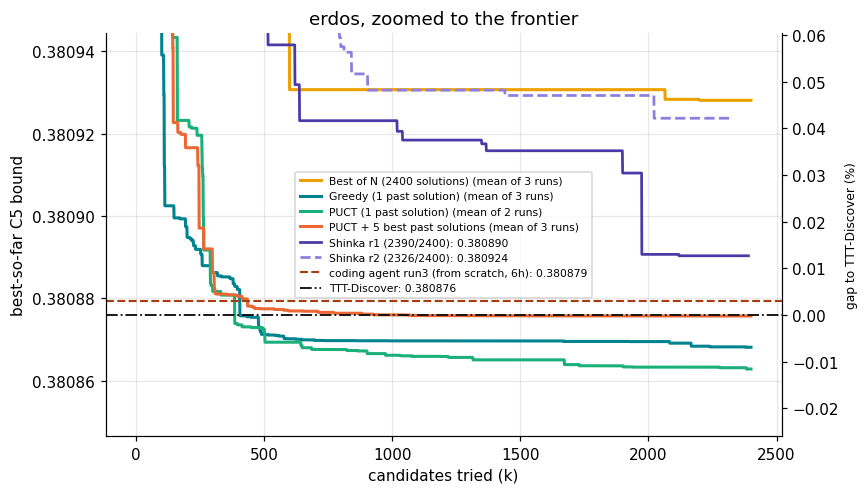

In [15]:
# erdos only, zoomed to the frontier so TTT-Discover vs coding-agent vs the ICL arms resolve
# (Shinka r1 now reaches 0.38089, so it is drawn here too; r2 is still off-scale)
fig, ax = plt.subplots(figsize=(8, 4.6))
spec = PROBLEMS["erdos"]
finals = []
for a in SHOW:
    rows = idx[(idx.group == "erdos") & (idx.arm == a) & idx.complete]
    curves = [events[("erdos", r["run"])].best_raw.to_numpy() for _, r in rows.iterrows()]
    if not curves:
        continue
    n = min(map(len, curves))
    mean = np.nanmean([c[:n] for c in curves], axis=0)
    ax.plot(range(1, n+1), mean, color=arm_color(a), lw=2,
            label=f"{arm_label(a)} (mean of {len(curves)} run{'s' if len(curves) > 1 else ''})")
    finals.append(mean[-1])
for run in SHINKA["erdos"]:
    if gap_pct("erdos", run["final"]) < 0.5:      # only the seeds that reach this zoom band
        ax.plot(run["k"], run["best"], color=SHINKA_COLOR.get(run["seed"], "#4a3aa7"), lw=1.8,
                ls="-" if run["seed"] == "r1" else "--",
                label=f"Shinka {run['seed']} ({run['n']}/{SHINKA_BUDGET}): {run['final']:.6f}")
        finals.append(run["final"])
ax.axhline(AGENT_RUN3_BEST, color="#a63d12", ls="--", lw=1.4,
           label=f"coding agent run3 (from scratch, 6h): {AGENT_RUN3_BEST:.6f}")
name, val = "TTT-Discover", spec["refs"]["TTT-Discover"]
ax.axhline(val, color=REF_STYLE[name][0], ls=REF_STYLE[name][1], lw=1.2, label=f"{name}: {val}")
lo, hi = min(finals + [val, AGENT_RUN3_BEST]), max(finals + [val, AGENT_RUN3_BEST])
pad = (hi - lo) * 0.25
ax.set_ylim(lo - pad, hi + pad)
ax.ticklabel_format(useOffset=False, style="plain", axis="y")
sec = ax.secondary_yaxis("right", functions=(lambda v: gap_pct("erdos", v),
                                            lambda g: raw_from_gap("erdos", g)))
sec.set_ylabel("gap to TTT-Discover (%)", fontsize=8)
ax.set_xlabel("candidates tried (k)")
ax.set_ylabel("best-so-far C5 bound")
ax.set_title("erdos, zoomed to the frontier")
ax.legend(fontsize=7)
fig.tight_layout()
# not exported: the figure still renders inline, but only the headline set is written to
# disk (see the export note in the setup cell)

### 4b. Equal-budget comparison against Shinka

Now that `r1` has spent the full budget, the fair comparison is **best-so-far at a fixed candidate
count k** — both paradigms spend the same unit (one candidate = one program evaluated), so this does
not depend on where a run happened to stop. The table below is printed and auto-refreshed by the
next cell; `—` means that run has not reached that k, and the ordering uses each run's *last*
available value.

**ac1** (upper bound, lower is better) — a genuine tie at the top:

| run | k=100 | k=400 | k=1,200 | final |
|---|---:|---:|---:|---:|
| `PUCT (1 past solution)` (mean of 2) | 1.514488 | 1.509544 | 1.507177 | **1.504600** |
| Shinka r1 | **1.510543** | **1.508036** | **1.506029** | 1.504623 |
| `PUCT + 5 best` (mean of 3) | 1.513810 | 1.509329 | 1.506298 | 1.506164 |
| Shinka r2 (2,028 cands) | 1.513028 | 1.512031 | 1.507604 | 1.507604 |
| Greedy (mean of 3) | 1.515742 | 1.512792 | 1.511558 | 1.508488 |
| Best of N (mean of 3) | 1.522561 | 1.511141 | 1.510536 | 1.510373 |

Shinka r1 leads at every intermediate k and the ICL PUCT arm only catches it at the end: 1.504600 vs
1.504623, a difference in the **5th decimal** (gap +0.348% vs +0.353%). Call it a tie, with Shinka
ahead for most of the run.

**ac2** (lower bound, higher is better) — Shinka wins early, then stalls:

| run | k=100 | k=400 | k=1,200 | final |
|---|---:|---:|---:|---:|
| `PUCT + 5 best` (mean of 3) | 0.922612 | 0.941026 | **0.953613** | **0.958800** |
| `PUCT + 10 contrastive` (1 seed) | 0.910430 | 0.938296 | 0.953081 | 0.953981 |
| `PUCT (1 past solution)` (mean of 3) | 0.923197 | 0.931200 | 0.949641 | 0.952652 |
| `PUCT + 10 best` (mean of 3) | 0.923502 | 0.942087 | 0.951479 | 0.951546 |
| Shinka r1 | 0.919746 | **0.944130** | 0.948944 | 0.951421 |
| Shinka r2 (2,025 cands) | **0.946761** | 0.946761 | 0.946761 | 0.947220 |
| Best of N (mean of 3) | 0.925234 | 0.927028 | 0.930013 | 0.933455 |

At k=400 Shinka r1 is the best run on the board (0.944130 against the best ICL arm's 0.942316 —
`No parent + 5 best`, not in the table above). Then
it **flattens: 0.948944 from k=466 all the way to k=2,174**, and finishes at 0.951421 — mid-pack,
level with `PUCT + 10 best` and well behind `PUCT + 5 best`'s 0.958800. Shinka r2 is the same shape
carried to an extreme: it jackpots to 0.946761 inside its first 100 candidates and then improves by
**nothing for the next 1,900**.

**erdos** (C5 bound, lower is better) — Shinka is behind at every k:

| run | k=100 | k=400 | k=1,200 | final |
|---|---:|---:|---:|---:|
| `PUCT (1 past solution)` (mean of 2) | 0.380992 | **0.380874** | **0.380866** | **0.380863** |
| `PUCT + 10 best` (mean of 2) | 0.381028 | 0.380874 | 0.380871 | 0.380867 |
| Greedy (mean of 3) | **0.380939** | 0.380882 | 0.380870 | 0.380868 |
| Shinka r1 | 0.381928 | 0.381075 | 0.380918 | 0.380890 |
| Shinka r2 (2,241 cands) | 0.381210 | 0.380946 | 0.380931 | 0.380924 |
| Best of N (mean of 3) | 0.380977 | 0.380965 | 0.380931 | 0.380928 |

Most ICL arms are within 0.0002 of TTT-Discover's 0.380876 by their **100th** candidate
(0.380932-0.381028); Shinka r1 is at 0.381928 there and needs ~1,200 candidates to get inside 0.0001,
never closing the last bit. On this problem the seed solution is already close to optimal, so even
Best of N (0.380928) lands within 0.00006 of Shinka r2 (0.380924) — Shinka's population machinery
mostly spends budget rediscovering what sampling around the seed finds immediately.

**What the three problems say together.** The two paradigms differ less in *where they end up* than
in *how they get there*: Shinka converges faster over the first few hundred candidates (it is ahead
at k=400 on ac1 and ac2) and then plateaus hard, while the ICL arms start slower and keep improving
to the end of the budget. On ac1 that ends in a tie, on ac2 the best ICL arm pulls clearly ahead, and
on erdos Shinka never leads at all. Neither `r1` result is an average — it is one seed, and `r2` is
tracking meaningfully worse than `r1` on all three problems (+0.952%, +21.9%, +0.042% gap vs
+0.353%, +14.2%, +0.013%), which is the same seed-to-seed variance the ICL arms show.

**Validity is comparable, not better.** Shinka's programs are correct 74.9% (ac1), 70.8% (ac2) and
70.8% (erdos) of the time, against the ICL campaigns' 81% / 76% / 66% (§5). The evolutionary loop is
not buying cleaner code; on erdos it is buying *slightly* cleaner code than the ICL arms manage.


In [16]:
# ------------------------------------------------- equal-budget comparison: ICL arms vs Shinka
# Best-so-far at fixed candidate budgets k. Both paradigms spend the same unit -- one candidate =
# one program evaluated -- so this is the comparison that does not depend on where a run happened
# to stop. It replaces an earlier "candidates to reach threshold X" framing, which is fragile here:
# Shinka r1 sits on 0.948944 from k=466 to k=2,174, so a 0.9490 cut reports it as 4x slower than a
# 0.9489 cut would.
def _best_at(curve, k):
    c = np.asarray(curve, dtype=float)
    return c[min(k, len(c)) - 1], len(c) >= k

def equal_k_table(problem, ks=(100, 400, 1200, 2400)):
    """One row per Shinka seed and per ICL arm (mean over its complete seeds): what had this
    method found after k candidates. '—' = that run has not reached k yet."""
    rows = [(f"Shinka {shk['seed']} [{shk['n']} cands]", shk["best"].to_numpy())
            for shk in SHINKA[problem]]
    for a in ARM_ORDER:
        sel = idx[(idx.group == problem) & (idx.arm == a) & idx.complete]
        cs = [events[(problem, r["run"])].best_raw.to_numpy() for _, r in sel.iterrows()]
        if cs:
            n = min(map(len, cs))
            rows.append((f"{arm_label(a, budget=None)} (mean of {len(cs)})",
                         np.mean([c[:n] for c in cs], axis=0)))
    hi = PROBLEMS[problem]["maximize"]
    print(f"\n=== {problem}: best-so-far at fixed candidate budgets "
          f"({'higher' if hi else 'lower'} is better; '—' = run has not reached that k) ===")
    print(f"{'run':52s} " + "".join(f"{'k=' + str(k):>12s}" for k in ks))
    order = sorted(rows, key=lambda r: -_best_at(r[1], ks[-1])[0] if hi
                   else _best_at(r[1], ks[-1])[0])
    for label, c in order:
        cells = []
        for k in ks:
            v, reached = _best_at(c, k)
            # 6 decimals: erdos separates in the 5th-6th, and 4 dp makes every arm look identical
            cells.append(f"{v:12.6f}" if reached else f"{'—':>12s}")
        print(f"{label[:51]:52s} " + "".join(cells))

for _p in PROBLEMS:
    equal_k_table(_p)



=== ac1: best-so-far at fixed candidate budgets (lower is better; '—' = run has not reached that k) ===
run                                                         k=100       k=400      k=1200      k=2400
PUCT (1 past solution) (mean of 2)                       1.514488    1.509544    1.507177    1.504600
Shinka r1 [2379 cands]                                   1.510543    1.508036    1.506029           —
PUCT + 5 best past solutions (mean of 3)                 1.513810    1.509329    1.506298    1.506164
Shinka r2 [2097 cands]                                   1.513028    1.512031    1.507604           —
Greedy (1 past solution) (mean of 3)                     1.515742    1.512792    1.511558    1.508488
Best of N (mean of 3)                                    1.522561    1.511141    1.510536    1.510373
PUCT + 5 random past solutions (mean of 3)               1.515890    1.514796    1.512576    1.511099
PUCT + 10 random past solutions (mean of 1)              1.521605    1.516358  

### 4c. TriMul pilot — the kernel problem, next on the list

First ICL runs on TTT-Discover's TriMul GPU-kernel challenge (H100, score = geomean runtime in
us over the benchmark shapes, lower is better). This is a **pilot**: BoN (20 gens, complete)
and PUCT (16 gens, complete) at 4x8, plus 3 finished generations of `n5 best`. TTT-Discover's
published H100 result is **1161 us** — and it spent 25,600 RL candidates (50 x 8 x 64) against
our <=640. The question here is only whether the problem shows headroom for search at all.
Failures are dominated by Triton compilation errors, so the right panel shows how much of each
arm's budget even produced a runnable kernel.

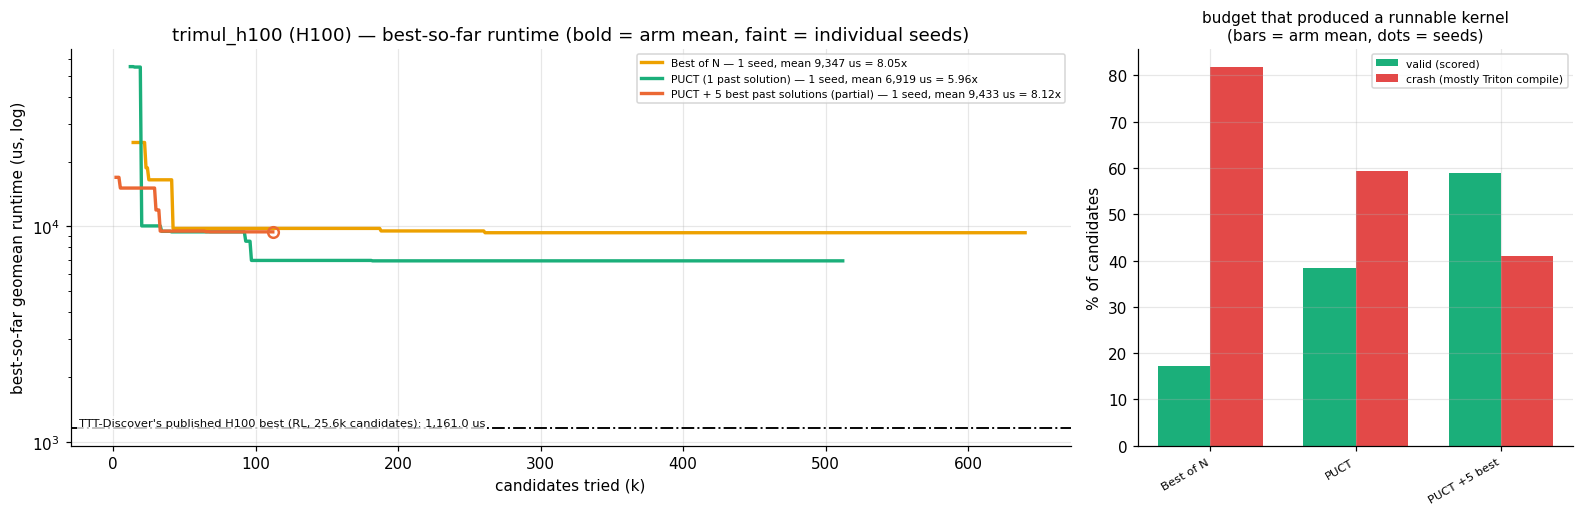

In [17]:
# One TriMul figure for both cards. Scores never pool across cards (see envs/kernel_trimul.py), so
# each card is compared only against a reference measured for that card.
#
# `ref` is the denominator for every "x reference" multiplier, and it is deliberately the
# measured-here number where one exists: our candidates were graded on our own card, so the
# like-for-like comparison is against TTT-Discover's kernel timed on that same card. `extra_refs`
# are drawn as additional lines for context but do not enter the arithmetic.
TRIMUL = {
    "trimul_h100": dict(
        card="H100", ref=1161.0,
        ref_note="TTT-Discover's published H100 best (RL, 25.6k candidates)",
        extra_refs=()),
    "trimul_b200": dict(
        card="B200", ref=1120.0,
        ref_note="TTT-Discover's kernel, measured on our B200",
        extra_refs=(("earlier B200 reference figure", 914.2, "#898781", ":"),)),
}

def _trimul_refs(ax, spec, side="left"):
    """Every reference line for a card, labelled on the line (see _label_hlines for the
    collision handling). Returns the values drawn, for y-range purposes."""
    vals, hl = [], []
    ax.axhline(spec["ref"], color="#0b0b0b", ls="-.", lw=1.3, zorder=2)
    hl.append((f"{spec['ref_note']}: {spec['ref']:,.1f} us", spec["ref"], "#0b0b0b"))
    vals.append(spec["ref"])
    for note, val, col, ls in spec["extra_refs"]:
        ax.axhline(val, color=col, ls=ls, lw=1.2, zorder=2)
        hl.append((f"{note}: {val:,.1f} us", val, col))
        vals.append(val)
    _label_hlines(ax, hl, side=side)
    return vals

def trimul_arms(group):
    """Per-arm summary for a kernel campaign: the seed curves, their finals and their validity.

    B200 now has 2-3 seeds per arm, and the seed spread inside an arm is larger than the gaps
    between arms, so everything downstream reports the arm mean *and* the best/worst seed rather
    than a single number."""
    tri = load_runs_under(group)
    out = []
    for arm in [a for a in ARM_ORDER if (tri.arm == a).any()]:
        rows = tri[tri.arm == arm]
        curves, valids, crashes, runs = [], [], [], []
        for _, r in rows.iterrows():
            ev = load_events_path(r.path)
            best = ev.raw_score.where(ev.valid).cummin().ffill()
            curves.append((ev.k.to_numpy(), best.to_numpy(), bool(r.complete),
                           int(r.generations_done), int(r.num_generations)))
            valids.append(ev.valid.mean())
            crashes.append((ev.failure_type == "process_crash").mean())
            runs.append(r["run"])
        finals = np.array([c[1][-1] for c in curves])
        out.append(dict(arm=arm, curves=curves, finals=finals, runs=runs,
                        valid=np.array(valids), crash=np.array(crashes),
                        n_seeds=len(curves), complete=all(c[2] for c in curves)))
    return tri, out

def trimul_plot(group, save=None):
    """best-so-far runtime per arm (log y) + how much of each arm's budget produced a runnable
    kernel. Bold line = mean over that arm's seeds, faint lines = the individual runs. Runs can
    differ in budget across cards, so Best of N is not named by a candidate count."""
    spec = TRIMUL[group]
    tri, arms = trimul_arms(group)
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8), gridspec_kw={"width_ratios": [2.3, 1]})
    for a in arms:
        col = arm_color(a["arm"])
        # linestyle encodes context size (arm_ls: n10 dashed), NOT completeness -- n5 best and
        # n10 best share the "best" colour, so the style has to be the thing that separates them.
        # An unfinished run is marked by an open dot on its last point instead.
        ls = arm_ls(a["arm"])
        for ks, best, complete, gdone, gtot in a["curves"]:
            axes[0].plot(ks, best, color=col, lw=0.9, ls=ls, alpha=0.40, zorder=2)
            if not complete:
                axes[0].plot(ks[-1], best[-1], "o", ms=7, mfc="none", mec=col, mew=1.6, zorder=4)
        n = min(len(c[1]) for c in a["curves"])
        mean = np.nanmean([c[1][:n] for c in a["curves"]], axis=0)
        f = a["finals"]
        seeds = f"{a['n_seeds']} seed" + ("s" if a["n_seeds"] > 1 else "")
        spread = "" if a["n_seeds"] == 1 else f", best seed {f.min():,.0f} = {f.min()/spec['ref']:.2f}x"
        part = "" if a["complete"] else " (partial)"
        axes[0].plot(np.arange(1, n + 1), mean, color=col, lw=2.2, ls=ls, zorder=3,
                     label=f"{arm_label(a['arm'], budget=None)}{part} — {seeds}, "
                           f"mean {f.mean():,.0f} us = {f.mean()/spec['ref']:.2f}x{spread}")
    _trimul_refs(axes[0], spec)
    axes[0].set_yscale("log")
    axes[0].set_xlabel("candidates tried (k)")
    axes[0].set_ylabel("best-so-far geomean runtime (us, log)")
    axes[0].set_title(f"{group} ({spec['card']}) — best-so-far runtime "
                      f"(bold = arm mean, faint = individual seeds)")
    axes[0].legend(fontsize=7)
    x = np.arange(len(arms))
    axes[1].bar(x - 0.18, [100 * a["valid"].mean() for a in arms], 0.36, color="#1baf7a",
                label="valid (scored)")
    axes[1].bar(x + 0.18, [100 * a["crash"].mean() for a in arms], 0.36, color="#e34948",
                label="crash (mostly Triton compile)")
    for i, a in enumerate(arms):   # per-seed dots: the arm mean hides a 40-66% validity spread
        if a["n_seeds"] > 1:
            axes[1].plot([i - 0.18] * a["n_seeds"], 100 * a["valid"], "o", ms=4, color="#0b0b0b",
                         mfc="white", mew=1, zorder=3)
            axes[1].plot([i + 0.18] * a["n_seeds"], 100 * a["crash"], "o", ms=4, color="#0b0b0b",
                         mfc="white", mew=1, zorder=3)
    # the bar panel is ~a third of the width; with 7 arms even the two-line names collide, so it
    # gets its own compact key ("NP" = no parent) rotated out of each other's way
    def _bar_tick(a):
        if a in ("BoN", "Greedy", "PUCT"):
            return {"BoN": "Best of N"}.get(a, a)
        parent, n, strat = _split_ctx(a)
        return ("NP" if parent == "No parent" else "PUCT") + f" +{n[1:]} {strat}"
    axes[1].set_xticks(x, [_bar_tick(a["arm"]) for a in arms], fontsize=7.5,
                       rotation=30, ha="right")
    axes[1].set_ylabel("% of candidates")
    axes[1].set_title("budget that produced a runnable kernel\n(bars = arm mean, dots = seeds)",
                      fontsize=10)
    axes[1].legend(fontsize=7)
    fig.tight_layout()
    if save: fig.savefig(save, dpi=150, bbox_inches="tight")
    return tri, arms

# not exported: the figure still renders inline, but only the headline set is written to
# disk (see the export note in the setup cell)
trimul_plot("trimul_h100");


### 4d. TriMul on B200 — seven arms, and the first result that beats the reference

`trimul_b200` is the same TriMul kernel task on Bosch's B200 nodes (`batch_b200`, 20 hosts against
5 h100 hosts, which is why this card is where the budget actually went). The task, target, reward
scale and grader are identical to `trimul_h100`; only the one rules line naming the card differs.
**All 14 runs are complete** at the full 6x16x25 = 2,400-candidate budget.

**Scores never pool across cards**, so two reference lines are drawn, both specific to this card:

| line | value | role |
|---|---:|---|
| TTT-Discover's kernel, **measured on our B200** | **1,120.0 us** | the like-for-like yardstick — **all `x` multipliers use this** |
| earlier B200 reference figure | 914.2 us | drawn for context only; not used in the arithmetic |

Our candidates were graded on our own card, so the honest comparison is against TTT-Discover's kernel
timed on that same card. The same kernel measured 914.2 and 1,120 us — a 22% spread — which is exactly
the caution `gpumode_local/reference/README.md` gives for the A100 ("treat the card name as a family,
not a number"), and it is why the second line is drawn rather than dropped.

| arm | seeds | mean | x ref | best seed | valid |
|---|---:|---:|---:|---:|---:|
| **No parent + 5 best** | 1 | **1,018 us** | **0.91x** | 1,018 | 58.2% |
| **No parent + 10 best** | 1 | **1,093 us** | **0.98x** | 1,093 | 62.8% |
| PUCT + 10 best | 2 | 2,132 us | 1.90x | 1,139 (1.02x) | 59.4% |
| PUCT (1 past solution) | 4 | 2,612 us | 2.33x | 1,551 (1.38x) | 30.9% |
| Greedy (1 past solution) | 1 | 3,173 us | 2.83x | 3,173 | 16.8% |
| PUCT + 5 best | 2 | 3,420 us | 3.05x | 3,353 | 53.6% |
| Best of N | 3 | 5,540 us | 4.95x | 4,282 (3.82x) | 19.8% |

**The no-parent arms beat the reference.** `No parent + 5 best` finishes at **1,018 us = 0.91x** and
`No parent + 10 best` at **1,093 us = 0.98x** — both at or under TTT-Discover's own kernel as measured
on this card, on **2,400 candidates against their 25,600**. Both are single seeds, so neither is an
arm-level estimate; but they are two *different* configurations landing under the line, which is a
stronger signal than one run doing it.

**And they invert the ac2 result.** On ac2, removing the parent cost a lot (`No parent + 5 best`
+20.2% gap against `PUCT + 5 best`'s +0.55%). Here removing it is the best thing you can do: 1,018 us
against `PUCT + 5 best`'s 3,420. The plausible reading is that on a kernel task the "improve upon this
solution" framing anchors the model to one implementation strategy, while a prompt carrying only the
objective plus the best kernels so far lets it start from whichever of them is most promising — but
that is a hypothesis about two runs, not a finding.

**What replication has settled and what it has not:**

- **Settled: history beats no history.** Best of N is last, and its *best* seed (4,282 us) is worse
  than every other arm's *worst* seed. Greedy — the other no-context control — is second-worst and has
  the **lowest validity of any arm at 16.8%**: always hammering the current best kernel produces less
  runnable code than sampling the buffer.
- **Settled: validity is monotone in context.** 16.8% (Greedy) / 19.8% (BoN) -> 30.9% (parent only) ->
  53.6-58.2% (5 past) -> 59.4-62.8% (10 past). The seed ranges do not overlap between the no-context
  and context arms. This is the cleanest arm effect in the notebook.
- **Not settled: the ordering among the context arms.** `PUCT + 10 best`'s two seeds are 2.7x apart
  (1,139 and 3,126) and PUCT's four seeds span 1,551-3,408, so between-arm gaps are smaller than
  within-arm spread. "Which context size is best on kernels" remains open, and the earlier "n10 beats
  n5 by 3x" claim was one seed against one.
- **Withdrawn: "`PUCT + 10 best` matches TTT-Discover at 1.02x".** That was this section's headline when
  the arm had one seed. Its sibling landed at 3,126 us; the arm mean is 1.90x.

Right-hand panel of the first figure: validity per arm, bars = arm mean, dots = individual seeds. The
one wide dot pair is `n5 best` (40.8% and 66.4%).


arm                                seeds   mean us   best us  worst us  x mean  x best  valid%
Best of N                              3     5,540     4,282     6,200   4.95x   3.82x   19.8%
Greedy (1 past solution)               1     3,173     3,173     3,173   2.83x   2.83x   16.8%
PUCT (1 past solution)                 4     2,612     1,551     3,408   2.33x   1.38x   30.9%
PUCT + 5 best past solutions           2     3,420     3,353     3,487   3.05x   2.99x   53.6%
No parent + 5 best past solutions      1     1,018     1,018     1,018   0.91x   0.91x   58.2%
PUCT + 10 best past solutions          2     2,132     1,139     3,126   1.90x   1.02x   59.4%
No parent + 10 best past solutions     1     1,093     1,093     1,093   0.98x   0.98x   62.8%

references: TTT-Discover's kernel measured on our B200 = 1,120.0 us (used for the multipliers); earlier B200 reference figure = 914.2 us
per-seed finals:
  Best of N                          bon_s1=6,200, bon_s2=4,282, bon_s3=6,139
  Greed

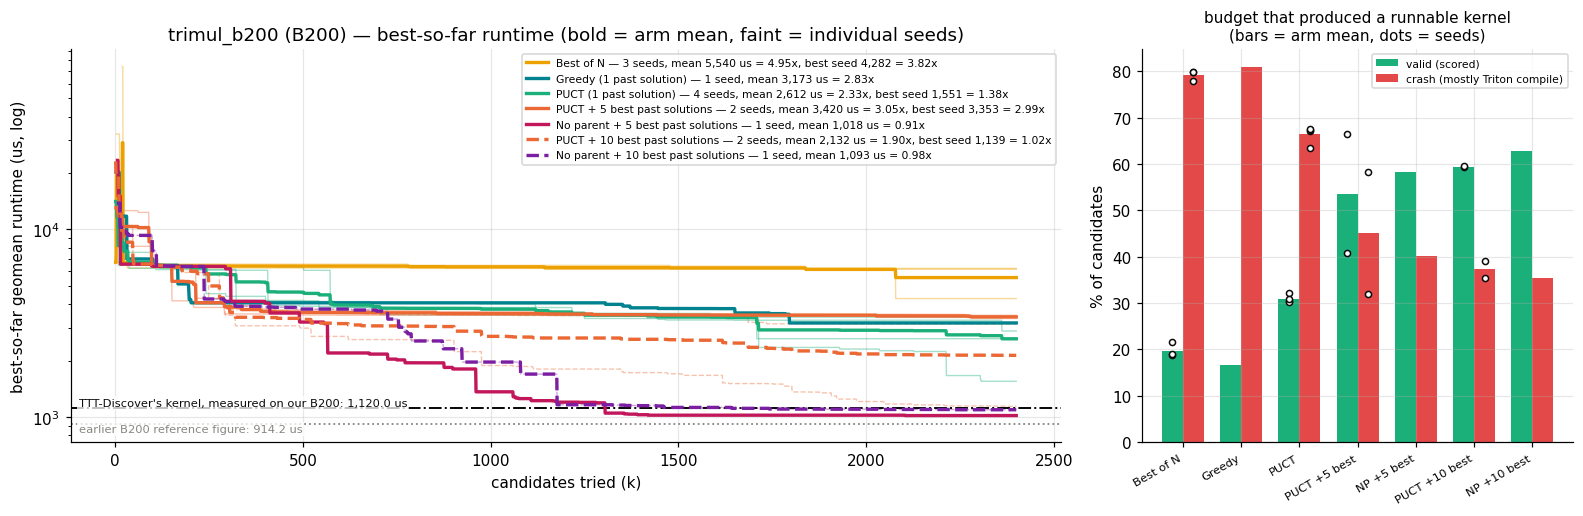

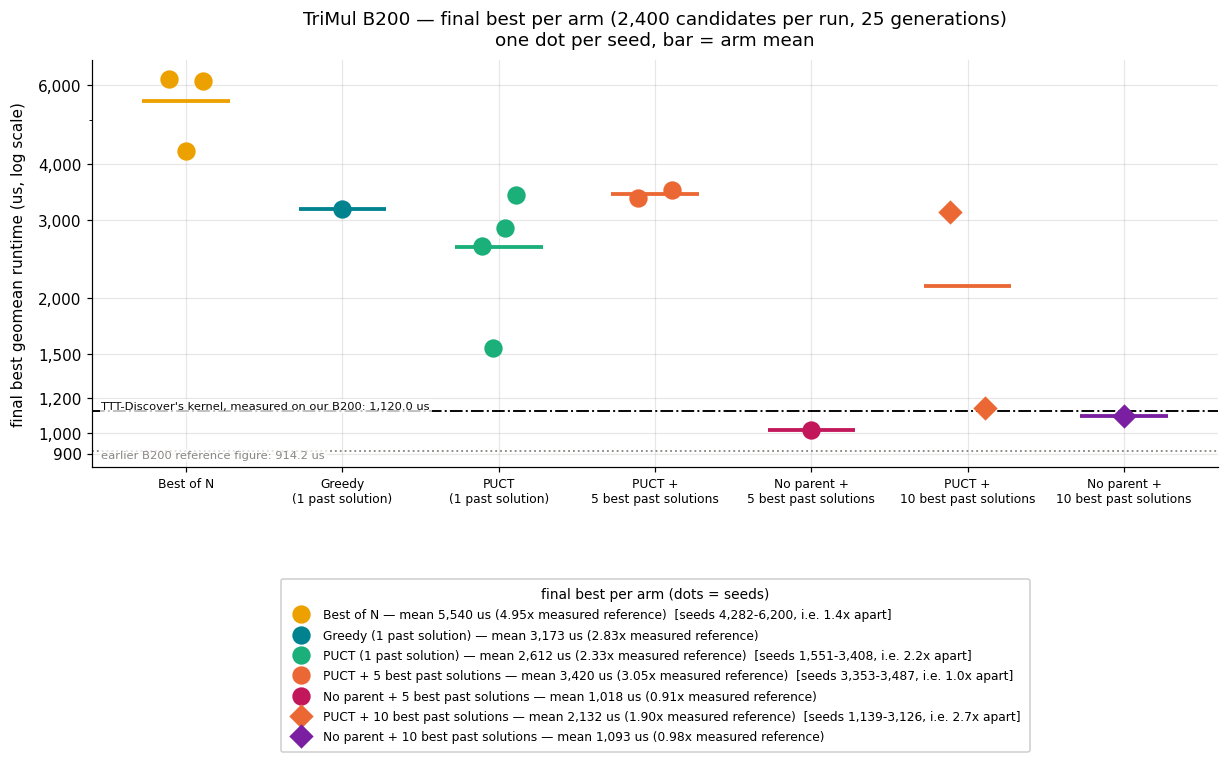

In [18]:
tri_b200, arms_b200 = trimul_plot("trimul_b200", "icl_trimul_b200.png")

# Headline dot plot, same shape as the math problems' §1: one dot per seed, bar = arm mean. Exact
# values live in the legend, since they are hard to read off a log axis.
import matplotlib.ticker as mticker
spec = TRIMUL["trimul_b200"]
fig, ax = plt.subplots(figsize=(max(8.0, 1.6 * len(arms_b200) + 2.0), 4.8))
for i, a in enumerate(arms_b200):
    col, f = arm_color(a["arm"]), a["finals"]
    # n5 best and n10 best share the "best" colour, so the marker shape has to separate them --
    # otherwise their legend swatches are identical
    mk = "D" if "n10" in a["arm"] else "o"
    rng = ("" if a["n_seeds"] == 1
           else f"  [seeds {f.min():,.0f}-{f.max():,.0f}, i.e. {f.max()/f.min():.1f}x apart]")
    # jitter: BoN's 6,200 and 6,139 seeds are one dot apart on a log axis and would read as 2 seeds
    dx = np.linspace(-0.11, 0.11, a["n_seeds"]) if a["n_seeds"] > 1 else np.zeros(1)
    ax.plot(i + dx, f, mk, ms=9 if mk == "D" else 10, color=col, mew=2, zorder=3, ls="none",
            label=f"{arm_label(a['arm'], budget=None)} — mean {f.mean():,.0f} us "
                  f"({f.mean()/spec['ref']:.2f}x measured reference){rng}")
    ax.hlines(f.mean(), i - 0.28, i + 0.28, color=col, lw=2.5, zorder=2)
# both reference lines on the left: the longer label runs into the right spine over there
ref_vals = _trimul_refs(ax, spec, side="left")
ax.set_yscale("log")
# plain tick values: the default 10^3 / 3x10^3 log labels are wide enough to run into the y-axis
# label, and runtimes read better as ordinary numbers
allv = [v for a in arms_b200 for v in a["finals"]] + ref_vals
lo, hi = min(allv) * 0.92, max(allv) * 1.10
ax.set_ylim(lo, hi)
_yt = [v for v in (900, 1000, 1200, 1500, 2000, 3000, 4000, 6000, 8000) if lo <= v <= hi]
ax.set_yticks(_yt)
ax.set_yticklabels([f"{v:,}" for v in _yt])
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.set_xticks(range(len(arms_b200)),
              [arm_tick(a["arm"], budget=None) for a in arms_b200], fontsize=8)
ax.set_xlim(-0.6, len(arms_b200) - 0.4)
ax.set_ylabel("final best geomean runtime (us, log scale)", labelpad=8)
ax.set_title("TriMul B200 — final best per arm (2,400 candidates per run, 25 generations)\n"
             "one dot per seed, bar = arm mean", fontsize=12, pad=10)
# legend goes below the axes: inside it covered the reference-line labels, and on the left the long
# labels pushed it a figure-width away from the data. -0.26 clears the two-line x tick labels.
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.26), fontsize=8, framealpha=0.95,
          borderpad=0.7, labelspacing=0.6, title="final best per arm (dots = seeds)",
          title_fontsize=9)
# no tight_layout here: it shrinks the axes to fit the outside legend. bbox_inches="tight" grows
# the saved canvas instead, so the axes keeps its full width.
fig.savefig("icl_final_trimul_b200.png", dpi=150, bbox_inches="tight")

print(f"{'arm':34s} {'seeds':>5s} {'mean us':>9s} {'best us':>9s} {'worst us':>9s} "
      f"{'x mean':>7s} {'x best':>7s} {'valid%':>7s}")
for a in arms_b200:
    f = a["finals"]
    print(f"{arm_label(a['arm'], budget=None):34s} {a['n_seeds']:5d} {f.mean():9,.0f} "
          f"{f.min():9,.0f} {f.max():9,.0f} {f.mean()/spec['ref']:6.2f}x {f.min()/spec['ref']:6.2f}x "
          f"{100*a['valid'].mean():6.1f}%")
print(f"\nreferences: TTT-Discover's kernel measured on our B200 = {spec['ref']:,.1f} us "
      f"(used for the multipliers); earlier B200 reference figure = 914.2 us")
print("per-seed finals:")
for a in arms_b200:
    print(f"  {arm_label(a['arm'], budget=None):34s} "
          + ", ".join(f"{r}={v:,.0f}" for r, v in zip(a["runs"], a["finals"])))


## 5. Failure anatomy — how much of the budget never produces a number, and why

Every candidate ends in exactly one outcome: **scored**, or one `failure_type`. A failed candidate
still costs a full generation + evaluation, so the failure rate is the *effective* budget: an arm at
62% failures is searching with a third of the candidates its budget suggests.

The taxonomy comes from `sandbox.classify_failure` plus the environments' own `_fail` calls, and it
is worth reading as two questions rather than one — **how much** fails, and **whose fault** it was:

| `failure_type` | what happened | blame |
|---|---|---|
| `process_crash` | the program raised / exited nonzero (on TriMul: mostly Triton compile errors) | the candidate |
| `invalid_result` | it ran, but the answer fails the checker (invalid packing / not a valid bound / no `@triton.jit` / identity kernel) | the candidate |
| `eval_timeout` | exceeded the eval wall-clock cap | the candidate, *but* a loaded host pushes borderline programs over — see §5b |
| `no_code` | no extractable python in the completion (bad format, or a truncated answer) | the model's output format |
| `cpu_starvation` | never got a CPU group from the scheduler | infrastructure |
| `grade_timeout` | async grading gave up | infrastructure |
| `harness_error` | grader missing / GPU dead / grader wrote no results | infrastructure |
| `results_missing` | the eval worker died before writing results | infrastructure |
| `unknown` | traceback matched no rule | unclassified |

Three figures: **(a)** the outcome mix per problem, both as a share of the whole budget and as the
composition of the failures alone; **(b)** the same broken out by arm, which is where the interesting
result is; **(c)** failure rate over the course of a run, which separates a steady tax from an
infrastructure episode.


=== failures per total candidates, per problem ===
problem       runs   cands  scored  failed   process_crash  invalid_resul   eval_timeout        no_code  cpu_starvatio  grade_timeout  harness_error        unknown
ac1             16  37,936   80.8%   19.2%           14.1%           1.1%           3.5%           0.4%           0.0%           0.0%           0.0%           0.0%
ac2             20  48,000   74.3%   25.7%           19.5%           0.3%           3.6%           0.2%           1.9%           0.2%           0.0%           0.0%
erdos           21  49,680   65.6%   34.4%           15.9%           8.7%           5.6%           0.3%           3.9%           0.0%           0.0%           0.0%
trimul_h100      3   1,264   29.5%   70.5%           69.1%           1.1%           0.0%           0.3%           0.0%           0.0%           0.0%           0.0%


trimul_b200     14  33,600   39.0%   61.0%           58.9%           1.3%           0.0%           0.6%           0.0%           0.0%           0.2%           0.0%

=== whose fault: blame split as % of every candidate ===
blame        scored  candidate  format  infra  unclassified
problem                                                    
ac1           80.85      18.74    0.41   0.00          0.00
ac2           74.30      23.42    0.19   2.09          0.01
erdos         65.63      30.20    0.29   3.88          0.00
trimul_h100   29.51      70.17    0.32   0.00          0.00
trimul_b200   39.04      60.16    0.60   0.20          0.00

Note: `eval_timeout` is counted as the candidate's fault here, but it is the one category that
can also be contention-induced (§5b) -- it is 3-6% on the math problems and ~0 on the kernels.


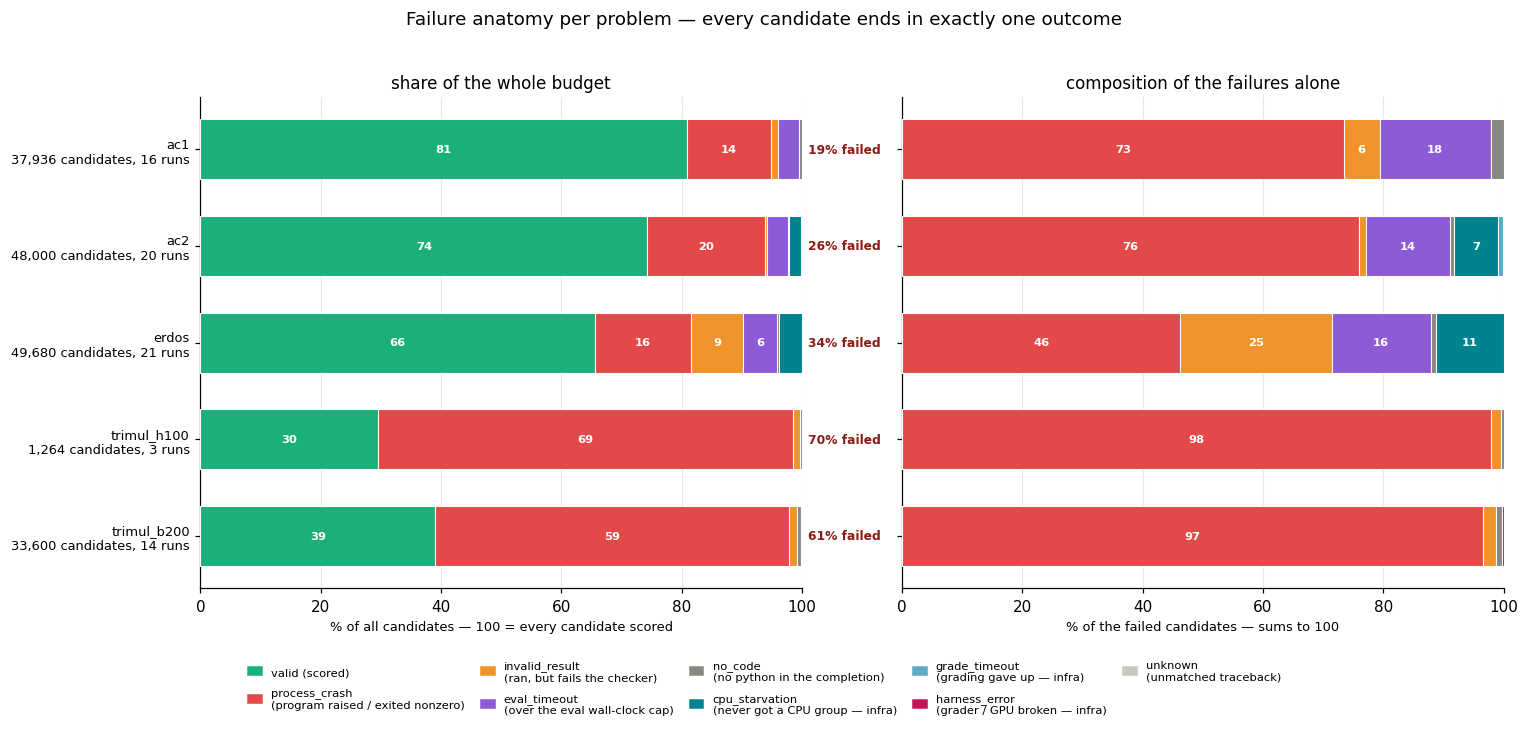

In [19]:
# ---------------------------------------------------------------- failure taxonomy
FAIL_ORDER = ["process_crash", "invalid_result", "eval_timeout", "no_code",
              "cpu_starvation", "grade_timeout", "harness_error", "results_missing", "unknown"]
FAIL_SHORT = {"process_crash": "process_crash\n(program raised / exited nonzero)",
              "invalid_result": "invalid_result\n(ran, but fails the checker)",
              "eval_timeout": "eval_timeout\n(over the eval wall-clock cap)",
              "no_code": "no_code\n(no python in the completion)",
              "cpu_starvation": "cpu_starvation\n(never got a CPU group — infra)",
              "grade_timeout": "grade_timeout\n(grading gave up — infra)",
              "harness_error": "harness_error\n(grader / GPU broken — infra)",
              "results_missing": "results_missing\n(eval worker died — infra)",
              "unknown": "unknown\n(unmatched traceback)"}
# reds/oranges = the candidate's own fault, blues/teals = the machine's, grey = format
FAIL_COLOR = {"process_crash": "#e34948", "invalid_result": "#f0932b", "eval_timeout": "#8e5bd6",
              "no_code": "#898781", "cpu_starvation": "#00838f", "grade_timeout": "#5fa8c7",
              "harness_error": "#c2185b", "results_missing": "#a0522d", "unknown": "#c9c6c0"}
FAIL_BLAME = {"process_crash": "candidate", "invalid_result": "candidate",
              "eval_timeout": "candidate", "no_code": "format",
              "cpu_starvation": "infra", "grade_timeout": "infra", "harness_error": "infra",
              "results_missing": "infra", "unknown": "unclassified"}
VALID_COLOR = "#1baf7a"

# One row per candidate across every campaign the notebook covers. The math arms come from the
# already-loaded `events`; the kernel campaigns are re-read because they are indexed separately
# (nested by arm, so load_grouped_index misses them).
_c = []
for _, r in idx.iterrows():
    _ev = events[(r.group, r["run"])]
    _c.append(pd.DataFrame({"problem": r.group, "arm": r.arm, "run": r["run"],
                            "generation": _ev.generation.to_numpy(),
                            "ft": _ev.failure_type.fillna("").to_numpy()}))
for _grp in ("trimul_h100", "trimul_b200"):
    for _, r in load_runs_under(_grp).iterrows():
        _ev = load_events_path(r.path)
        _c.append(pd.DataFrame({"problem": _grp, "arm": r.arm, "run": r["run"],
                                "generation": _ev.generation.to_numpy(),
                                "ft": _ev.failure_type.fillna("").to_numpy()}))
cand = pd.concat(_c, ignore_index=True)
cand["failed"] = cand.ft != ""
cand["blame"] = cand.ft.map(FAIL_BLAME).fillna("scored")
# a failure_type not in FAIL_ORDER would silently vanish from every stacked bar below
_unseen = set(cand.ft) - set(FAIL_ORDER) - {""}
assert not _unseen, f"failure types missing from FAIL_ORDER: {sorted(_unseen)}"

FAIL_PROBLEMS = [p for p in ["ac1", "ac2", "erdos", "trimul_h100", "trimul_b200"]
                 if (cand.problem == p).any()]

def outcome_shares(g, of="all"):
    """Percentages by outcome for a slice of `cand`. of="all" -> share of every candidate
    (so the parts sum to 100 with `valid`); of="failures" -> composition of the failures only."""
    sub = g if of == "all" else g[g.failed]
    n = len(sub)
    if not n:
        return {}
    out = {k: 100.0 * (sub.ft == k).sum() / n for k in FAIL_ORDER}
    if of == "all":
        out["valid"] = 100.0 * (sub.ft == "").sum() / n
    return {k: v for k, v in out.items() if v > 0}

def stack_bar(ax, y, shares, keys, minlabel=4.0, height=0.62):
    """One horizontal 100% stacked bar. Segments below `minlabel` percent are drawn but not
    labelled in place -- the legend and the printed table carry the small ones."""
    left = 0.0
    for k in keys:
        v = shares.get(k, 0.0)
        if v <= 0:
            continue
        ax.barh(y, v, height, left=left, color=VALID_COLOR if k == "valid" else FAIL_COLOR[k],
                edgecolor="white", lw=0.7, zorder=3)
        if v >= minlabel:
            ax.text(left + v / 2, y, f"{v:.0f}", ha="center", va="center", fontsize=7.5,
                    color="white", fontweight="bold", zorder=4)
        left += v

def fail_legend(fig, keys, include_valid, ncol=5, y=-0.02):
    import matplotlib.patches as mpatches
    h = ([mpatches.Patch(color=VALID_COLOR, label="valid (scored)")] if include_valid else [])
    h += [mpatches.Patch(color=FAIL_COLOR[k], label=FAIL_SHORT[k]) for k in keys]
    fig.legend(handles=h, loc="upper center", bbox_to_anchor=(0.5, y), ncol=ncol, fontsize=7.5,
               frameon=False, handlelength=1.2, labelspacing=0.9, columnspacing=1.4)

# ------------------------------------------------- (a) per problem: mix of the budget, mix of failures
_keys_all = [k for k in FAIL_ORDER if (cand.ft == k).any()]
fig, axes = plt.subplots(1, 2, figsize=(14, 0.62 * len(FAIL_PROBLEMS) + 2.6), sharey=True)
labels = []
for i, p in enumerate(reversed(FAIL_PROBLEMS)):          # worst-failing at the top
    g = cand[cand.problem == p]
    stack_bar(axes[0], i, outcome_shares(g, "all"), ["valid"] + _keys_all)
    stack_bar(axes[1], i, outcome_shares(g, "failures"), _keys_all)
    labels.append(f"{p}\n{len(g):,} candidates, {g.run.nunique()} runs")
for ax, ttl, note in ((axes[0], "share of the whole budget",
                       "% of all candidates — 100 = every candidate scored"),
                      (axes[1], "composition of the failures alone",
                       "% of the failed candidates — sums to 100")):
    ax.set_xlim(0, 100)
    ax.set_xlabel(note, fontsize=8.5)
    ax.set_title(ttl, fontsize=11)
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(range(len(FAIL_PROBLEMS)), labels, fontsize=8.5)
for i, p in enumerate(reversed(FAIL_PROBLEMS)):
    g = cand[cand.problem == p]
    axes[0].text(101, i, f"{100*g.failed.mean():.0f}% failed", va="center", fontsize=8,
                 color="#8c1c13", fontweight="bold")
fig.suptitle("Failure anatomy per problem — every candidate ends in exactly one outcome", y=1.02)
fail_legend(fig, _keys_all, include_valid=True, ncol=5, y=0.0)
fig.tight_layout()
fig.savefig("icl_failures_by_problem.png", dpi=150, bbox_inches="tight")

# ------------------------------------------------- the numbers behind the figure
print("=== failures per total candidates, per problem ===")
print(f"{'problem':13s} {'runs':>4s} {'cands':>7s} {'scored':>7s} {'failed':>7s}   "
      + "  ".join(f"{k[:13]:>13s}" for k in _keys_all))
for p in FAIL_PROBLEMS:
    g = cand[cand.problem == p]
    sh = outcome_shares(g, "all")
    print(f"{p:13s} {g.run.nunique():4d} {len(g):7,d} {sh.get('valid', 0):6.1f}% "
          f"{100*g.failed.mean():6.1f}%   "
          + "  ".join(f"{sh.get(k, 0):12.1f}%" for k in _keys_all))
print("\n=== whose fault: blame split as % of every candidate ===")
_blame = (100 * pd.crosstab(cand.problem, cand.blame, normalize="index")
          ).reindex(FAIL_PROBLEMS)[[c for c in ("scored", "candidate", "format", "infra",
                                                "unclassified") if c in set(cand.blame)]]
print(_blame.round(2).to_string())
print("\nNote: `eval_timeout` is counted as the candidate's fault here, but it is the one category "
      "that\ncan also be contention-induced (§5b) -- it is 3-6% on the math problems and ~0 on the "
      "kernels.")


=== validity by arm (% of the arm's candidates that were scored) ===


problem             ac1   ac2  erdos  trimul_h100  trimul_b200
arm                                                           
BoN                72.6  66.5   57.0         17.2         19.8
Greedy             79.6   NaN   52.4          NaN         16.8
PUCT               77.2  75.3   63.4         38.5         30.9
n5 random          85.6  79.1   73.9          NaN          NaN
n5 best            83.8  71.6   73.3         58.9         53.6
NoParent n5 best    NaN  74.6    NaN          NaN         58.2
n5 contrastive      NaN  63.8   80.4          NaN          NaN
n10 random         87.6  80.7   68.4          NaN          NaN
n10 best            NaN  81.4   52.6          NaN         59.4
NoParent n10 best   NaN   NaN    NaN          NaN         62.8
n10 contrastive    88.5  80.0   82.1          NaN          NaN

=== process_crash rate by arm (the dominant failure everywhere) ===
problem             ac1   ac2  erdos  trimul_h100  trimul_b200
arm                                              

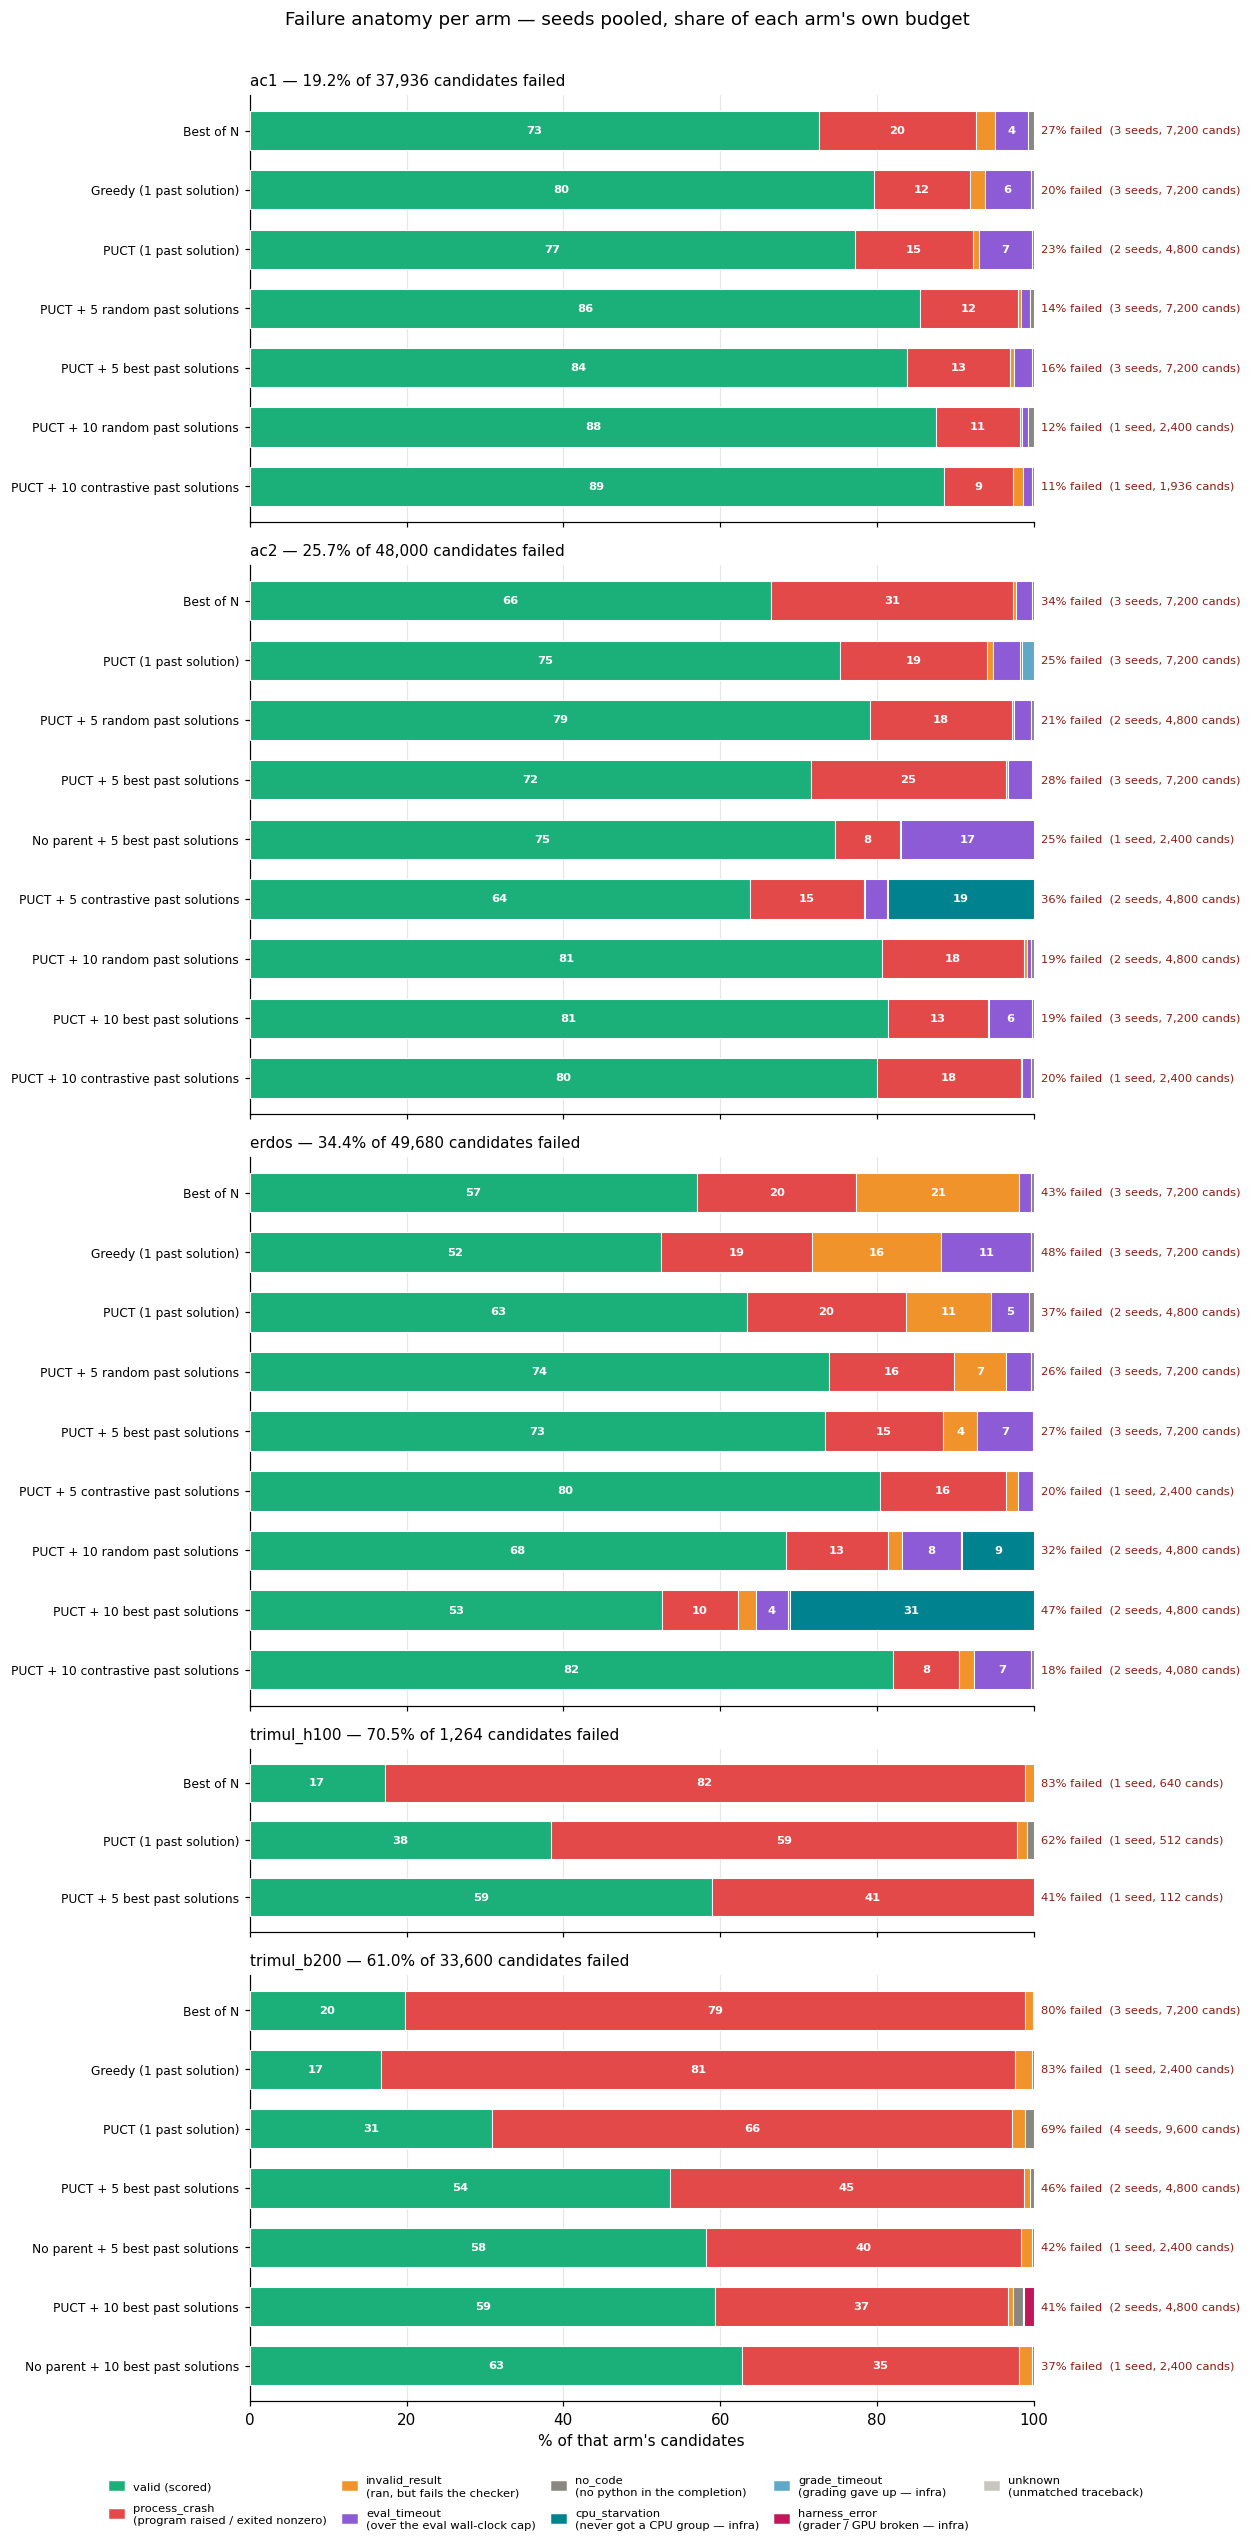

In [20]:
# ------------------------------------------------- (b) per arm: does the arm change the failure mix?
# One panel per problem, one bar per arm (seeds pooled). Panel heights are proportional to the arm
# count so every bar is the same physical thickness across panels.
_arms_of = {p: [a for a in ARM_ORDER if ((cand.problem == p) & (cand.arm == a)).any()]
            for p in FAIL_PROBLEMS}
_rows = [len(_arms_of[p]) for p in FAIL_PROBLEMS]
fig, axes = plt.subplots(len(FAIL_PROBLEMS), 1, figsize=(11.5, 0.42 * sum(_rows) + 1.5 * len(_rows)),
                         gridspec_kw={"height_ratios": _rows}, sharex=True)
for ax, p in zip(np.atleast_1d(axes), FAIL_PROBLEMS):
    g = cand[cand.problem == p]
    arms = _arms_of[p]
    for i, a in enumerate(reversed(arms)):
        ga = g[g.arm == a]
        stack_bar(ax, i, outcome_shares(ga, "all"), ["valid"] + _keys_all, height=0.66)
        ax.text(101, i, f"{100*ga.failed.mean():.0f}% failed  "
                        f"({ga.run.nunique()} seed{'s' if ga.run.nunique() > 1 else ''}, "
                        f"{len(ga):,} cands)", va="center", fontsize=7.5, color="#8c1c13")
    ax.set_yticks(range(len(arms)),
                  [arm_label(a, budget=None) for a in reversed(arms)], fontsize=8)
    ax.set_ylim(-0.6, len(arms) - 0.4)
    ax.set_xlim(0, 100)
    ax.set_title(f"{p} — {100*g.failed.mean():.1f}% of {len(g):,} candidates failed", fontsize=10,
                 loc="left")
    ax.grid(axis="y", visible=False)
np.atleast_1d(axes)[-1].set_xlabel("% of that arm's candidates")
fig.suptitle("Failure anatomy per arm — seeds pooled, share of each arm's own budget", y=1.005)
fail_legend(fig, _keys_all, include_valid=True, ncol=5, y=0.0)
fig.tight_layout()
fig.savefig("icl_failures_by_arm.png", dpi=150, bbox_inches="tight")

# the two numbers the figure is really about, stated plainly
print("=== validity by arm (% of the arm's candidates that were scored) ===")
_v = (100 * cand.assign(ok=~cand.failed).pivot_table(index="arm", columns="problem", values="ok",
                                                     aggfunc="mean")
      ).reindex([a for a in ARM_ORDER if a in set(cand.arm)])[FAIL_PROBLEMS]
print(_v.round(1).to_string())
print("\n=== process_crash rate by arm (the dominant failure everywhere) ===")
_x = (100 * cand.assign(c=cand.ft == "process_crash").pivot_table(index="arm", columns="problem",
                                                                  values="c", aggfunc="mean")
      ).reindex([a for a in ARM_ORDER if a in set(cand.arm)])[FAIL_PROBLEMS]
print(_x.round(1).to_string())


=== runs whose effective budget is materially reduced (infra >1% or timeouts >8%) ===
    problem              arm                      run  cands  scored  infra  timeout
      erdos         n10 best              n10_s2_best   2400    41.4   41.4      4.9
        ac2   n5 contrastive       n05_s2_contrastive   2400    50.0   37.2      1.7
      erdos         n10 best              n10_s1_best   2400    63.8   20.9      3.4
      erdos       n10 random            n10_s1_random   2400    64.9   18.2      1.5
        ac2             PUCT                  puct_s2   2400    72.0    3.3      5.0
trimul_b200         n10 best                   n10_s1   2400    59.5    2.8      0.0
        ac2             PUCT                  puct_s3   2400    79.0    1.3      2.2
      erdos           Greedy          greedy_s1_erdos   2400    50.1    0.0     18.0
        ac2         n10 best              n10_s1_best   2400    76.0    0.0     13.5
        ac1           Greedy            greedy_s3_ac1   2400    

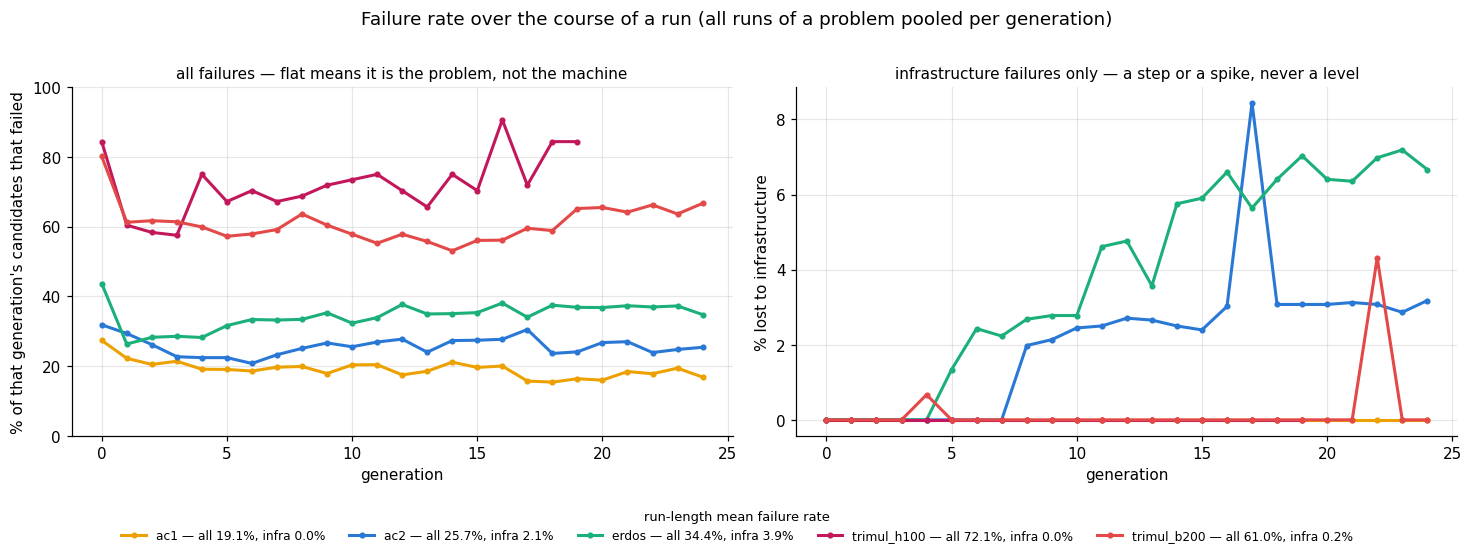

In [21]:
# ------------------------------------------------- (c) does the failure rate drift during a run?
# Left: total failure rate by generation. Right: infrastructure-only. The split matters -- a steady
# line is a property of the problem, a step or a spike is a machine that broke mid-run, and the
# affected run's effective budget has to be discounted before its score is read.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4), sharex=True)
PROB_COLOR = {"ac1": "#eda100", "ac2": "#2a78d6", "erdos": "#1baf7a",
              "trimul_h100": "#c2185b", "trimul_b200": "#e34948"}
handles = []
for p in FAIL_PROBLEMS:
    g = cand[cand.problem == p]
    tot = 100 * g.groupby("generation").failed.mean()
    inf = 100 * g.assign(i=g.blame == "infra").groupby("generation").i.mean()
    for ax, s in ((axes[0], tot), (axes[1], inf)):
        ln, = ax.plot(s.index, s.values, lw=2, color=PROB_COLOR[p], marker="o", ms=3)
    ln.set_label(f"{p} — all {tot.mean():.1f}%, infra {inf.mean():.1f}%")
    handles.append(ln)
axes[0].set_ylim(0, 100)
axes[0].set_title("all failures — flat means it is the problem, not the machine", fontsize=10)
axes[1].set_title("infrastructure failures only — a step or a spike, never a level", fontsize=10)
for ax in axes:
    ax.set_xlabel("generation")
axes[0].set_ylabel("% of that generation's candidates that failed")
axes[1].set_ylabel("% lost to infrastructure")
# one legend below both panels: inside either one it sat on top of a curve
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=5, fontsize=8,
           frameon=False, title="run-length mean failure rate", title_fontsize=8.5)
fig.suptitle("Failure rate over the course of a run (all runs of a problem pooled per generation)",
             y=1.01)
fig.tight_layout()
fig.savefig("icl_failure_drift.png", dpi=150, bbox_inches="tight")

# Which runs actually carry the infrastructure loss -- the pooled lines above average it away.
_by_run = (cand.assign(i=cand.blame == "infra", to=cand.ft == "eval_timeout")
           .groupby(["problem", "arm", "run"])
           .agg(cands=("ft", "size"), scored=("failed", lambda s: 100 * (~s).mean()),
                infra=("i", lambda s: 100 * s.mean()), timeout=("to", lambda s: 100 * s.mean()))
           .reset_index())
_hurt = _by_run[(_by_run.infra > 1) | (_by_run.timeout > 8)].sort_values("infra", ascending=False)
print("=== runs whose effective budget is materially reduced (infra >1% or timeouts >8%) ===")
print(_hurt.round(1).to_string(index=False) if len(_hurt) else "none")
print("\nEffective budget = scored candidates. A run at 41% scored searched with ~990 candidates, "
      "not 2,400,\nso its final score is not comparable to a healthy run's at face value.")


### 5c. Does a run's success rate predict its result?

The obvious question after §5: a run that scored 80% of its candidates searched with twice the
effective budget of one that scored 40% — does that show up in the final answer?

One dot per run: **x = % of its candidates that were scored** (its effective budget), **y = its final
result**. y is `gap%` on the math problems (comparable across them, lower is better) and the plain
`x reference` multiplier on the kernels. Colour = arm, so the confound is visible rather than hidden.

**Read the confound first.** Validity is itself an arm property (§5), and arms differ in result, so a
pooled correlation across runs largely restates "context arms are better *and* crash less" — it is
not evidence that budget alone causes the result. The within-arm points (same colour) are the closer
thing to a controlled comparison, and there are only 2-4 seeds per arm, so treat every ρ below as
descriptive.


=== Spearman rho between a run's validity and its result (negative = higher validity, better result) ===
  ac1          across runs: rho = -0.08  p = 0.770  (n = 16)
  ac2          across runs: rho = +0.04  p = 0.880  (n = 20)
  erdos        across runs: rho = +0.22  p = 0.328  (n = 21)
  trimul_h100  n = 3 runs — not correlated
  trimul_b200  across runs: rho = -0.51  p = 0.061  (n = 14)

=== within arm (the confound-free version), arms with >= 3 seeds ===
  n<=4, so rho here is a direction, not a test -- no p-values are quoted
  ac1          Best of N                          rho = -0.50  (n = 3, validity 72-74%)
  ac1          Greedy (1 past solution)           rho = -1.00  (n = 3, validity 78-83%)
  ac1          PUCT + 5 best past solutions       rho = +0.50  (n = 3, validity 83-85%)
  ac1          PUCT + 5 random past solutions     rho = -0.50  (n = 3, validity 80-91%)
  ac2          Best of N                          rho = -0.50  (n = 3, validity 65-67%)
  ac2          PUCT (1 pa

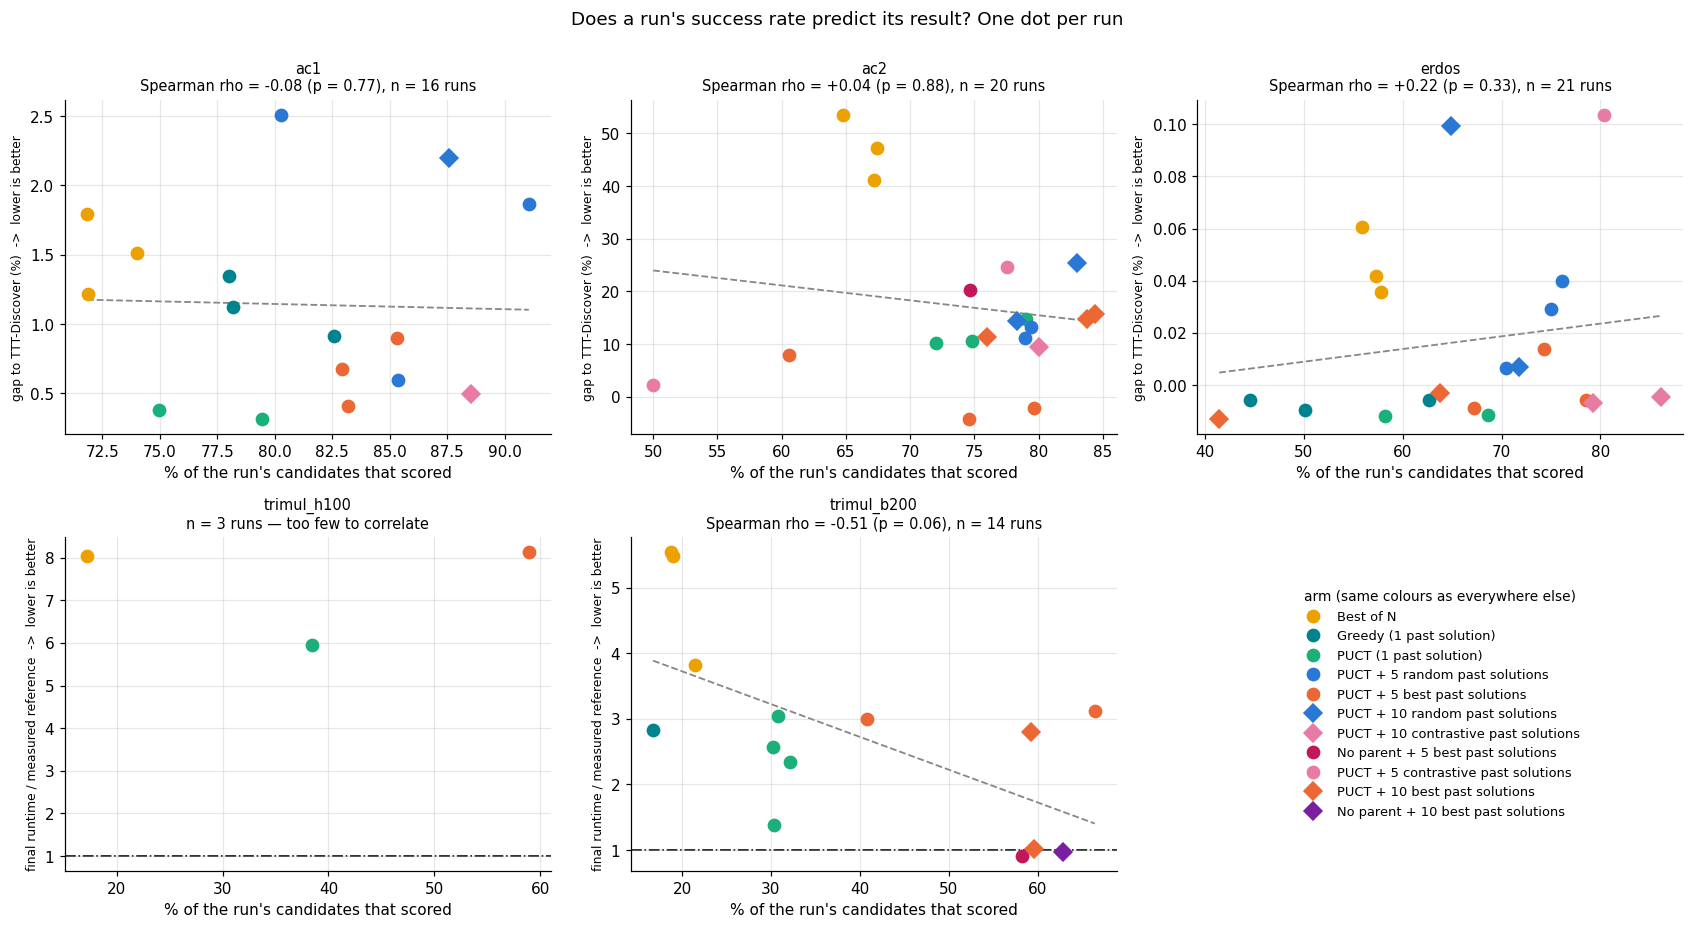

In [22]:
# ------------------------------------------------- (d) validity vs result, one dot per run
from scipy import stats

def _valid_frac(problem, run):
    g = cand[(cand.problem == problem) & (cand.run == run)]
    return 100.0 * (~g.failed).mean(), len(g)

# math problems: y = gap% (comparable across problems). kernels: y = final / measured reference.
VP_PANELS = []
for _p in PROBLEMS:
    rows = []
    for _, r in idx[idx.group == _p].iterrows():
        v, n = _valid_frac(_p, r["run"])
        rows.append(dict(arm=r.arm, run=r["run"], valid=v, y=gap_pct(_p, r.best_score),
                         n=n, complete=r.complete))
    VP_PANELS.append((_p, "gap to TTT-Discover (%)  ->  lower is better", pd.DataFrame(rows)))
for _grp in ("trimul_h100", "trimul_b200"):
    rows = []
    for _, r in load_runs_under(_grp).iterrows():
        v, n = _valid_frac(_grp, r["run"])
        rows.append(dict(arm=r.arm, run=r["run"], valid=v, y=r.best_score / TRIMUL[_grp]["ref"],
                         n=n, complete=r.complete))
    VP_PANELS.append((_grp, "final runtime / measured reference  ->  lower is better",
                      pd.DataFrame(rows)))

fig, axes = plt.subplots(2, 3, figsize=(15.5, 8.4))
for ax, (p, ylab, df) in zip(axes.ravel(), VP_PANELS):
    for a in [a for a in ARM_ORDER if (df.arm == a).any()]:
        d = df[df.arm == a]
        ax.plot(d.valid, d.y, "D" if "n10" in a else "o", ms=8, color=arm_color(a),
                mfc=arm_color(a), ls="none", label=arm_label(a, budget=None), zorder=3)
    if len(df) >= 4:
        rho, pv = stats.spearmanr(df.valid, df.y)
        # least-squares line only as a visual guide -- with n<=21 runs it is not a model
        b, a0 = np.polyfit(df.valid, df.y, 1)
        xs = np.linspace(df.valid.min(), df.valid.max(), 2)
        ax.plot(xs, a0 + b * xs, color="#898781", lw=1.2, ls="--", zorder=1)
        note = f"Spearman rho = {rho:+.2f} (p = {pv:.2f}), n = {len(df)} runs"
    else:
        note = f"n = {len(df)} runs — too few to correlate"
    ax.set_title(f"{p}\n{note}", fontsize=9.5)
    ax.set_xlabel("% of the run's candidates that scored")
    ax.set_ylabel(ylab, fontsize=8)
    if p.startswith("trimul"):
        ax.axhline(1.0, color="#0b0b0b", ls="-.", lw=1.1, zorder=1)
axes.ravel()[-1].axis("off")
# one shared legend in the empty sixth panel -- per-panel legends covered the points
_seen, _h = set(), []
for ax in axes.ravel()[:5]:
    for hh, ll in zip(*ax.get_legend_handles_labels()):
        if ll not in _seen:
            _seen.add(ll); _h.append(hh)
axes.ravel()[-1].legend(handles=_h, loc="center", fontsize=8.5, frameon=False,
                        title="arm (same colours as everywhere else)", title_fontsize=9)
fig.suptitle("Does a run's success rate predict its result? One dot per run", y=1.0)
fig.tight_layout()
fig.savefig("icl_validity_vs_result.png", dpi=150, bbox_inches="tight")

print("=== Spearman rho between a run's validity and its result (negative = higher validity, "
      "better result) ===")
for p, _, df in VP_PANELS:
    if len(df) >= 4:
        rho, pv = stats.spearmanr(df.valid, df.y)
        print(f"  {p:12s} across runs: rho = {rho:+.2f}  p = {pv:.3f}  (n = {len(df)})")
    else:
        print(f"  {p:12s} n = {len(df)} runs — not correlated")
# Within arm the seed counts are 3-4, where a rank correlation can only take the values
# {-1, -0.5, 0, +0.5, +1} and its p-value is meaningless -- printed as a direction, not a test.
print("\n=== within arm (the confound-free version), arms with >= 3 seeds ===")
print("  n<=4, so rho here is a direction, not a test -- no p-values are quoted")
_dirs = []
for p, _, df in VP_PANELS:
    for a, d in df.groupby("arm"):
        if len(d) >= 3:
            rho = stats.spearmanr(d.valid, d.y).statistic
            _dirs.append(rho)
            print(f"  {p:12s} {arm_label(a, budget=None):34s} rho = {rho:+.2f}  "
                  f"(n = {len(d)}, validity {d.valid.min():.0f}-{d.valid.max():.0f}%)")
print(f"\n  {sum(r < 0 for r in _dirs)} of {len(_dirs)} arms point the expected way "
      f"(higher validity -> better result), mean rho = {np.mean(_dirs):+.2f} — i.e. a coin flip.")


## 5b. Eval health per run — the machine confound

§5 asks what fails; this asks **which runs were unlucky with the machine**, because those are the
runs whose score must not be read at face value. Two categories carry the confound:

- **`cpu_starvation`** — the candidate never got a CPU group. Pure infrastructure, and not noise but
  a persistent host condition. It hits **four runs**: erdos `n10_s2_best` (`rb-hpc-b19nd12`) starves
  from **generation 5 onwards and never recovers**, losing **41.4%** of its budget; ac2's
  **`n05_s2_contrastive` loses 37.2%** and scored only **50%** of its 2,400 candidates; erdos
  `n10_s1_best` and `n10_s1_random` (both `rb-hpc-b19nd11`) lose **20.9%** and **18.2%**. Every erdos
  `n10 best` number here therefore rests on roughly half the nominal budget — the first thing to
  check before reading anything into 5-vs-10 context on erdos. The ac2 casualty cuts the other way
  and deserves its own line: **it finished at 0.957846, the second-best single ac2 result, on half a
  budget** (§5c).
- **`eval_timeout`** — the prompt promises a 1000 s budget against an 1100 s cap, so a loaded host
  pushes borderline programs over. It averages **3.5% (ac1) / 3.0% (ac2) / 5.6% (erdos)**, far below
  the 33-56% disasters of earlier campaigns. Worst runs: **`greedy_s1_erdos` 18.0%** (only 50.1% of
  its candidates scored at all), then `erdos/n10_s2_random` 13.5%, `ac2/n10_s1_best` 13.5%,
  `erdos/n05_s2_best` 12.2%, `erdos/n10_s1_contrastive` 12.0%.

Everything else — `process_crash` at 12-31% and, on erdos, `invalid_result` at up to 21% — is the
model writing bad programs, i.e. a property of the arm, not of the host. §5's per-arm figure is the
place to read that.

**Verdict.** Infrastructure noise is real but localised, and it lands hardest on exactly the arm
whose result is weakest: erdos `n10`. `greedy_s1_erdos` and the three starved erdos `n10` runs should
carry an asterisk everywhere they appear. No *ranking* in §1 flips if they are discounted, but the
erdos 5-vs-10 comparison is not usable as it stands.

Table below = worst 6 per problem by timeout rate (full table in `health`).


In [23]:
rows = []
for _, r in idx.iterrows():
    ev = events[(r.group, r["run"])]
    rows.append({"problem": r.group, "run": r["run"], "arm": r.arm, "host": r.host,
                 "valid": round(ev.valid.mean(), 3),
                 "eval_timeout": round((ev.failure_type == "eval_timeout").mean(), 3),
                 "cpu_starvation": round((ev.failure_type == "cpu_starvation").mean(), 3),
                 "crash": round((ev.failure_type == "process_crash").mean(), 3),
                 "complete": r.complete})
health = pd.DataFrame(rows).sort_values(["problem", "eval_timeout"], ascending=[True, False])
health.groupby("problem").head(6)  # worst 6 per problem; full table: `health`

,problem,run,arm,host,valid,eval_timeout,cpu_starvation,crash,complete
5,ac1,greedy_s3_ac1,Greedy,rng-dl01-w24c02,0.826,0.099,0.0,0.067,True
15,ac1,puct_s2,PUCT,rng-dl01-w24c01,0.750,0.072,0.0,0.172,True
14,ac1,puct_s1,PUCT,rb-hpc-b19nd29,0.795,0.064,0.0,0.130,True
4,ac1,greedy_s2_ac1,Greedy,rng-dl01-w24c04,0.780,0.048,0.0,0.155,True
0,ac1,bon_s1,BoN,rng-dl01-w24c02,0.718,0.047,0.0,0.204,True
8,ac1,n05_s2_best,n5 best,rb-hpc-b19nd18,0.853,0.046,0.0,0.092,True
16,ac2,without_puct_n05_s1_best,NoParent n5 best,rb-hpc-b19nd13,0.746,0.169,0.0,0.083,True
27,ac2,n10_s1_best,n10 best,rb-hpc-b19nd03,0.760,0.135,0.0,0.103,True
26,ac2,n05_s3_best,n5 best,rb-hpc-b19nd27,0.746,0.067,0.0,0.183,True
34,ac2,puct_s2,PUCT,rng-dl01-w24c02,0.720,0.050,0.0,0.194,True


## 7. Lineage — where the final best actually comes from

Every candidate records its own id and its parent's, so `events.jsonl` is a complete family tree
(and Shinka's `programs.sqlite` has `parent_id`). The question: is the final best the end of one
lineage being polished, or does it arrive from somewhere nobody was watching?

**Three rules before any number here can be read.**

1. **The unit is the generation, not the candidate.** A generation chooses its 6 parents once and
   then evaluates 96 children in parallel, so two children of one generation can never descend from
   each other. Asked per candidate, "did the new best come from the old best's line?" answers "no"
   almost by construction. Asked per generation it is a real question.
2. **Generation 0 is not a choice** — every arm gets 96 children off the same seed — so it is
   reported separately and excluded from every rate below.
3. **"Parent rank" is measured against every solution found, not against what was selectable.**
   The parent comes from the PUCT buffer, and the buffer is *not* the set of valid solutions:
   `topk_children=2` admits only the two best children of each parent, then dedup and the env's
   construction-length limits cut further, so a run ends with **~300 selectable states out of
   ~1,800 valid solutions**. A parent ranked 20th overall may have been the best thing available.
   Buffer dumps were not kept for these runs and a top-2 reconstruction accounts for only 89% of
   the parents actually used, so the selectable set cannot be recovered — rank is therefore reported
   against all solutions and read as *"how good did this parent look at the time"*, never as *"the
   selector passed over better options"*.

Vocabulary: a **step** is a generation whose best child beat the incumbent; **continuing** = the new
best descends from the incumbent, **lateral** = it does not; **unexpected** = the parent was not one
of the 3 best solutions found so far; **disruptive** = one step that delivered ≥ 10% of the run's
whole post-gen-0 gain. **§7d walks one run line by line** — the quickest way to see what "depth" and
"jump" mean before reading the summaries.

### How to read the two figures

- **`icl_lineage_jumps`** — one dot per improving generation. **x** = how good that generation's
  parent looked at the time (1 = the best solution the run had found, 10 = the 10th best). **y** =
  how much of everything the run gained after generation 0 arrived in that single generation. A dot
  at (8, 40%) reads: *this generation was grown from what was then the 8th-best solution, and it
  delivered 40% of the run's whole post-gen-0 improvement.* Shaded = parent outside the top 3;
  above the dotted line = a disruptive step. **The top-right corner is the question.**
- **`icl_lineage_depth`** — left panel: follow the final best back through its parent, grandparent,
  … up to the seed and count the edges. **1** = the winner is a direct child of the seed and nothing
  was built on. **25** = a new refinement landed in every single generation, which is the ceiling
  when there are 25 generations. Right panel: in how many generations the best-so-far moved at all.

### Generation 0 covers most of the distance, but it never finds the answer

| | gen-0 share of the total gain | after gen 0 | final | final best came from gen 0 |
|---|---:|---:|---:|---:|
| ac1 | 98.4% | 1.517351 (gap **+2.91%**) | 1.508543 (gap **+1.14%**) | 0 of 16 runs |
| ac2 | 30.6% | 0.917610 (gap +76.5%) | 0.949830 (gap +17.1%) | 0 of 20 runs |
| erdos | 99.9% | 0.381016 (gap **+0.124%**) | 0.380895 (gap **+0.017%**) | 0 of 21 runs |

The 98–100% figure is a share of the **distance from the initial solution**, and on ac1 and erdos
that initial solution is so far from the frontier (2.0 → 1.5085; 0.494 → 0.3809) that the first 96
children cover nearly all of it. **It does not mean the answer was found in generation 0 — that
happened in exactly zero runs.** On the scale that matters, generation 0 leaves ac1 at +2.91% and
the remaining 24 generations more than halve that to +1.14%; on erdos it is the difference between
+0.124% (behind TTT-Discover) and +0.017% (level with it). Only **ac2** has a seed far enough from
saturation that the raw split shows the search doing the work (31%).

**Within a problem, read the grey bar backwards.** Generation 0 is the same procedure for every arm —
96 children off the same seed — so the numerator barely moves (ac2: every arm lands at 0.91–0.93).
What changes is the denominator, i.e. how far the run eventually got, which makes the gen-0 share an
*inverse* measure of what the search added. On ac2 that runs from **Best of N at 71.9%** (it improves
by only 0.008 after generation 0 — by construction, it never leaves the seed) to **`PUCT + 5 best` at
22.3%** (0.042) and **`PUCT + 10 contrastive` at 6.0%** (0.046). A big grey bar is not a strength. The
`No parent + 5 best` row is a true **0%**: with no parent in the prompt, its generation 0 produced
nothing that beat the seed at all (0.8657 against the seed's 0.9049), so all of its gain came later.

So: the lineage numbers below
describe the last 1–2% of distance on ac1/erdos — which is the entire margin the arms are ranked by
in §1.

### The winner is a deep chain of solutions that mostly never led

Winning-lineage depth averages **18–23 edits out of a possible 25**, and most complete context arms
sit at **24–25**: a refinement landed in very nearly every generation. (Best of N and the two
no-parent arms sit at 1 by construction — the seed is the only parent they ever use.) But only
**26–50% of the winner's ancestors were ever the best-so-far**: the winning line is largely built
from solutions that never held the lead while they were alive. §7d shows this directly — in the ac2
example, 22 of the 25 chain members were new bests, but the ac1 winner's chain spends long stretches
as a line nobody was tracking.

### About half the progress comes from a line that was not leading

Lateral steps are **36% (erdos) to 60% (ac1)** of all steps and carry **43–81% of the post-gen-0
gain**. The picture is not one lineage being polished: the lead hops between cousins, and the hop is
where most of the improvement lives.

**Why Greedy is not 100% "continuing".** It should be — its parent is always the best-so-far — and on
erdos it is (0–5% lateral). But *best-so-far* means **best in the buffer**, and only the top 2
children of each parent are ever admitted there. On ac1 the buffer's best coincides with the best
solution the run had actually found in only **0, 8 and 10 of 24 generations** (three seeds), against
**22, 23 and 24 of 24** on erdos. When the two diverge, Greedy's child can beat the incumbent without
descending from it, and this analysis scores that as lateral. **That is a fact about the buffer, not
about the arm** — and it is the clearest evidence for rule 3 above. The diagnostic is printed at the
end of the builder cell.

### The big jumps are disproportionately the unexpected ones

| problem | steps | disruptive | of those: unexpected parent | of those: lateral | the other steps: unexpected / lateral |
|---|---:|---:|---:|---:|---:|
| ac1 | 154 | 34 | **44%** | 79% | 20% / 42% |
| ac2 | 295 | 50 | **42%** | 62% | 32% / 51% |
| erdos | 329 | 35 | **26%** | 43% | 20% / 38% |
| TriMul B200 | 138 | 19 | **53%** | 79% | 39% / 58% |

A disruptive step is **1.3–2.2× more likely to have grown from a parent outside the top 3** than an
ordinary step, and 1.1–1.9× more likely to be lateral; median parent rank 3–4 against 1–2. So yes —
the big jumps do come from solutions that did not look like the front-runners. Two honest limits on
that: **the scale is modest** ("unexpected" here mostly means *4th to 20th best*, not a nobody — out
of a pool of hundreds, the median disruptive parent is still near the top), and **this is not a
statement about the selector** (rule 3) — it says where the jumps came from, not what was passed
over. §7d has a clean instance: in the ac2 run, generation 4 grew from what was then the **12th-best
of 278** solutions and delivered **26.9%** of everything the run gained after generation 0.

**Problems differ in an interpretable direction.** erdos is the most incremental (26% unexpected,
36% lateral, median parent rank 1) — its seed is already near-optimal, so progress is a grind in the
5th decimal off whatever leads. ac1, ac2 and especially **B200 (53% unexpected, 79% lateral)** are the
disruptive ones; on a kernel, progress often means switching implementation strategy, which is
exactly what jumping to another line is.

### Context strategy changes this measurably

| arm | steps | lateral | unexpected parent | median parent rank |
|---|---:|---:|---:|---:|
| Greedy | 86 | 10.5% | 0% | 1 |
| PUCT (parent only) | 186 | 44.1% | 25.3% | 1 |
| PUCT + 5 random | 120 | 43.3% | 21.7% | 1 |
| PUCT + 10 random | 70 | 44.3% | 32.9% | 1 |
| PUCT + 10 contrastive | 74 | 52.7% | 36.5% | 2 |
| PUCT + 5 contrastive | 50 | 58.0% | 36.0% | 2 |
| PUCT + 10 best | 149 | 59.7% | 35.6% | 2 |
| PUCT + 5 best | 188 | **61.2%** | **37.2%** | 2 |

Greedy's 10.5% is the floor (see the caveat above for why it is not 0%). From there laterality rises
with in-prompt history: parent-only 44% → `random` 43–44% → `contrastive` 53–58% → `best` 60–61%,
and the unexpected-parent rate 25% → 22–33% → 36–37% → 36–37%. **Showing the top past solutions lets
progress come from a parent that was not the front-runner**, because the elite is in the prompt
whatever the parent is — the parent slot no longer has to carry the best-known information. That is a
plausible mechanism for §1's headline (`PUCT + 5 best` is the strongest ac2 arm): not just seeing
more, but being free to start from somewhere else.

### Shinka is the extreme of the same behaviour — and that is why it plateaus

| | steps (of 25 blocks) | depth | ancestors that led | lateral | median parent rank | unexpected |
|---|---:|---:|---:|---:|---:|---:|
| ac1 r1 / r2 | 12 / 4 | 14 / 10 | 15% / 0% | 79% / 86% | 15 / 21 | 68% / 71% |
| ac2 r1 / r2 | 4 / 1 | 11 / 12 | 10% / 0% | 86% / 100% | 37 / 2 | 86% / 0% |
| erdos r1 / r2 | 11 / 5 | 24 / 11 | 4% / 0% | 78% / 91% | 5 / 41 | 57% / 82% |

- **Shinka improves almost entirely off-lead.** 78–100% of its steps are lateral and its median
  parent sits at **rank 5–41** against 1–2 for every ICL arm. Its archive (`archive_size: 40`), two
  islands and crowding selection are built to sample away from the leader — here the filtering is
  the documented intent, not an artefact, though rule 3 applies to it just as much. Note what that
  does to the disruptive/ordinary contrast that holds for the ICL arms: for Shinka there is none —
  64–75% of its *ordinary* steps also come from unexpected parents. Off-lead is its normal operation.
- **Its winning line is a dark horse**: 0–15% of the winner's ancestors ever held the lead.
- **It never accumulates depth.** After ~2,400 *sequential* generations its winner is **10–24 edits
  deep** — the same range the ICL runs reach in 25 generations, where 25 is their hard ceiling.
  Shinka had roughly a hundred times more opportunity to go deeper and did not. Put next to §4b's
  "converges fast, then sits on 0.948944 from k=466 to k=2,174", that is a mechanism and not just a
  shape: the run stops deepening.
- Its best-so-far moves in only **1–12 of the 25 budget-blocks**, against 12–24 generations for the
  ICL arms.
- **Crossover has no ICL analogue**: 37% / 26% of r1's steps on ac1 / erdos are `cross` patches (0%
  on ac2) — improvements built from two parents at once.

### Caveats

- **The context solutions are not in the tree.** Only the parent edge is recorded, but a child also
  saw 5–10 past solutions. Every "lateral" rate is a *lower bound* on how much of a step came from
  outside the incumbent's line, and the bound is loosest exactly where it matters — the context arms.
- **Rank is not selection** (rule 3), and **Best of N / no-parent arms are star-shaped** (the seed is
  their only parent), so their 100% laterality, depth of 1 and Best of N's median rank of 146
  describe the design, not a search behaviour. They stay in the tables, out of the per-problem means.
- Rates pool steps across the seeds of an arm, so a seed that kept improving weighs more than one
  that stalled; several arms are still one seed.
- **The one axis this points at and we have not run**: the depth ceiling is the generation count and
  the winners are sitting on it. At a fixed 2,400-candidate budget, more generations of fewer
  children would let a lineage go deeper — Shinka shows sequential opportunity alone is not enough,
  but the ICL arms have never had more than 25 rounds.

In [24]:
# ---------------------------------------------------------------- lineage: who begat the winner
# `events.jsonl` names every candidate (`sol`) and its parent (`parent_sol`), with `seed` as the
# root, so each run is a complete family tree. Failures are never named, so they can never be
# parents. Two structural facts decide how any number here has to be read:
#
#  1. THE UNIT IS THE GENERATION, NOT THE CANDIDATE. A generation picks its 6 parents once and then
#     evaluates 96 children in parallel, so two children of the same generation can never descend
#     from each other. "Did the new best come from the old best's line?" asked per *candidate*
#     answers "no" almost by construction; asked per *generation* it is a real question about the
#     parent that was actually chosen. Every rate below is per generation.
#  2. GENERATION 0 IS NOT A CHOICE. Every arm gets 96 children off the same seed, so gen-0 is
#     reported separately as `gen-0 share` and excluded from every lineage rate.
#
# Vocabulary, used everywhere below:
#   step         a generation whose best child beat the incumbent best-so-far
#   continuing   the new best descends from the incumbent (its line was refined)
#   lateral      it does not -- a cousin, or a line that had been left alone for a while
#   parent rank  where the chosen parent stood among EVERY valid solution the run had found by
#                then (1 = the best of them). Read it as "how good did this parent look at the
#                time", NOT as "the selector passed over better options" -- see the note below.
#   unexpected   the parent was not one of the 3 best solutions found so far
#   disruptive   one step that delivered >= 10% of the run's whole post-gen-0 gain
#
# WHAT `parent rank` CANNOT SAY. The parent is chosen from the PUCT *buffer*, and the buffer is not
# the set of valid solutions: `topk_children=2` admits only the two best children of each parent
# (then dedup and the env's construction-length limits cut further), so a 25-generation run ends
# with ~300 selectable states out of ~1,800 valid solutions. A parent ranked 20th overall may well
# have been the best thing available. The Greedy diagnostic printed at the end of this cell is the
# cleanest demonstration: its parent is BY DEFINITION the buffer's best, and on ac1 that coincides
# with the best solution found in only 0-10 of 24 generations. Buffer dumps were not kept for these
# runs and a top-2 reconstruction only accounts for 89% of the parents actually used, so the
# selectable set cannot be recovered exactly -- hence rank is reported against all solutions, with
# this caveat attached, rather than silently against the wrong pool.
DISRUPTIVE, UNEXPECTED = 10.0, 3
LIN_COLOR = {"gen0": "#c9c6c0", "continuing": "#2a78d6", "lateral": "#eb6834"}

def _ancestors(par, sol):
    out, x = set(), sol
    while x in par and par[x] is not None and par[x] not in out:
        x = par[x]
        out.add(x)
    return out

def lineage(ev, maximize, baseline=None):
    """Generation-level lineage anatomy for one ICL run. `ev` is an events frame in evaluation
    order. `baseline` is the initial solution's score, which anchors the gen-0 share; the kernel
    problems never scored their seed, so they pass None and only the post-gen-0 half is defined."""
    better = (lambda a, b: a > b) if maximize else (lambda a, b: a < b)
    par, score, depth, root = {}, {}, {"seed": 0}, {}
    best, best_sol, best0 = baseline, "seed", None
    # the seed is a real member of the buffer -- PUCT can select it and Best of N selects nothing
    # else -- so it has to carry its score, or "parent rank" is undefined for exactly those arms.
    # The kernel problems never scored their seed (baseline=None), so there it stays out.
    pool = ["seed"] if baseline is not None else []
    if baseline is not None:
        score["seed"] = baseline
    steps, incumbents = [], set()
    by_gen = {}
    for r in ev[["generation", "parent_sol", "sol", "raw_score", "valid"]].to_dict("records"):
        by_gen.setdefault(r["generation"], []).append(r)
    for g in sorted(by_gen):
        # pool = every valid solution found before this generation (NOT the selectable buffer,
        # which is far smaller -- see the note at the top of this cell)
        pool_scores = np.asarray([score[s] for s in pool], dtype=float)
        start_best, start_sol = best, best_sol
        newborn = []
        for r in by_gen[g]:
            sol = r["sol"]
            if not isinstance(sol, str) or not r["valid"]:
                continue
            score[sol] = r["raw_score"]
            par[sol] = r["parent_sol"]
            depth[sol] = depth.get(r["parent_sol"], 0) + 1
            # root = the generation-0 ancestor, i.e. which of the seed's children this line grew from
            root[sol] = sol if (g == 0 or r["parent_sol"] == "seed") else root.get(r["parent_sol"], sol)
            newborn.append(sol)
        if newborn:
            b = (max if maximize else min)(newborn, key=lambda s: score[s])
            if start_best is None or better(score[b], start_best):
                if start_best is not None:
                    ps = score.get(par[b], np.nan)
                    rank = (np.nan if (np.isnan(ps) or not len(pool_scores))
                            else int(((pool_scores > ps) if maximize else (pool_scores < ps)).sum() + 1))
                    anc = _ancestors(par, b)
                    steps.append(dict(gen=g, sol=b, parent=par[b], score=score[b],
                                      jump=abs(score[b] - start_best), parent_score=ps,
                                      parent_rank=rank, pool=len(pool_scores),
                                      continuing=(par[b] == start_sol or start_sol in anc),
                                      root=root[b], prev_root=root.get(start_sol, "seed"),
                                      depth=depth[b]))
                best, best_sol = score[b], b
                incumbents.add(b)
        pool += newborn
        if g == 0:
            best0 = best
    chain, x = [], best_sol
    while x != "seed" and x in par:
        chain.append(x)
        x = par[x]
    chain = list(reversed(chain))
    post = abs(best - best0) if (best is not None and best0 is not None) else np.nan
    total = abs(best - baseline) if baseline is not None else np.nan
    S = pd.DataFrame(steps)
    if not S.empty:
        S["share_post"] = np.where(S.gen > 0, 100 * S.jump / post if post > 0 else np.nan, np.nan)
        S["lateral"] = ~S.continuing
        S["disruptive"] = S.share_post >= DISRUPTIVE
        S["unexpected"] = S.parent_rank > UNEXPECTED
        S["on_chain"] = S.sol.isin(set(chain))
        S["root_switch"] = S.root != S.prev_root
    return dict(best=best, best_sol=best_sol, best0=best0, post=post, total=total,
                g0=abs(best0 - baseline) if (baseline is not None and best0 is not None) else np.nan,
                steps=S, chain=chain, depth=len(chain), ngen=len(by_gen),
                root=root.get(best_sol), incumbents=incumbents,
                # the winner itself is trivially an incumbent, so it is left out of chain_led:
                # the question is how much of the line BEHIND it was ever visible as the leader
                chain_led=(100 * len(set(chain[:-1]) & incumbents) / (len(chain) - 1)
                           if len(chain) > 1 else np.nan))

def shinka_lineage(path, problem):
    """The same anatomy for one Shinka seed, from `programs.sqlite` (`parent_id` is the lineage).
    Granularity differs and that matters: Shinka evaluates ONE program per generation, so it gets
    2,400 fresh parent choices where an ICL run gets 25. Its steps are therefore counted per
    candidate, and `blocks` -- the number of 96-candidate blocks (= one ICL generation of budget)
    in which the best improved -- is the count that can be put next to an ICL run's step count."""
    hi = PROBLEMS[problem]["maximize"]
    better = (lambda a, b: a > b) if hi else (lambda a, b: a < b)
    con = sqlite3.connect(f"file:{os.path.join(path, 'programs.sqlite')}?mode=ro", uri=True)
    df = pd.read_sql_query("SELECT id, generation, parent_id, correct, public_metrics, island_idx, "
                           "metadata FROM programs ORDER BY timestamp", con)
    con.close()
    df = df.drop(df.index[df.generation == 0][1:]).reset_index(drop=True)
    df["raw"] = df.public_metrics.apply(
        lambda s: (json.loads(s) or {}).get(SHINKA_KEY[problem]) if s else None)
    df["ptype"] = df.metadata.apply(lambda m: (json.loads(m) or {}).get("patch_type") if m else None)
    par, score, depth = {}, {}, {}
    best, best_sol, best0 = PROBLEMS[problem]["initial"], "seed", None
    pool, steps, incumbents = [], [], set()
    for k, row in enumerate(df.itertuples(), start=1):
        if k == 97:
            best0 = best
        if not row.correct or row.raw is None:
            continue
        score[row.id] = row.raw
        par[row.id] = row.parent_id
        depth[row.id] = depth.get(row.parent_id, 0) + 1
        if better(row.raw, best):
            arr = np.asarray(pool, dtype=float)
            ps = score.get(row.parent_id, np.nan)
            rank = (np.nan if (np.isnan(ps) or not len(arr))
                    else int(((arr > ps) if hi else (arr < ps)).sum() + 1))
            anc = _ancestors(par, row.id)
            steps.append(dict(gen=(k - 1) // 96, k=k, sol=row.id, parent=row.parent_id,
                              score=row.raw, jump=abs(row.raw - best), parent_score=ps,
                              parent_rank=rank, pool=len(arr),
                              continuing=(row.parent_id == best_sol or best_sol in anc),
                              depth=depth[row.id], island=row.island_idx, ptype=row.ptype))
            best, best_sol = row.raw, row.id
            incumbents.add(row.id)
        pool.append(row.raw)
    if best0 is None:
        best0 = best
    chain, x = [], best_sol
    while x in par and par[x] is not None and x != "seed":
        chain.append(x)
        x = par[x]
    chain = list(reversed(chain))
    post = abs(best - best0)
    S = pd.DataFrame(steps)
    if not S.empty:
        S["share_post"] = np.where(S.gen > 0, 100 * S.jump / post if post > 0 else np.nan, np.nan)
        S["lateral"] = ~S.continuing
        S["disruptive"] = S.share_post >= DISRUPTIVE
        S["unexpected"] = S.parent_rank > UNEXPECTED
        S["on_chain"] = S.sol.isin(set(chain))
    return dict(best=best, best_sol=best_sol, best0=best0, post=post,
                total=abs(best - PROBLEMS[problem]["initial"]),
                g0=abs(best0 - PROBLEMS[problem]["initial"]), steps=S, chain=chain,
                depth=len(chain), ngen=len(df), cands=len(df),
                blocks=int(S[S.gen > 0].gen.nunique()) if not S.empty else 0,
                chain_led=(100 * len(set(chain[:-1]) & incumbents) / (len(chain) - 1)
                           if len(chain) > 1 else np.nan))

# ------------------------------------------------- build it for every run, both paradigms
LIN, _lsteps, _lrows = {}, [], []

def _lin_register(problem, arm, run, L, paradigm="ICL", ngen=None, blocks=None):
    LIN[(problem, run)] = L
    S = L["steps"]
    if not S.empty:
        _lsteps.append(S.assign(problem=problem, arm=arm, run=run, paradigm=paradigm))
    Sp = S[S.gen > 0] if not S.empty else S
    n = len(Sp)
    _lrows.append(dict(
        problem=problem, arm=arm, run=run, paradigm=paradigm,
        gens=ngen if ngen is not None else L["ngen"],
        steps=blocks if blocks is not None else n,
        g0_share=100 * L["g0"] / L["total"] if L["total"] and not np.isnan(L["total"]) else np.nan,
        depth=L["depth"], chain_led=L["chain_led"],
        top1=Sp.share_post.max() if n else np.nan,
        lateral_pct=100 * Sp.lateral.mean() if n else np.nan,
        lat_mass=100 * Sp[Sp.lateral].jump.sum() / L["post"] if n and L["post"] > 0 else np.nan,
        med_rank=Sp.parent_rank.median() if n else np.nan,
        unexp_pct=100 * Sp.unexpected.mean() if n else np.nan,
        disr=int(Sp.disruptive.sum()) if n else 0,
        disr_unexp=100 * Sp[Sp.disruptive].unexpected.mean() if n and Sp.disruptive.any() else np.nan))

for _, _r in idx.iterrows():
    _spec = PROBLEMS[_r.group]
    _lin_register(_r.group, _r.arm, _r["run"],
                  lineage(events[(_r.group, _r["run"])], _spec["maximize"], _spec["initial"]))
# the kernel campaigns never scored their seed, so they pass baseline=None: no gen-0 share, but the
# post-gen-0 lineage questions are exactly the same
for _grp in ("trimul_h100", "trimul_b200"):
    for _, _r in load_runs_under(_grp).iterrows():
        _lin_register(_grp, _r.arm, _r["run"], lineage(load_events_path(_r.path), False, None))
for _p in PROBLEMS:
    for _d in sorted(glob.glob(os.path.join(SHINKA_ROOT, SHINKA_SUB[_p], "results", "*_qwen_meta_r*"))):
        if not os.path.exists(os.path.join(_d, "programs.sqlite")):
            continue
        _seed = os.path.basename(_d).rsplit("_", 1)[-1]
        _L = shinka_lineage(_d, _p)
        _lin_register(_p, "Shinka", f"Shinka {_seed}", _L, paradigm="Shinka",
                      ngen=_L["cands"], blocks=_L["blocks"])

LSTEP = pd.concat(_lsteps, ignore_index=True)
LRUN = pd.DataFrame(_lrows)
LIN_PROBLEMS = [p for p in ["ac1", "ac2", "erdos", "trimul_h100", "trimul_b200"]
                if (LRUN.problem == p).any()]
LSTEP_POST = LSTEP[LSTEP.gen > 0].copy()

# Best of N and the no-parent arms have no tree to speak of: their parent is the seed in every
# generation, so "lateral" and "unexpected parent" are true of them by construction, not by search.
# They are kept in the tables (the numbers are correct) but excluded from the per-problem means.
STAR_ARMS = ("BoN", "NoParent n5 best", "NoParent n10 best")
print("=== how the improvement splits, per problem (ICL arms; mean over runs) ===")
print("gen-0 share = % of the total gain from the seed that the very first batch of 96 already had")
_icl = LRUN[LRUN.paradigm == "ICL"]
print(_icl[~_icl.arm.isin(STAR_ARMS)].groupby("problem")[
    ["g0_share", "steps", "depth", "chain_led", "top1", "lateral_pct", "lat_mass", "med_rank",
     "unexp_pct"]]
    .mean().reindex(LIN_PROBLEMS).round(1).to_string())
print("\n=== disruptive steps (>= 10% of the post-gen-0 gain in one generation): who was the parent? ===")
for _p in LIN_PROBLEMS:
    _s = LSTEP_POST[(LSTEP_POST.problem == _p) & (LSTEP_POST.paradigm == "ICL")
                    & ~LSTEP_POST.arm.isin(STAR_ARMS)]
    _d, _n = _s[_s.disruptive], _s[~_s.disruptive]
    if not len(_s):
        continue
    print(f"  {_p:12s} {len(_s):4d} steps, {100*len(_d)/len(_s):4.1f}% disruptive | "
          f"disruptive: {100*_d.lateral.mean():3.0f}% lateral, {100*_d.unexpected.mean():3.0f}% "
          f"unexpected parent, median rank {_d.parent_rank.median():4.0f} | "
          f"the rest: {100*_n.lateral.mean():3.0f}% lateral, {100*_n.unexpected.mean():3.0f}% "
          f"unexpected, median rank {_n.parent_rank.median():4.0f}")
print("\n=== Shinka, same measurements (per candidate -- it gets 2,400 parent choices, not 25) ===")
_shk = LRUN[LRUN.paradigm == "Shinka"]
print(_shk[["problem", "run", "gens", "steps", "g0_share", "depth", "chain_led", "top1",
            "lateral_pct", "lat_mass", "med_rank", "unexp_pct", "disr"]]
      .to_string(index=False, float_format=lambda v: f"{v:7.1f}"))
# crossover has no ICL analogue: an improvement built from two parents at once
_sk = LSTEP_POST[LSTEP_POST.paradigm == "Shinka"]
print("crossover share of those steps: " + ", ".join(
    f"{_p} {_r.split()[-1]} {100 * _g.ptype.eq('cross').mean():.0f}%"
    for (_p, _r), _g in _sk.groupby(["problem", "run"])))

# ------------------------------------------------- was the final best already there in generation 0?
# The gen-0 share above is a share of the DISTANCE FROM THE INITIAL SOLUTION, and on ac1/erdos that
# initial solution is so far from the frontier that the first 96 children cover almost all of it.
# That is not the same as "the answer was found immediately": in gap% -- the scale that matters --
# generation 0 leaves a lot on the table, and no run's final best came out of generation 0.
print("\n=== generation 0 vs the final best (mean over runs) ===")
for _p in PROBLEMS:
    _b0, _bf, _same = [], [], 0
    for _, _r in idx[idx.group == _p].iterrows():
        _ev = events[(_p, _r["run"])]
        _v = _ev.raw_score.where(_ev.valid)
        _g0 = _v[_ev.generation == 0].dropna()
        if _g0.empty:
            continue
        _f = (_v.max() if PROBLEMS[_p]["maximize"] else _v.min())
        _z = (_g0.max() if PROBLEMS[_p]["maximize"] else _g0.min())
        _b0.append(_z); _bf.append(_f); _same += int(_z == _f)
    print(f"  {_p:6s} n={len(_b0):2d}  after gen 0: {np.mean(_b0):.6f} (gap {gap_pct(_p, np.mean(_b0)):+7.3f}%)"
          f"   final: {np.mean(_bf):.6f} (gap {gap_pct(_p, np.mean(_bf)):+7.3f}%)"
          f"   | final best came from gen 0 in {_same}/{len(_b0)} runs")

# ------------------------------------------------- why Greedy is not 100% "continuing"
# Greedy's parent is always the buffer's best -- which is NOT always the best solution the run has
# found, because only the top 2 children of each parent are ever admitted to the buffer. When the
# two diverge, Greedy's child can beat the incumbent without descending from it, and this analysis
# scores that as `lateral`. It is a fact about the buffer, not about the arm.
print("\n=== Greedy diagnostic: was its parent the best solution the run had found? ===")
for _, _r in idx[idx.arm == "Greedy"].sort_values(["group", "run"]).iterrows():
    _ev = events[(_r.group, _r["run"])]
    _hi = PROBLEMS[_r.group]["maximize"]
    _score, _best, _bsol, _agree, _tot = {}, None, "seed", 0, 0
    for _g, _blk in _ev.groupby("generation", sort=True):
        if _g > 0:
            _tot += 1
            _agree += int(set(_blk.parent_sol) == {_bsol})
        for _row in _blk.itertuples():
            if isinstance(_row.sol, str) and _row.valid:
                _score[_row.sol] = _row.raw_score
                if _best is None or ((_row.raw_score > _best) if _hi else (_row.raw_score < _best)):
                    _best, _bsol = _row.raw_score, _row.sol
    print(f"  {_r.group:6s} {_r['run']:18s} parent == best solution found in {_agree:2d}/{_tot} generations")


=== how the improvement splits, per problem (ICL arms; mean over runs) ===
gen-0 share = % of the total gain from the seed that the very first batch of 96 already had
             g0_share  steps  depth  chain_led  top1  lateral_pct  lat_mass  med_rank  unexp_pct
problem                                                                                         
ac1              98.4   11.8   18.2       25.7  54.7         60.4      78.3       6.4       31.0
ac2              30.6   18.4   22.2       30.7  38.4         54.0      58.8       2.0       35.9
erdos            99.9   18.3   21.7       49.9  67.2         35.7      43.2       1.4       19.2
trimul_h100       NaN    3.5    5.0       53.3  73.7         41.7      24.3       2.2       25.0
trimul_b200       NaN   15.3   20.8       29.7  51.8         57.0      80.5       2.9       37.9

=== disruptive steps (>= 10% of the post-gen-0 gain in one generation): who was the parent? ===
  ac1           154 steps, 22.1% disruptive | disruptive:

  ac1    greedy_s2_ac1      parent == best solution found in  0/24 generations
  ac1    greedy_s3_ac1      parent == best solution found in  8/24 generations
  erdos  greedy_s1_erdos    parent == best solution found in 23/24 generations
  erdos  greedy_s2_erdos    parent == best solution found in 24/24 generations


  erdos  greedy_s3_erdos    parent == best solution found in 22/24 generations


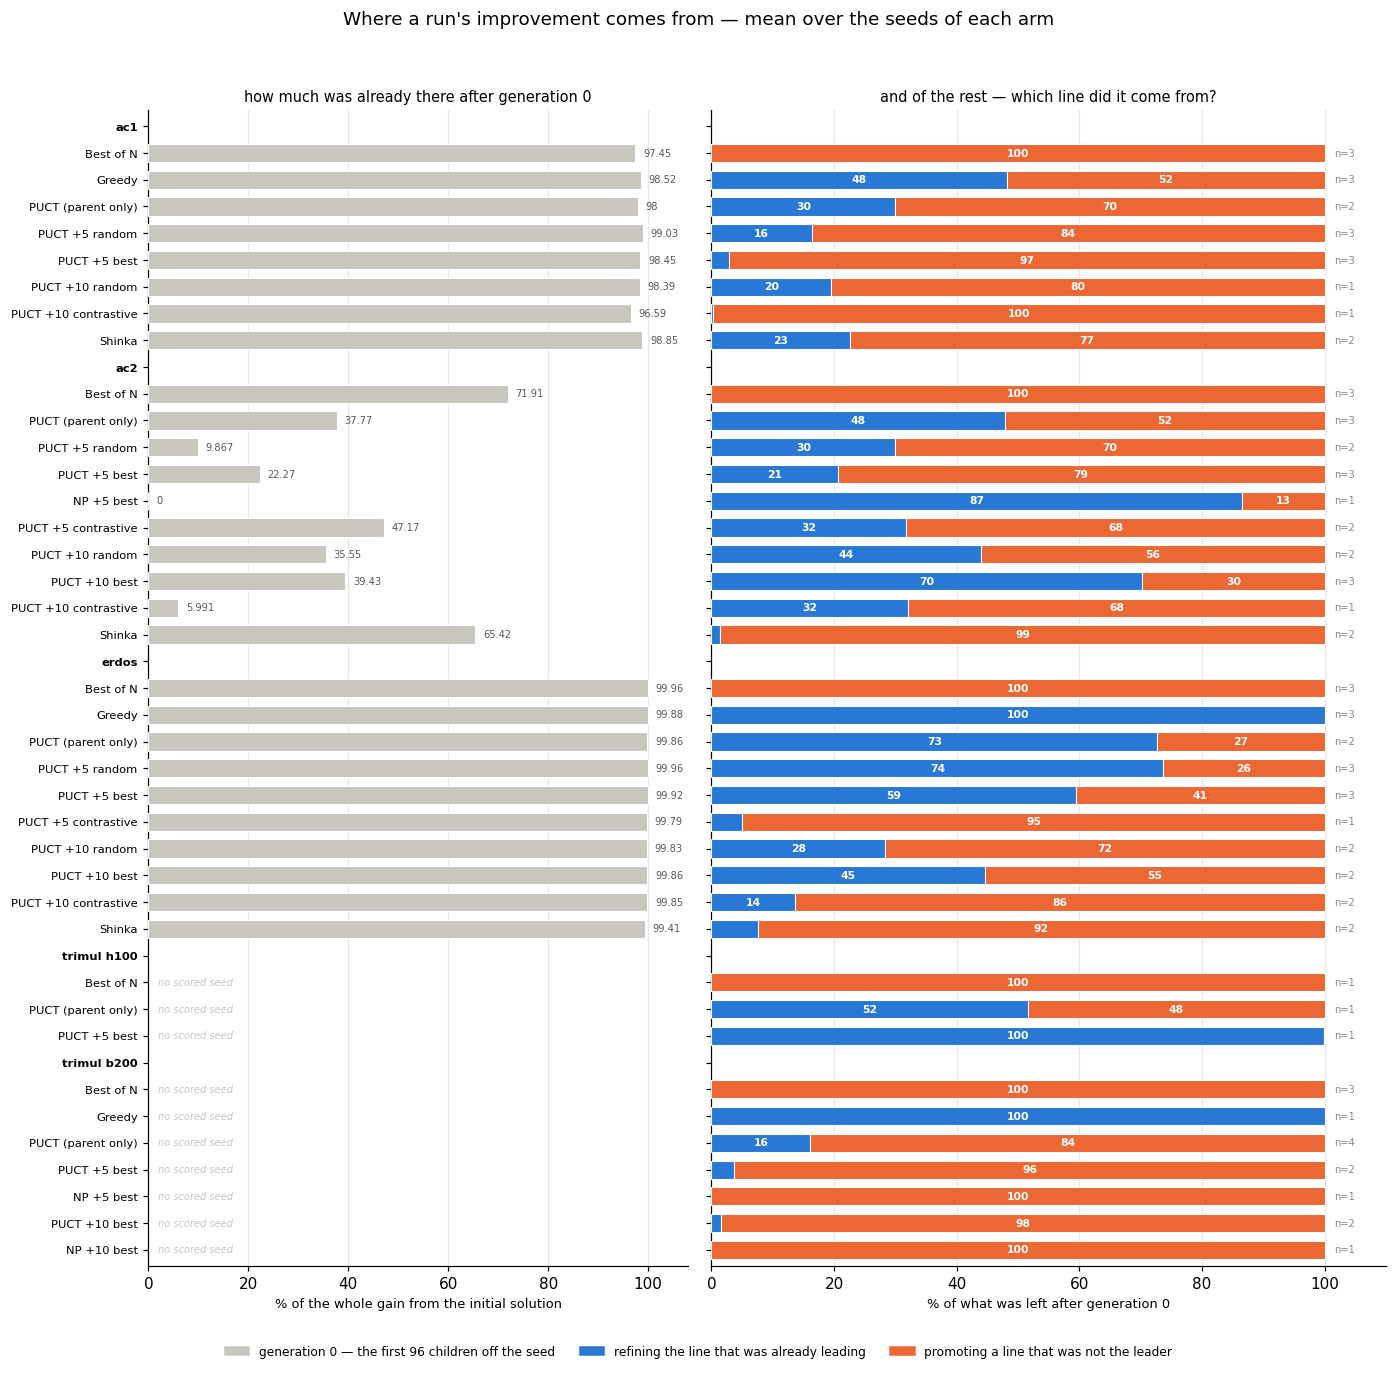

=== lateral share of the post-gen-0 gain, by arm (all problems pooled) ===
Best of N and the no-parent arms are 100% lateral BY CONSTRUCTION -- the seed is their only
parent -- so their rows describe the design, not the search.
                   steps  lateral_pct  unexpected_pct  med_parent_rank  disruptive_pct
arm                                                                                   
BoN                   39        100.0            69.2            146.0            64.1
Greedy                86         10.5             0.0              1.0            18.6
PUCT                 186         44.1            25.3              1.0            18.3
n5 random            120         43.3            21.7              1.0            11.7
n5 best              188         61.2            37.2              2.0            14.9
NoParent n5 best      16         93.8             6.2             34.0            31.2
n5 contrastive        50         58.0            36.0              2.0      

In [25]:
# ------------------------------------------------- (a) where does a run's improvement come from?
# Two questions, two panels. Left: how much of the whole gain from the initial solution was already
# there after the first 96 children off the seed -- the part no search strategy can claim credit
# for. Right: of everything that came after, how much arrived by refining the line that was already
# leading (`continuing`) and how much by promoting a line that was not (`lateral`).
def _short_arm(a):
    if a in ("BoN", "Greedy", "PUCT", "Shinka"):
        return {"BoN": "Best of N", "PUCT": "PUCT (parent only)"}.get(a, a)
    parent, n, strat = _split_ctx(a)
    return ("NP" if parent == "No parent" else "PUCT") + f" +{n[1:]} {strat}"

def _lin_rows():
    """(kind, problem, arm): a bold header per problem, then its arms in ARM_ORDER, Shinka last."""
    out = []
    for p in LIN_PROBLEMS:
        sub = LRUN[LRUN.problem == p]
        arms = ([a for a in ARM_ORDER if (sub.arm == a).any()]
                + (["Shinka"] if (sub.arm == "Shinka").any() else []))
        out.append(("head", p, None))
        out += [("arm", p, a) for a in arms]
    return out

_rows = _lin_rows()
fig, axes = plt.subplots(1, 2, figsize=(12.8, 0.245 * len(_rows) + 2.0),
                         gridspec_kw={"width_ratios": [1, 1.25]}, sharey=True)
for y, (kind, p, arm) in enumerate(_rows):
    if kind == "head":
        continue
    sub = LRUN[(LRUN.problem == p) & (LRUN.arm == arm)]
    g0, lat = np.nanmean(sub.g0_share), np.nanmean(sub.lat_mass)
    if not np.isnan(g0):
        axes[0].barh(-y, g0, 0.68, color=LIN_COLOR["gen0"], edgecolor="white", lw=0.7, zorder=3)
        axes[0].text(g0 + 1.5, -y, f"{g0:.4g}", va="center", fontsize=6.5, color="#5a5854")
    else:                       # kernels: the seed was never scored, so there is nothing to anchor to
        axes[0].text(2, -y, "no scored seed", va="center", fontsize=6.5,
                     color="#c9c6c0", style="italic")
    if np.isnan(lat):
        continue
    left = 0.0
    for k, v in (("continuing", 100 - lat), ("lateral", lat)):
        axes[1].barh(-y, v, 0.68, left=left, color=LIN_COLOR[k], edgecolor="white", lw=0.7, zorder=3)
        if v >= 8:
            axes[1].text(left + v / 2, -y, f"{v:.0f}", ha="center", va="center", fontsize=7,
                         color="white", fontweight="bold", zorder=4)
        left += v
    axes[1].text(101.5, -y, f"n={len(sub)}", va="center", fontsize=6.5, color="#898781")
axes[0].set_yticks([-i for i in range(len(_rows))],
                   [p.replace("_", " ") if k == "head" else _short_arm(a)
                    for k, p, a in _rows], fontsize=7.5)
for t, (k, _, _) in zip(axes[0].get_yticklabels(), _rows):
    t.set_fontweight("bold" if k == "head" else "normal")
for ax, xmax, xlab, title in (
        (axes[0], 108, "% of the whole gain from the initial solution",
         "how much was already there after generation 0"),
        (axes[1], 110, "% of what was left after generation 0",
         "and of the rest — which line did it come from?")):
    ax.set_xlim(0, xmax)
    ax.set_xlabel(xlab, fontsize=8.5)
    ax.set_title(title, fontsize=9.5)
    ax.grid(axis="y", visible=False)
axes[0].set_ylim(-len(_rows) + 0.4, 0.6)
import matplotlib.patches as mpatches
fig.legend(handles=[mpatches.Patch(color=LIN_COLOR["gen0"], label="generation 0 — the first 96 children off the seed"),
                    mpatches.Patch(color=LIN_COLOR["continuing"], label="refining the line that was already leading"),
                    mpatches.Patch(color=LIN_COLOR["lateral"], label="promoting a line that was not the leader")],
           loc="upper center", bbox_to_anchor=(0.5, 0.035), ncol=3, fontsize=8, frameon=False)
fig.suptitle("Where a run's improvement comes from — mean over the seeds of each arm", y=0.995)
fig.tight_layout(rect=(0, 0.04, 1, 0.975))
fig.savefig("icl_lineage_mass.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== lateral share of the post-gen-0 gain, by arm (all problems pooled) ===")
print("Best of N and the no-parent arms are 100% lateral BY CONSTRUCTION -- the seed is their only")
print("parent -- so their rows describe the design, not the search.")
print((LSTEP_POST[LSTEP_POST.paradigm == "ICL"].groupby("arm")
       .agg(steps=("gen", "size"), lateral_pct=("lateral", lambda s: 100 * s.mean()),
            unexpected_pct=("unexpected", lambda s: 100 * s.mean()),
            med_parent_rank=("parent_rank", "median"),
            disruptive_pct=("disruptive", lambda s: 100 * s.mean()))
       .reindex([a for a in ARM_ORDER if a in set(LSTEP_POST.arm)]).round(1).to_string()))

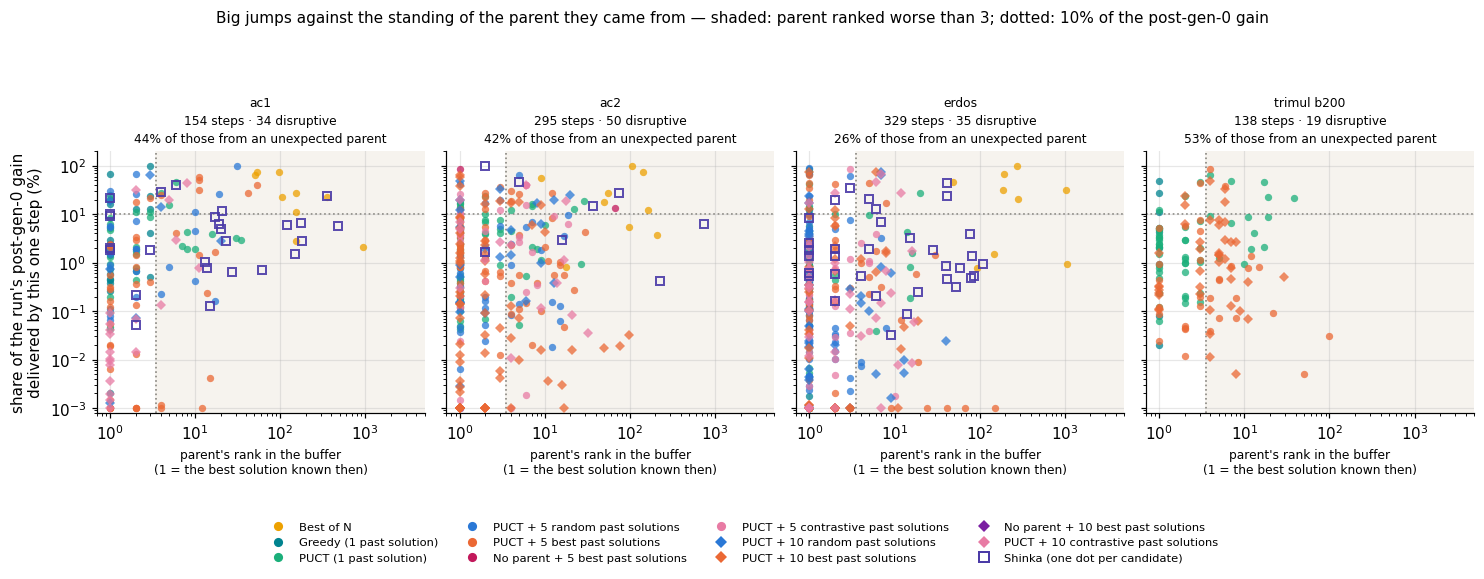

=== the answer, per problem: of the disruptive steps, how many had an unexpected parent? ===
  ac1          ICL      154 steps   34 disruptive     44% unexpected parent     79% lateral  | the other steps:    20% unexpected,    42% lateral
  ac1          Shinka    26 steps    6 disruptive     67% unexpected parent     67% lateral  | the other steps:    70% unexpected,    85% lateral
  ac2          ICL      295 steps   50 disruptive     42% unexpected parent     62% lateral  | the other steps:    32% unexpected,    51% lateral
  ac2          Shinka     8 steps    4 disruptive     75% unexpected parent    100% lateral  | the other steps:    75% unexpected,    75% lateral
  erdos        ICL      329 steps   35 disruptive     26% unexpected parent     43% lateral  | the other steps:    20% unexpected,    38% lateral
  erdos        Shinka    34 steps    6 disruptive     67% unexpected parent    100% lateral  | the other steps:    64% unexpected,    79% lateral
  trimul_h100  ICL        7 ste

In [26]:
# ------------------------------------------------- (b) are the big jumps the ones nobody expected?
# One dot per generation-step: how well the chosen parent was doing at the time (x -- its rank in
# the buffer, 1 = the best solution known) against how much that step moved the run (y -- share of
# the post-gen-0 gain). The shaded top-right corner is the case the question is about: a big jump
# out of a parent that was not one of the leaders. Best of N sits far right by construction (its
# parent is always the seed), which is worth seeing but is not evidence about search.
def _arm_mk(a): return "D" if "n10" in a else "o"
_panels = [p for p in LIN_PROBLEMS if p != "trimul_h100"]
fig, axes = plt.subplots(1, len(_panels), figsize=(3.4 * len(_panels), 4.3), sharey=True)
for ax, p in zip(np.atleast_1d(axes), _panels):
    sub = LSTEP_POST[(LSTEP_POST.problem == p) & LSTEP_POST.parent_rank.notna()
                     & LSTEP_POST.share_post.notna()]
    icl, shk = sub[sub.paradigm == "ICL"], sub[sub.paradigm == "Shinka"]
    ax.axvspan(UNEXPECTED + 0.5, 1e4, color="#f6f3ee", zorder=0)
    ax.axhline(DISRUPTIVE, color="#898781", ls=":", lw=1.1, zorder=1)
    ax.axvline(UNEXPECTED + 0.5, color="#898781", ls=":", lw=1.1, zorder=1)
    for arm in [a for a in ARM_ORDER if a in set(icl.arm)]:
        s = icl[icl.arm == arm]
        ax.plot(s.parent_rank, s.share_post.clip(lower=1e-3), _arm_mk(arm), ms=4.8, alpha=0.75,
                mfc=arm_color(arm), mec="none", ls="none", zorder=3)
    if len(shk):
        ax.plot(shk.parent_rank, shk.share_post.clip(lower=1e-3), "s", ms=5.5, alpha=0.9,
                mfc="none", mec="#4a3aa7", mew=1.3, ls="none", zorder=4)
    d = icl[icl.disruptive & ~icl.arm.isin(STAR_ARMS)]
    n = icl[~icl.arm.isin(STAR_ARMS)]
    # three short title lines: at this panel width the counts on one line run into the neighbour
    ax.set_title(f"{p.replace('_', ' ')}\n{len(n)} steps · {len(d)} disruptive\n"
                 f"{100 * d.unexpected.mean() if len(d) else float('nan'):.0f}% of those from an "
                 f"unexpected parent", fontsize=8, linespacing=1.5)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(0.8e-3, 200)
    ax.set_xlim(0.7, 5e3)
    ax.set_xlabel("parent's rank in the buffer\n(1 = the best solution known then)", fontsize=8)
np.atleast_1d(axes)[0].set_ylabel("share of the run's post-gen-0 gain\ndelivered by this one step (%)")
fig.legend(handles=[plt.Line2D([], [], ls="none", marker=_arm_mk(a), mfc=arm_color(a), mec="none",
                               ms=6, label=arm_label(a, budget=None))
                    for a in ARM_ORDER if a in set(LSTEP_POST.arm)]
                   + [plt.Line2D([], [], ls="none", marker="s", mfc="none", mec="#4a3aa7", mew=1.3,
                                 ms=6, label="Shinka (one dot per candidate)")],
           loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=4, fontsize=7.5, frameon=False)
fig.suptitle(f"Big jumps against the standing of the parent they came from — shaded: parent ranked "
             f"worse than {UNEXPECTED}; dotted: {DISRUPTIVE:.0f}% of the post-gen-0 gain",
             y=1.08, fontsize=10)
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig("icl_lineage_jumps.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== the answer, per problem: of the disruptive steps, how many had an unexpected parent? ===")
for p in LIN_PROBLEMS:
    for pdg in ("ICL", "Shinka"):
        s = LSTEP_POST[(LSTEP_POST.problem == p) & (LSTEP_POST.paradigm == pdg)
                       & ~LSTEP_POST.arm.isin(STAR_ARMS)]
        d = s[s.disruptive]
        if not len(s):
            continue
        print(f"  {p:12s} {pdg:7s} {len(s):4d} steps  {len(d):3d} disruptive  "
              f"{100 * d.unexpected.mean() if len(d) else float('nan'):5.0f}% unexpected parent  "
              f"{100 * d.lateral.mean() if len(d) else float('nan'):5.0f}% lateral  "
              f"| the other steps: {100 * s[~s.disruptive].unexpected.mean():5.0f}% unexpected, "
              f"{100 * s[~s.disruptive].lateral.mean():5.0f}% lateral")

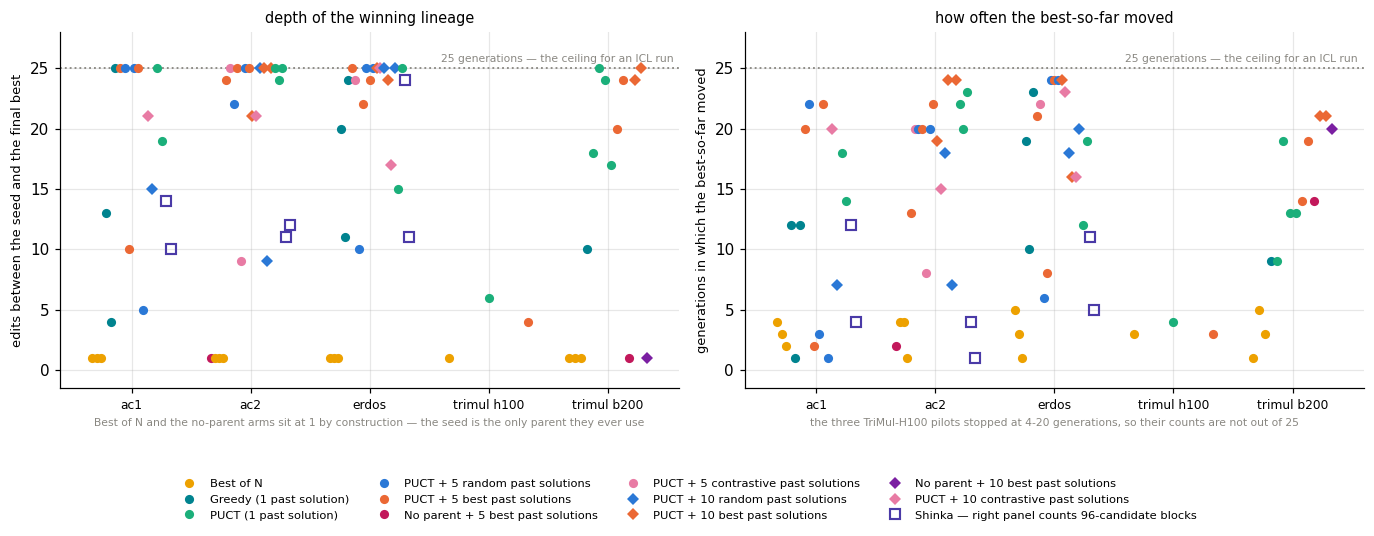

=== the winning lineage, per run ===
chain_led = % of the winner's ancestors (itself excluded) that were the best-so-far at some point
    problem               arm                      run  gens  steps  depth  chain_led  g0_share   top1  lateral_pct  lat_mass  med_rank  unexp_pct  disr
        ac1               BoN                   bon_s1    25      4      1        NaN      95.2   72.8        100.0     100.0     129.5      100.0     2
        ac1               BoN                   bon_s2    25      3      1        NaN      98.4   65.8        100.0     100.0     154.0      100.0     3
        ac1               BoN                   bon_s3    25      2      1        NaN      98.8   73.1        100.0     100.0     124.0      100.0     2
        ac1            Greedy            greedy_s1_ac1    25     12     13       83.3      98.4   66.6         16.7       4.6       1.0        0.0     2
        ac1            Greedy            greedy_s2_ac1    25      1      4        0.0      99.1  100

In [27]:
# ------------------------------------------------- (c) how deep is the winning lineage?
# `depth` counts the edits between the seed and the final best: 1 means the winner is a direct child
# of the seed, 25 means a new refinement landed in every single generation. For an ICL run the
# ceiling IS the generation count, which is what makes the Shinka column interesting -- Shinka
# evaluates one program per generation and so had 2,400 chances to go deeper than 25.
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))
_x = {p: i for i, p in enumerate(LIN_PROBLEMS)}
for ax, col in zip(axes, ("depth", "steps")):
    for p in LIN_PROBLEMS:
        sub = LRUN[LRUN.problem == p]
        for j, (_, r) in enumerate(sub.iterrows()):
            dx = np.linspace(-0.33, 0.33, len(sub))[j]
            shk = r.paradigm == "Shinka"
            ax.plot(_x[p] + dx, r[col], "s" if shk else _arm_mk(str(r.arm)),
                    ms=7 if shk else 6, mfc="none" if shk else arm_color(r.arm),
                    mec="#4a3aa7" if shk else "none", mew=1.4, ls="none", zorder=3)
    ax.axhline(25, color="#898781", ls=":", lw=1.2)
    ax.text(len(LIN_PROBLEMS) - 0.45, 25.4, "25 generations — the ceiling for an ICL run",
            ha="right", va="bottom", fontsize=7, color="#898781")
    ax.set_xticks(list(_x.values()), [p.replace("_", " ") for p in LIN_PROBLEMS], fontsize=8)
    ax.set_xlim(-0.6, len(LIN_PROBLEMS) - 0.4)
    ax.set_ylim(-1.5, 28)
axes[0].set_ylabel("edits between the seed and the final best", fontsize=8.5)
axes[0].set_title("depth of the winning lineage", fontsize=9.5)
# the caveats go under the axes: every corner inside the panels already has dots in it
axes[0].set_xlabel("Best of N and the no-parent arms sit at 1 by construction — "
                   "the seed is the only parent they ever use", fontsize=7, color="#898781")
axes[1].set_ylabel("generations in which the best-so-far moved", fontsize=8.5)
axes[1].set_title("how often the best-so-far moved", fontsize=9.5)
axes[1].set_xlabel("the three TriMul-H100 pilots stopped at 4-20 generations, so their counts are "
                   "not out of 25", fontsize=7, color="#898781")
fig.legend(handles=[plt.Line2D([], [], ls="none", marker=_arm_mk(a), mfc=arm_color(a), mec="none",
                               ms=6, label=arm_label(a, budget=None))
                    for a in ARM_ORDER if a in set(LRUN.arm)]
                   + [plt.Line2D([], [], ls="none", marker="s", mfc="none", mec="#4a3aa7", mew=1.4,
                                 ms=6, label="Shinka — right panel counts 96-candidate blocks")],
           loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=4, fontsize=7.5, frameon=False)
fig.tight_layout(rect=(0, 0.07, 1, 1))
fig.savefig("icl_lineage_depth.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== the winning lineage, per run ===")
print("chain_led = % of the winner's ancestors (itself excluded) that were the best-so-far at some point")
_c = ["problem", "arm", "run", "gens", "steps", "depth", "chain_led", "g0_share", "top1",
      "lateral_pct", "lat_mass", "med_rank", "unexp_pct", "disr"]
print(LRUN.sort_values(["problem", "arm", "run"])[_c]
      .to_string(index=False, float_format=lambda v: f"{v:6.1f}"))

In [28]:
# ------------------------------------------------- (d) one run, spelled out
# The two figures above are summaries of exactly this: the chain of ancestors that ends at a run's
# final best. Reading one run line by line is the quickest way to see what "depth" and "jump" mean.
#   depth       = the number of rows in this table (seed -> child -> grandchild -> ... -> winner)
#   this step   = how much the best-so-far moved when this ancestor was born, as a share of
#                 everything the run gained after generation 0 (blank = it was not a new best)
#   parent rank = how good this row's parent looked among all valid solutions found so far
def lineage_walk(problem, run, maximize=None, baseline=None):
    """Print the ancestor chain of one run's final best, one row per generation."""
    ev = (events[(problem, run)] if (problem, run) in events
          else load_events_path(LRUN_PATH[(problem, run)]))
    hi = PROBLEMS[problem]["maximize"] if maximize is None else maximize
    base = PROBLEMS[problem]["initial"] if (baseline is None and problem in PROBLEMS) else baseline
    L = lineage(ev, hi, base)
    score, par, gen_of = {}, {}, {}
    pool_before = {}                     # generation -> scores of every valid solution before it
    seen = [] if base is None else [base]
    for g, blk in ev.groupby("generation", sort=True):
        pool_before[g] = list(seen)
        for r in blk.itertuples():
            if isinstance(r.sol, str) and r.valid:
                score[r.sol], par[r.sol], gen_of[r.sol] = r.raw_score, r.parent_sol, g
                seen.append(r.raw_score)
    steps = {s.sol: s for s in L["steps"].itertuples()} if not L["steps"].empty else {}
    unit = PROBLEMS[problem]["metric"] if problem in PROBLEMS else "runtime (us)"
    print(f"\n=== {problem} / {run}: the ancestor chain of the final best "
          f"(depth {L['depth']}, {len(L['steps'][L['steps'].gen > 0])} improving generations) ===")
    print(f"{'#':>3} {'gen':>4} {'solution':>12} {'parent':>12} {'parent rank':>12} "
          f"{unit:>13} {'gap%':>8}  this step")
    for i, sol in enumerate(L["chain"], start=1):
        p = par[sol]
        pool = np.asarray(pool_before[gen_of[sol]], dtype=float)
        ps = score.get(p, base)
        rank = ("—" if (ps is None or not len(pool))
                else f"{int(((pool > ps) if hi else (pool < ps)).sum() + 1)} of {len(pool)}")
        st = steps.get(sol)
        note = ("" if st is None else
                (f"NEW BEST, {st.share_post:5.1f}% of the post-gen-0 gain"
                 + ("  [lateral — not from the incumbent]" if st.lateral else "  [refined the incumbent]")
                 if st.gen > 0 else "NEW BEST (generation 0, off the seed)"))
        g_txt = f"{gap_pct(problem, score[sol]):+8.3f}" if problem in PROBLEMS else "     n/a"
        print(f"{i:3d} {gen_of[sol]:4d} {sol:>12} {p:>12} {rank:>12} {score[sol]:13.6f} {g_txt}  {note}")

# one run per problem: the best final of the strongest arm, i.e. the lineage that actually won
LRUN_PATH = {}
for _, _r in idx.iterrows():
    LRUN_PATH[(_r.group, _r["run"])] = _r.path
for _p in PROBLEMS:
    _sub = idx[(idx.group == _p) & idx.complete]
    _pick = _sub.loc[_sub.best_score.idxmax() if PROBLEMS[_p]["maximize"] else _sub.best_score.idxmin()]
    lineage_walk(_p, _pick["run"])


=== ac1 / puct_s1: the ancestor chain of the final best (depth 25, 18 improving generations) ===
  #  gen     solution       parent  parent rank   upper bound     gap%  this step
  1    0   sol_000017         seed       1 of 1      1.522646   +3.978  
  2    1   sol_000097   sol_000017      4 of 71      1.512261   +1.889  NEW BEST,  27.7% of the post-gen-0 gain  [lateral — not from the incumbent]
  3    2   sol_000186   sol_000097     1 of 145      1.512240   +1.885  NEW BEST,   0.2% of the post-gen-0 gain  [refined the incumbent]
  4    3   sol_000273   sol_000186     1 of 222      1.512236   +1.884  
  5    4   sol_000297   sol_000273     2 of 292      1.512235   +1.884  
  6    5   sol_000438   sol_000297     3 of 377      1.512235   +1.884  
  7    6   sol_000510   sol_000438     3 of 459      1.512235   +1.884  
  8    7   sol_000608   sol_000510     5 of 537      1.512235   +1.884  
  9    8   sol_000679   sol_000608    24 of 615      1.511950   +1.826  
 10    9   sol_000755   


=== erdos / n10_s2_best: the ancestor chain of the final best (depth 24, 16 improving generations) ===
  #  gen     solution       parent  parent rank      C5 bound     gap%  this step
  1    0   sol_000009         seed       1 of 1      0.381023   +0.130  NEW BEST (generation 0, off the seed)
  2    1   sol_000112   sol_000009      1 of 52      0.380903   +0.024  NEW BEST,  74.0% of the post-gen-0 gain  [refined the incumbent]
  3    2   sol_000149   sol_000112     1 of 133      0.380893   +0.015  
  4    3   sol_000237   sol_000149     2 of 209      0.380874   -0.002  
  5    4   sol_000293   sol_000237     2 of 288      0.380870   -0.006  NEW BEST,   2.2% of the post-gen-0 gain  [lateral — not from the incumbent]
  6    5   sol_000382   sol_000293     1 of 363      0.380870   -0.005  
  7    6   sol_000406   sol_000382     7 of 396      0.380868   -0.007  
  8    7   sol_000452   sol_000406     8 of 425      0.380865   -0.010  NEW BEST,   1.6% of the post-gen-0 gain  [lateral — not

## 6. Takeaways (auto-refreshed numbers below; prose reflects the 2026-08-21 snapshot)

Quoted as **`gap%`** — distance to TTT-Discover as a share of the improvement it made from the same
initial solution (0 = matched, negative = beat it). See §1b.

**Did performance evolve during the run?** Yes for every arm that reuses history, on every problem.
BoN — the no-history, no-evolution control — is the worst arm on ac2 and erdos and flattens after the
first few hundred candidates; its ac2 gap is **+47.3%**, i.e. it captures barely half of
TTT-Discover's improvement, against +11.9% for plain PUCT. §5 adds a mechanism: BoN has the
**lowest validity of any arm** on ac1 (72.6%), ac2 (66.5%) and both TriMul cards (17-20%), so it is
not only searching worse, it is searching with fewer usable candidates. (On erdos it is third-lowest
at 57.0%, behind Greedy's 52.4% and the CPU-starved `n10 best` at 52.6%.)

**Does the selection rule matter — BoN vs Greedy vs PUCT?** Most of the benefit is in *reusing* the
buffer at all, not in exploring it:

- **ac1** — BoN +1.51%, Greedy +1.13%, PUCT +0.35%. Greedy recovers only a small part of the gap from
  BoN to PUCT, so on ac1 the PUCT exploration term is doing real work.
- **erdos** — BoN +0.046%, Greedy −0.007%, PUCT −0.012%. Greedy and PUCT are indistinguishable and
  both edge past TTT-Discover; almost all of the benefit is just "don't restart from the seed".
- **No ac2 greedy seeds yet** — and ac2 is the only problem whose `gap%` spread separates arms
  cleanly. **The greedy-vs-PUCT question is not settled until ac2 greedy runs exist**; that is still
  the single highest-value gap in the matrix.
- Caveat: `greedy_s1_erdos` lost **18%** of its budget to eval timeouts and scored only 50.1% of its
  candidates, `greedy_s2_erdos` 44.5% (§5b) — the erdos greedy numbers rest on the thinnest effective
  budget in the campaign.

**Do the methods differ in final quality?**
- **ac2 — the clearest signal.** `PUCT + 5 best` is the standout at **+0.55%** mean gap: two of its
  three seeds *beat* TTT-Discover (0.9603, 0.9614 vs 0.9591) and **s3 (0.961369) edges past
  AlphaEvolve's 0.9610** as well. Everything else lands +9% to +25%, and BoN at +47.3%.
- **erdos — same ordering, saturated.** PUCT −0.012%, `n10 best` −0.008%, Greedy −0.007%,
  `n5 best` −0.000%, BoN +0.046%, `n5 contrastive` +0.103% (worst). The whole arm spread is ~0.1% of
  the available improvement, so treat erdos as unable to discriminate rather than as agreement.
- **ac1 — the muddiest.** PUCT +0.35% and `n5 best` +0.66% lead, but within-arm seed spread rivals
  between-arm gaps (`n5 random` spans +0.60% to +2.51%). No strong claim.

**Is the "improve upon this" framing load-bearing? (the `No parent + 5 best` arm.)** On ac2, showing
the model 5 best past solutions with **no parent at all** lands at **+20.2%** gap — far better than
Best of N's +47.3% (so the context block alone carries a lot of the benefit) but clearly worse than
`PUCT + 5 best` at **+0.55%** and than plain `PUCT (1 past solution)` at +11.9%. One seed, so a first
data point rather than a result — and note from §5 that it is also the run with the campaign's
highest `eval_timeout` share (16.9%).

**Context strategies.** `best` is the only strategy that beats plain PUCT decisively (ac2 +0.55% vs
+11.9%). `random` and `contrastive` sit behind it, but the ordering between those two is no longer
stable: ac2's second `n5 contrastive` seed came in at 0.957846 — the second-best single ac2 result —
against the first seed's 0.945786, so the arm mean (+13.4%) hides a spread wider than the gap between
most arms. And that seed lost 37% of its budget to starvation (§5b). From the
proposal-quality panels: `best` context keeps the whole proposal distribution pinned near the
frontier, while `random` context is **unstable** — its median proposal quality oscillates and can
collapse onto a mediocre valid solution family for whole generations.

**5 vs 10 solutions in prompt.** On ac2, `n5 best` +0.55% vs `n10 best` +13.9% (now 3 seeds each), so
more context does not help there. On erdos `n10 best` is second-best (−0.008%) — **and it did that
having lost 21% and 41% of its two seeds' budgets to `cpu_starvation`** (§5b), which cuts both ways:
the comparison is contaminated, but the arm reached a top score on roughly half the candidates.
On B200 TriMul `n10 best` has the best arm mean but a 2.7x seed spread. Net: **unresolved**, and the
erdos side needs a rerun on a healthy host before it can be read at all.

**Against the baselines.** Shinka's `r1` seed has now **finished** its 2,400 generations on all three
problems, so this comparison is like-for-like at last (`r2` is at 84-93% and still running):
- **ac1** — Shinka +0.353% against PUCT's +0.348%. A tie in the 5th decimal (1.504623 vs 1.504600),
  and Shinka was ahead at every k before the finish.
- **ac2** — Shinka +14.2%, *inside* the ICL spread: level with `n10 best` (+13.9%) and
  `n5 contrastive` (+13.4%), ahead of `n10 random` (+19.9%) and `NoParent n5 best` (+20.2%), behind
  plain PUCT (+11.9%), and far behind `n5 best` (+0.55%). The shape matters more than the endpoint: Shinka leads
  the whole board at k=400 (0.9441) and then **sits on 0.948944 from k=466 to k=2,174**.
- **erdos** — Shinka +0.013%, behind PUCT/Greedy/`n10 best`/`n5 best` (all at or past TTT-Discover)
  and behind at *every* k; `r2` (+0.042%) only just clears Best of N (+0.046%), on a problem where the
  seed solution is nearly optimal to begin with.
- **Shinka converges faster and plateaus; the ICL arms start slower and keep going.** That is the one
  finding all three problems agree on (§4b), and it is the argument for the ICL loop at large budgets
  rather than at small ones.
- The coding agent (run3, from scratch, one 6 h session) finals at 0.380879 on erdos — **+0.003%**,
  level with TTT-Discover and with the best ICL arms — with the budget-unit caveat above.

**Where the winner comes from (§7).** The family tree says the runs are not one lineage being
polished. **36-60% of the improving generations promote a line that was not leading**, and those
lateral steps carry 43-81% of everything won after generation 0. Disruptive steps — one generation
delivering >= 10% of the post-gen-0 gain — are **1.3-2.2x more likely than ordinary steps to have
grown from a parent outside the top 3** (44% of them on ac1, 42% on ac2, 53% on B200, 26% on erdos).
Two limits on that: "outside the top 3" usually means 4th-20th, not a nobody; and rank is measured
against every solution found, NOT against what the selector could choose from — only the top 2
children of each parent enter the buffer (~300 selectable states out of ~1,800 solutions), so this
says where the jumps came from, not what was passed over. The lateral rate rises with in-prompt
history — Greedy 11%, parent-only 44%, `random` 43-44%, `contrastive` 53-57%, `best` 60-61% — which
is a mechanism for why the `best` arms win: the elite is in the prompt regardless, so the parent no
longer has to be the best solution known. Two structural facts worth keeping: on ac1 and erdos
**98-100% of the raw gain is already in generation 0**, so all of this is about the last 1-2% — which
is nonetheless where the ranking lives (gen 0 leaves ac1 at +2.91% gap and the rest of the run more
than halves it, and **no run's final best came from generation 0**); and the winning lineage sits at
**18-25 edits deep of a possible 25**, i.e. on the ceiling the generation count imposes. Shinka is the same behaviour taken to its limit and it shows the cost — 78-100%
lateral, median parent at rank 5-41, and a winner only 10-24 edits deep after 2,400 sequential
generations. It never accumulates depth, which is the mechanism behind the plateau in §4b.

**Where TriMul stands.** The H100 pilot is nowhere near TTT-Discover (best 6,919 us against their
1,161 us on <=640 candidates against 25,600); its purpose was only to show the problem has headroom.
`gap%` is not used on kernels — runtime is a ratio scale and the seed kernel was never scored — so
§4c/§4d report the plain multiplier instead.

**TriMul on B200 (§4d) — the strongest result in the notebook, and a withdrawn one.** All 14 runs
are complete at 2,400 candidates. Against TTT-Discover's own kernel timed **on the same card**
(1,120 us):

| arm | seeds | mean | x ref | best seed | valid |
|---|---:|---:|---:|---:|---:|
| **No parent + 5 best** | 1 | **1,018 us** | **0.91x** | 1,018 | 58.2% |
| **No parent + 10 best** | 1 | **1,093 us** | **0.98x** | 1,093 | 62.8% |
| PUCT + 10 best | 2 | 2,132 us | 1.90x | 1,139 (1.02x) | 59.4% |
| PUCT (1 past solution) | 4 | 2,612 us | 2.33x | 1,551 (1.38x) | 30.9% |
| Greedy (1 past solution) | 1 | 3,173 us | 2.83x | 3,173 | 16.8% |
| PUCT + 5 best | 2 | 3,420 us | 3.05x | 3,353 | 53.6% |
| Best of N | 3 | 5,540 us | 4.95x | 4,282 | 19.8% |

- **Two arms beat the reference.** `No parent + 5 best` at **0.91x** and `No parent + 10 best` at
  **0.98x** are at or under TTT-Discover's kernel on 2,400 candidates against their 25,600. Single
  seeds each — but two different configurations under the line is more than one lucky run.
- **This inverts ac2.** There, removing the parent cost a lot (+20.2% gap vs `PUCT + 5 best`'s +0.55%);
  here it is the best move (1,018 us vs 3,420). Hypothesis: on a kernel task "improve upon this
  solution" anchors the model to one implementation strategy. Two runs, so a hypothesis only.
- **Survives replication:** history beats no history with zero overlap (BoN's best seed is worse than
  every other arm's worst), and validity is monotone in context — 16.8% (Greedy) / 19.8% (BoN) ->
  30.9% -> 53.6-58.2% -> 59.4-62.8%. Greedy having the *lowest* validity of all is notable: hammering
  the current best kernel produces less runnable code than sampling the buffer.
- **Does not survive:** last snapshot's headline "`PUCT + 10 best` matches TTT-Discover at 1.02x". Its
  second seed landed at 3,126 us and the arm mean is 1.90x. Nor does "n10 beats n5 by 3x": PUCT's best
  seed beats both `n5 best` seeds, and within-arm spread (2.2-2.7x) exceeds the between-arm gaps.

**Failures are a first-class cost (§5).** The failure rate *is* the effective budget, and it varies
enormously by problem — **19% (ac1), 26% (ac2), 34% (erdos), 61% (B200 TriMul), 70% (H100 TriMul)** —
so a "2,400-candidate" kernel run is really a ~900-candidate search. Three things worth carrying:

- **In-prompt history teaches the model what runs.** `process_crash` falls as context grows, on every
  problem: B200 TriMul 79% (BoN) -> 66% (PUCT) -> 45% (`n5 best`) -> 37% (`n10 best`); H100 TriMul
  82% -> 59% -> 41%; erdos 20% -> 20% -> 15% -> 10%; ac1 20% -> 15% -> 13% -> 9%. Monotone on all of
  those; ac2 has one inversion (31% -> 19% -> **25%** for `n5 best` -> 13% for `n10 best`). This is the
  most robust arm effect in the notebook and it is a *mechanism*, not a score: showing past solutions
  changes what the model emits, not just which parent it improves.
- **The failure mix is problem-shaped.** TriMul is ~97% `process_crash` (Triton compile), erdos
  spreads across `process_crash` 46%, `invalid_result` 25% (geometrically invalid packings — a failure
  mode the other problems barely have) and `eval_timeout` 16%. ac1/ac2 are crash-dominated with a
  3-4% timeout tail.
- **Format failures are negligible.** `no_code` is 0.2-0.7% everywhere, and only a handful of those
  (2-11 per problem) are truncation (`finish_reason == "length"`) rather than a formatting slip. The
  model's output format is not a loss channel; its code quality is.

**But the failure tax does not seem to cost quality (§5c).** Plotting each run's result against the
share of its candidates that scored: **no correlation on any math problem** — ac1 rho = −0.08
(p = 0.77), ac2 **+0.04** (p = 0.88), erdos **+0.22** (p = 0.33, both the *wrong* sign). B200 TriMul shows
rho = −0.51 (p = 0.06), but that is the arm confound — context arms both crash less and produce faster
kernels — not an effect of budget. Within an arm, where the confound is controlled, **7 of 14 arms
point the expected way and the mean rho is −0.04**: a coin flip. The two sharpest single cases both cut against the
budget story: erdos `n10 best`, the two lowest-validity runs in that campaign (41% and 64%,
CPU-starved), finished second-best overall; and ac2's `n05_s2_contrastive`, which scored **50%** of
its candidates after losing 37% of the budget to starvation, produced **the second-best single ac2
result** (0.957846).

Read together with the failure rates: a failed candidate wastes compute, but at these budgets it does
not appear to cost the *result*. Halving a run's effective budget from 2,400 to ~1,000 candidates did
not move its final score out of its arm's normal spread — which also means fixing the starvation would
buy wall-clock and cost, not accuracy, and that the arm differences in §1 are not budget artefacts.


In [29]:
snap = dt.datetime.now().strftime("%Y-%m-%d %H:%M")
print(f"=== auto-refreshed rankings, snapshot {snap} ===")
print("gap = % of TTT-Discover's improvement still missing (negative = beat TTT-Discover)\n")
for p, spec in PROBLEMS.items():
    sub = idx[(idx.group == p) & idx.complete]
    agg = (sub.groupby("arm").agg(mean=("best_score", "mean"), min=("best_score", "min"),
                                  max=("best_score", "max"), count=("best_score", "count"),
                                  gap=("gap_pct", "mean"))
              .reindex([a for a in ARM_ORDER if a in set(sub.arm)])
              .sort_values("mean", ascending=not spec["maximize"]))
    print(f"{p} (complete runs only, {'max' if spec['maximize'] else 'min'}):")
    for arm, r in agg.iterrows():
        print(f"  {arm:16s} mean {r['mean']:.6f}  range [{r['min']:.6f}, {r['max']:.6f}]  "
              f"seeds {int(r['count'])}  gap {r['gap']:+7.3f}%")
    for run in SHINKA[p]:
        print(f"  {'Shinka ' + run['seed']:16s} best {run['final']:.6f}  "
              f"({run['n']}/{SHINKA_BUDGET} cands, {100*run['n']/SHINKA_BUDGET:.0f}% of budget)"
              f"  gap {gap_pct(p, run['final']):+7.3f}%")
    print()

=== auto-refreshed rankings, snapshot 2026-08-24 23:31 ===
gap = % of TTT-Discover's improvement still missing (negative = beat TTT-Discover)

ac1 (complete runs only, min):
  PUCT             mean 1.504600  range [1.504439, 1.504761]  seeds 2  gap  +0.348%
  n5 best          mean 1.506164  range [1.504900, 1.507354]  seeds 3  gap  +0.663%
  Greedy           mean 1.508488  range [1.507422, 1.509571]  seeds 3  gap  +1.130%
  BoN              mean 1.510373  range [1.508927, 1.511804]  seeds 3  gap  +1.509%
  n5 random        mean 1.511099  range [1.505828, 1.515330]  seeds 3  gap  +1.655%
  n10 random       mean 1.513791  range [1.513791, 1.513791]  seeds 1  gap  +2.197%
  Shinka r1        best 1.504623  (2379/2400 cands, 99% of budget)  gap  +0.353%
  Shinka r2        best 1.507604  (2097/2400 cands, 87% of budget)  gap  +0.952%

ac2 (complete runs only, max):
  n5 best          mean 0.958800  range [0.954746, 0.961369]  seeds 3  gap  +0.553%
  n10 contrastive  mean 0.953981  range [0.9